# Label Data
This notebook is made to label the data. To create correct labels for each of the testing experimental data examples in order to ensure the corectness of the runs.

In [1]:
import math
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os
sys.path.append(os.path.abspath('..'))

from script.helper_methods import data_preprocessing as dp
from script.helper_methods.data_visualization import data_labeling as dv
from script.helper_methods.data_loader import read_unify_data, parse_time_column, add_logId_column, keep_relevant_columns


In [2]:
COLUMN_RENAME_MAP = {
    "Time": "Time",
    "Flow rate (Mean)": "Flow rate (Mean)",
    "Pressure before pump (Mean)": "TS inlet pressure (Mean)",
    "Pressure after pump (Mean)": "TS outlet pressure (Mean)",
    "Pressure after pump (Mean)": "Pump outlet pressure (Mean)", # Ambiguous column name, renamed to "Pump outlet pressure (Mean)" for testing purpose
    "Temperature TS inlet (Mean)": "Temperature TS inlet (Mean)",
    "Temperature TS outlet (Mean)": "Temperature TS outlet (Mean)",
    "Tank temperature (Mean)": "Tank temperature (Mean)",
    "Bypass temperature (Mean)": "Bypass temperature (Mean)",
    "Differential pressure (Mean)": "Differential pressure (Mean)",
}


def standardize_column_names(df):
    """
    Standardize column names using a predefined mapping to ensure consistency across different files
    
    Parameters:
    - df: pd.DataFrame, the input dataframe with original column names

    NB! This function is only usable on the datasets that were not finally used as a part of the final dataset. 
    """

    # Replace "Arith. Mean" with "Mean" in all column names
    df.columns = df.columns.str.replace("Arith. Mean", "Mean", regex=False)
    # Rename columns based on the mapping
    df = df.rename(columns=COLUMN_RENAME_MAP)
    return df


def load_raw_data_for_labeling(path="../data/raw_data/data1/*.csv", reconstruct_time=False, start_time=None, freq_Hz=2):
    """
    Load and concatenate CSV files from a given path
    Reconstruct the Time column if specified, otherwise parse it from the file
    Parameters:
    - path: str, the glob pattern to match CSV files
    - reconstruct_time: bool, whether to reconstruct the Time column based on start_time and freq_Hz
    - start_time: str or pd.Timestamp, the starting time for reconstructing the Time column
    - freq_Hz: int, the frequency in Hz for reconstructing the Time column
    """

    # Load and concatenate CSV files
    files = sorted(glob.glob(path))
    df_list = [read_unify_data(f) for f in files]
    df = pd.concat(df_list)

    # Reconstruct or parse Time column
    if reconstruct_time:
        if start_time is None:
            start_time = "1900-01-01 00:00:00"
        else:
            start_time = pd.Timestamp(start_time)

        df["Time"] = pd.date_range(start=start_time, periods=len(df), freq = f"{int(10000 / freq_Hz)}ms")
    else:
        df["Time"] = parse_time_column(df["Time"])

    # Set Time as index and sort by Time
    df.set_index('Time', inplace=True)
    df.sort_index(inplace=True)

    # Standardize column names
    df = standardize_column_names(df)

    # Drop any columns that are unnamed
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    return df

In [3]:
def save_labeled_data(df, name):
    """ Save the labeled dataframe to a CSV file in the 'data/labeled' directory, creating the directory if it doesn't exist. """
    
    # Define paths
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
    LABELED_PATH = os.path.join(BASE_PATH, 'data', 'labeled')
    
    # Create directory if it doesn't exist
    if not os.path.exists(LABELED_PATH):
        os.makedirs(LABELED_PATH)
    
    # Save
    output_path = os.path.join(LABELED_PATH, f'labeled_{name}.csv')
    df.to_csv(output_path, index=True)
    print(f"Labeled data saved to {output_path}")

In [4]:
def create_target_column(df, flow_thresh=0.9, pressure_thresh=1.3, thresholds=['flow'], mask=300):
    """ Make the target column based on thresholds """ 
    
    if ("Flow rate (Mean)" not in df.columns and "flow" in thresholds) or ("Pump outlet pressure (Mean)" not in df.columns and "pressure" in thresholds):
        raise ValueError("❌ ERROR: Required columns for target creation are missing.")

    if "flow" in thresholds:
        flow = df["Flow rate (Mean)"]
        flow_thresh = flow.median() * flow_thresh

        print(f"⚙️ Flow threshold set to: {flow_thresh:.2f}")

        # Initial plug labeling
        df["Plug"] = np.where((flow < flow_thresh ), 1, 0)

        # Reset false positives
        for i in range(1, len(df) - mask):
            if df["Plug"].iloc[i] == 1 and (flow.iloc[i+mask] > flow_thresh or flow.iloc[i-mask] > flow_thresh):
                df.loc[df.index[i], "Plug"] = 0

    if "pressure" in thresholds:
        pressure = df["Pump outlet pressure (Mean)"]
        pressure_thresh = pressure.median() * 1.3

        print(f"⚙️ Pressure threshold set to: {pressure_thresh:.2f}")
        
        pressure_plug = pressure > pressure_thresh
        
        df["Plug"] = np.where((pressure_plug), 1, df["Plug"])

In [5]:
def set_default_plug(df):
    """ Set default plug labels based on flow and pressure thresholds. """
    create_target_column(df) # Makes plug = 1/0 column, based on flow/pressure threshold

In [6]:
def set_no_plug(df):
    """ Set all values in 'Plug' to 0, indicating no plug events. """
    df['Plug'] = 0

In [7]:
def show_info(df):
    """ Print basic info about the dataset, such as columns, duplicates, datatypes, etc. """
    
    print(f"Dataset columns: {df.columns.tolist()}")
    print(f"Duplicate rows: {df.duplicated().sum()}")
    
    df.index = pd.to_datetime(df.index)
    print("Duplicate index timestamps:", df.index.duplicated().sum())

    print(f"Datatypes:\n{df.dtypes}")
    
    return df.head()

In [8]:
def set_plug_at_time(df, time_start, time_end, custom_date=None):
    """ Set 'Plug' column to 1 between specified start and end times. Times should be in 'HH:MM:SS' format."""
    # find first plug
    start_time = f'1900-01-01 {time_start}.330000'
    end_time = f'1900-01-01 {time_end}.330000'

    if custom_date is not None:
        start_time = f'{custom_date} {time_start}.330000'
        end_time = f'{custom_date} {time_end}.330000'

    # set plug column
    if 'Plug' not in df.columns:
        df['Plug'] = 0  
    df['Plug'] = np.where((df.index >= start_time) & (df.index <= end_time), 1, df['Plug'])
    

In [9]:
def cut(df, seconds_elapsed_start, seconds_elapsed_stop):
    """ Remove rows between start and stop time, where times are given as seconds elapsed from the start of the dataframe index """
    start = df.index[0] + pd.Timedelta(seconds=seconds_elapsed_start)
    stop = df.index[0] + pd.Timedelta(seconds=seconds_elapsed_stop)
    
    return df[(df.index < start) | (df.index > stop)]

In [10]:
def contains_infinite_or_big_values(df, threshold=1e6):
    """ Check if DataFrame contains infinite or very large values """
    if np.isinf(df.select_dtypes(include=['number'])).values.any():
        return True
    if (df.select_dtypes(include=['number']).abs() > threshold).values.any():
        return True
    return False

In [11]:
def flow_rate_missing(df, missing=False):
    """Indicate whether flow rate is missing (1) or not (0), manually set based on visual inspection of the data"""
    df["flow_rate_missing"] = 1 if missing else 0
    return df

In [12]:
def print_sampling_rates(data_list, dataset_ids, gap_threshold=10):
    """
    gap_threshold: intervals larger than this many seconds are treated as 
    gaps between files and ignored when computing sampling rate
    """

    # Check sampling rates of datasets by looking at time differences between rows
    for dataset_id, df in zip(dataset_ids, data_list):
        # Calculate time differences between consecutive rows based on index or Elapsed_seconds column
        if pd.api.types.is_datetime64_any_dtype(df.index):
            diffs = pd.Series(df.index).diff().dropna().dt.total_seconds()
        elif "Elapsed_seconds" in df.columns:
            diffs = df["Elapsed_seconds"].diff().dropna()
        else:
            print(f"Dataset {dataset_id}: could not determine sampling rate")
            continue

        # Filter out gaps between files
        diffs_filtered = diffs[diffs <= gap_threshold]

        # If no valid intervals remain after filtering, skip this dataset
        if len(diffs_filtered) == 0:
            print(f"Dataset {dataset_id}: could not determine sampling rate after filtering")
            continue

        # Calculate average interval and sampling rate
        avg_interval = diffs_filtered.median()
        hz = round(1 / avg_interval, 2) if avg_interval > 0 else None
        print(f"Dataset {dataset_id}: {hz} Hz — {round(avg_interval, 4)}s")

### Load datasets
Loads all raw datasets and saves them as variables for further labeling

In [13]:
print("Loading datasets...")
dataset1 = load_raw_data_for_labeling()
dataset2 = load_raw_data_for_labeling(path="../data/raw_data/data2/*.csv")
dataset3 = load_raw_data_for_labeling(path="../data/raw_data/data3/*.csv")
dataset4 = load_raw_data_for_labeling(path="../data/raw_data/data4/*.csv")
dataset5 = load_raw_data_for_labeling(path="../data/raw_data/data5/*.csv")
dataset6 = load_raw_data_for_labeling(path="../data/raw_data/data6/*.csv")
dataset7 = load_raw_data_for_labeling(path="../data/raw_data/data7/*.csv")
dataset8 = load_raw_data_for_labeling(path="../data/raw_data/data8/*.csv")
dataset9 = load_raw_data_for_labeling(path="../data/raw_data/data9/*.csv")
dataset10 = load_raw_data_for_labeling(path="../data/raw_data/data10/*.csv")
dataset11 = load_raw_data_for_labeling(path="../data/raw_data/data11/*.csv")
dataset12 = load_raw_data_for_labeling(path="../data/raw_data/data12/*.csv")
# Second dataset
dataset13 = load_raw_data_for_labeling(path="../data/raw_data/data13/*.csv")
dataset14 = load_raw_data_for_labeling(path="../data/raw_data/data14/*.csv")
dataset15 = load_raw_data_for_labeling(path="../data/raw_data/data15/*.csv")
dataset16 = load_raw_data_for_labeling(path="../data/raw_data/data16/*.csv")
dataset17 = load_raw_data_for_labeling(path="../data/raw_data/data17/*.csv")
dataset18 = load_raw_data_for_labeling(path="../data/raw_data/data18/*.csv", reconstruct_time=True, start_time="11.03.2022 14:06:00", freq_Hz=20)
dataset19 = load_raw_data_for_labeling(path="../data/raw_data/data19/*.csv")
dataset20 = load_raw_data_for_labeling(path="../data/raw_data/data20/*.csv")
dataset21 = load_raw_data_for_labeling(path="../data/raw_data/data21/*.csv")
dataset22 = load_raw_data_for_labeling(path="../data/raw_data/data22/*.csv", reconstruct_time=True, start_time="15.03.2022 12:46:20", freq_Hz=20)
dataset23 = load_raw_data_for_labeling(path="../data/raw_data/data23/*.csv")
dataset24 = load_raw_data_for_labeling(path="../data/raw_data/data24/*.csv")
dataset25 = load_raw_data_for_labeling(path="../data/raw_data/data25/*.csv")

print("Datasets loaded.")

Loading datasets...
Datasets loaded.


In [14]:
data_list = [dataset1, dataset2, dataset3, dataset4, dataset5, dataset6, dataset7, dataset8, dataset9, dataset10, dataset11, dataset12, dataset13, dataset14, dataset15, dataset16, dataset17, dataset18, dataset19, dataset20, dataset21, dataset22, dataset23, dataset24, dataset25]
dataset_ids = [i for i in range(1, 26)]

### Sampling rate analysis
The sampling rate for each dataset is analyzed here to check what sampling frequency they were recorded at.

In [15]:
print_sampling_rates(data_list, dataset_ids)

Dataset 1: 20.0 Hz — 0.05s
Dataset 2: 100.0 Hz — 0.01s
Dataset 3: 0.67 Hz — 1.499s
Dataset 4: 1.0 Hz — 1.0s
Dataset 5: 1.0 Hz — 1.0s
Dataset 6: 1.0 Hz — 0.997s
Dataset 7: 1.0 Hz — 1.0s
Dataset 8: 1.0 Hz — 1.0s
Dataset 9: 1.0 Hz — 1.0s
Dataset 10: 1.0 Hz — 1.0s
Dataset 11: 1.0 Hz — 1.0s
Dataset 12: 1.0 Hz — 1.0s
Dataset 13: 1.98 Hz — 0.504s
Dataset 14: 1.0 Hz — 1.0s
Dataset 15: 1.0 Hz — 1.0s
Dataset 16: 1.0 Hz — 1.0s
Dataset 17: 0.67 Hz — 1.499s
Dataset 18: 2.0 Hz — 0.5s
Dataset 19: 0.57 Hz — 1.752s
Dataset 20: 1.0 Hz — 1.0s
Dataset 21: 1.0 Hz — 1.0s
Dataset 22: 2.0 Hz — 0.5s
Dataset 23: 1.0 Hz — 1.0s
Dataset 24: 1.0 Hz — 1.0s
Dataset 25: 1.0 Hz — 1.0s


# Analyze and label each dataset
The sections under analyze each dataset and label it according to the descriptions available.
The process looks similar for most datasets, consisting of:
- Inspecting the info about the dataset
- Visualizing the datasets on flow rate, with plug labels
- Set no_plug or plug based on description
- For the less straighforward cases 
    - additional analyzes were conducted to correctly assign labels
    - parts of the logs were removed, to remove the manual adjustments made and not include these for the model to learn on

# Dataset 1

In [16]:
show_info(dataset1)

Dataset columns: ['Flow rate (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Temperature TS outlet (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Flow rate (Mean)                float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Temperature TS outlet (Mean)    float64
Tank temperature (Mean)         float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
dtype: object


,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
Time,,,,,,,,
1900-01-01 09:13:23.564,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479
1900-01-01 09:13:23.614,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727
1900-01-01 09:13:23.664,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105
1900-01-01 09:13:23.714,2005.764905,0.662791,1.010171,1.127850,-6.255584,-6.370422,-6.324766,25.584228
1900-01-01 09:13:23.764,2005.576313,0.663421,1.014057,1.130607,-6.247708,-6.375672,-6.322141,25.589479


⚙️ Flow threshold set to: 327.32


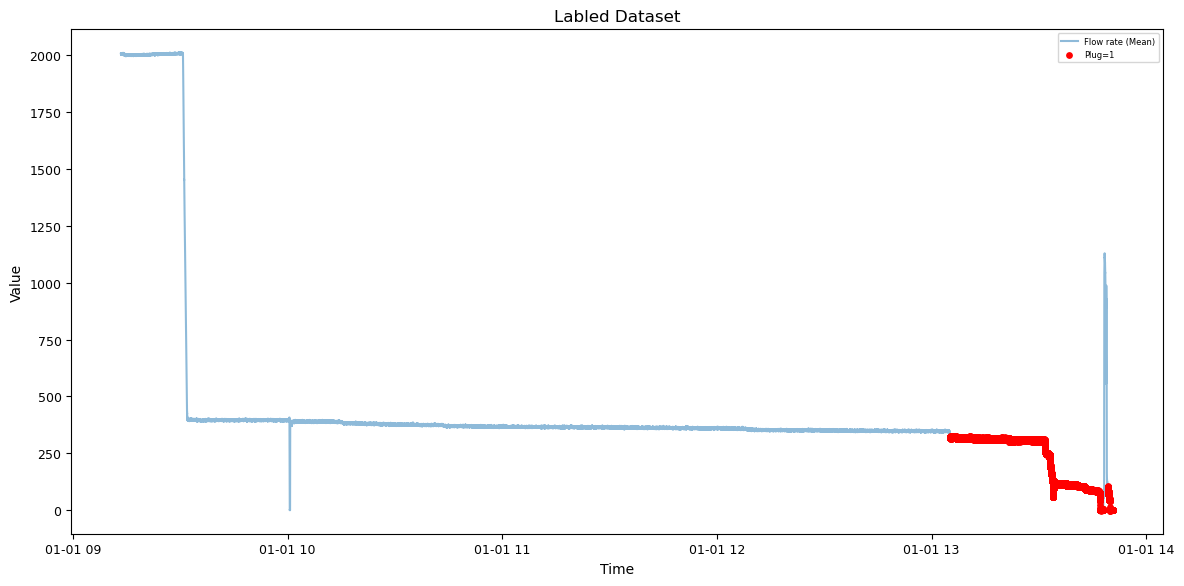

In [17]:
set_default_plug(dataset1)
dv.visualize_plug_event(dataset1, plug_column="Plug", name="Labled Dataset")

# Dataset 2

In [18]:
show_info(dataset2)

Dataset columns: ['Flow rate (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Temperature TS outlet (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)']
Duplicate rows: 21
Duplicate index timestamps: 0
Datatypes:
Flow rate (Mean)                float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Temperature TS outlet (Mean)    float64
Tank temperature (Mean)         float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
dtype: object


,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
Time,,,,,,,,
1900-01-01 13:21:20.972,1848.384604,0.587711,0.883321,0.920769,-3.861375,-4.160188,-3.962189,24.195356
1900-01-01 13:21:20.982,1849.799046,0.586661,0.885422,1.039285,-3.940132,-4.448936,-4.211572,24.234738
1900-01-01 13:21:20.992,1850.270527,0.584561,0.888572,0.986918,-3.861375,-4.120814,-3.830935,24.221611
1900-01-01 13:21:21.002,1850.742008,0.586661,0.882271,0.963031,-3.992637,-4.448936,-4.132819,24.195356
1900-01-01 13:21:21.012,1850.742008,0.583511,0.874396,1.031935,-3.848249,-4.199563,-3.975314,24.287248


In [19]:
print("shape of dataset2:", dataset2.shape)

shape of dataset2: (2046277, 8)


⚙️ Flow threshold set to: 346.84


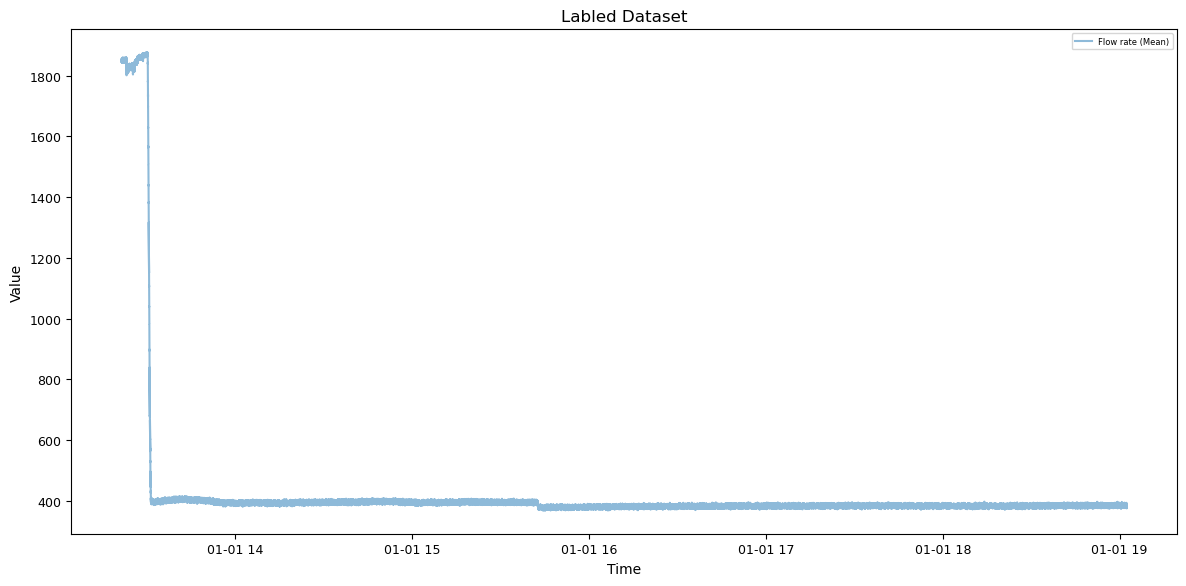

In [20]:
set_default_plug(dataset2)
dv.visualize_plug_event(dataset2, plug_column="Plug", name="Labled Dataset")

# Dataset 3

In [21]:
show_info(dataset3)

Dataset columns: ['TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
TS inlet pressure (Mean)           float64
Pump outlet pressure (Mean)        float64
Differential pressure (Mean)       float64
Flow rate (Mean)                   float64
Tank temperature (Mean)            float64
Temperature TS inlet (Mean)        float64
Temperature TS outlet (Mean)       float64
Bypass temperature (Mean)          float64
Temperature TS outlet (Std Dev)    float64
Temperature TS inlet (Std Dev)     float64
Bypass 

,TS inlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
2021-09-01 10:08:28.347,0.759556,0.000932,0.212329,1561.091208,7.280965,-2.381982,-0.025701,21.950240,0.241412,0.649763,0.230938,1.075645,0.017048,0.083666,0.005487,11.664282
2021-09-01 10:08:28.846,0.760145,0.000721,0.213470,1560.987274,7.231516,-2.370934,-0.125659,21.969181,0.269339,0.664583,0.236032,1.083438,0.016058,0.090984,0.005661,12.519271
2021-09-01 10:08:29.350,0.758179,0.000997,0.213269,1562.163933,7.182435,-2.299218,-0.214808,21.954802,0.257213,0.630675,0.242421,1.112259,0.016666,0.095589,0.005747,11.097039
2021-09-01 10:08:29.848,0.760242,0.000642,0.212117,1563.040239,7.017590,-2.263474,-0.313047,21.937244,0.279101,0.723726,0.245817,1.062527,0.016441,0.111216,0.005620,11.240369
2021-09-01 10:08:30.347,0.759019,0.000795,0.212366,1561.894331,7.095533,-2.231526,-0.370821,21.960763,0.266585,0.612376,0.251867,1.087259,0.016192,0.112690,0.005541,11.301572


In [22]:
set_no_plug(dataset3)

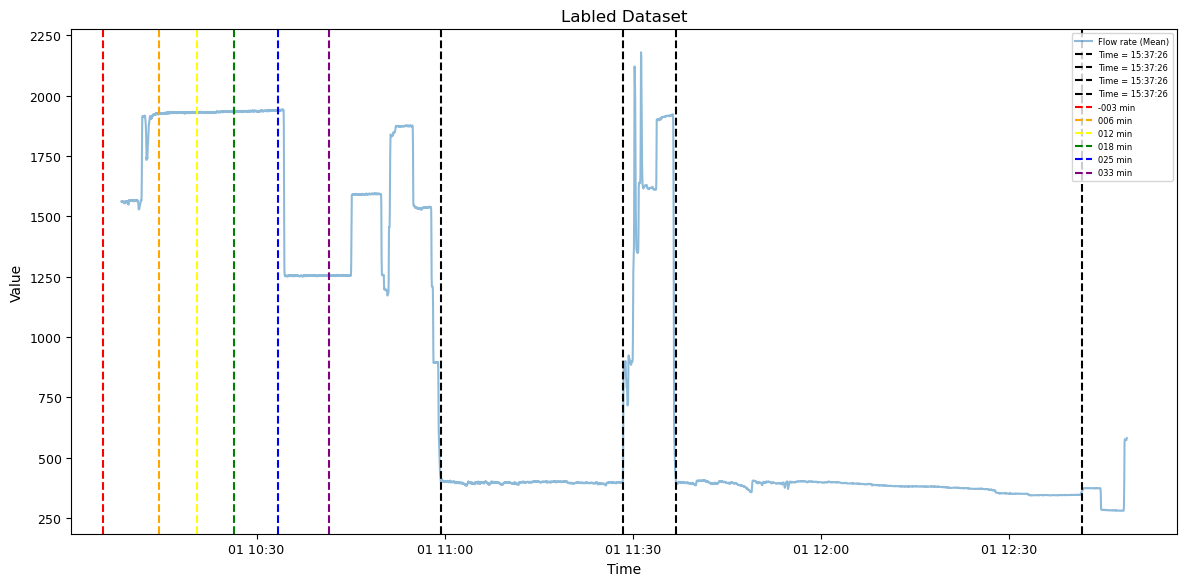

In [23]:
dv.visualize_plug_event(dataset3, plug_column="Plug", name="Labled Dataset", extra_id=3)

In [24]:
# cut the first Xs from dataset3, startup phase with no plug, based on case description and visual inspection of the data, flow rate stabilizes at 400 after Xs
first_400 = dataset3[
    (dataset3["Flow rate (Mean)"] >= 390) &
    (dataset3["Flow rate (Mean)"] <= 410)
].index[0]

print(first_400)
dataset3 = dataset3.loc[first_400:]

2021-09-01 10:59:21.171000


In [25]:
dataset3.index[0]

Timestamp('2021-09-01 10:59:21.171000')

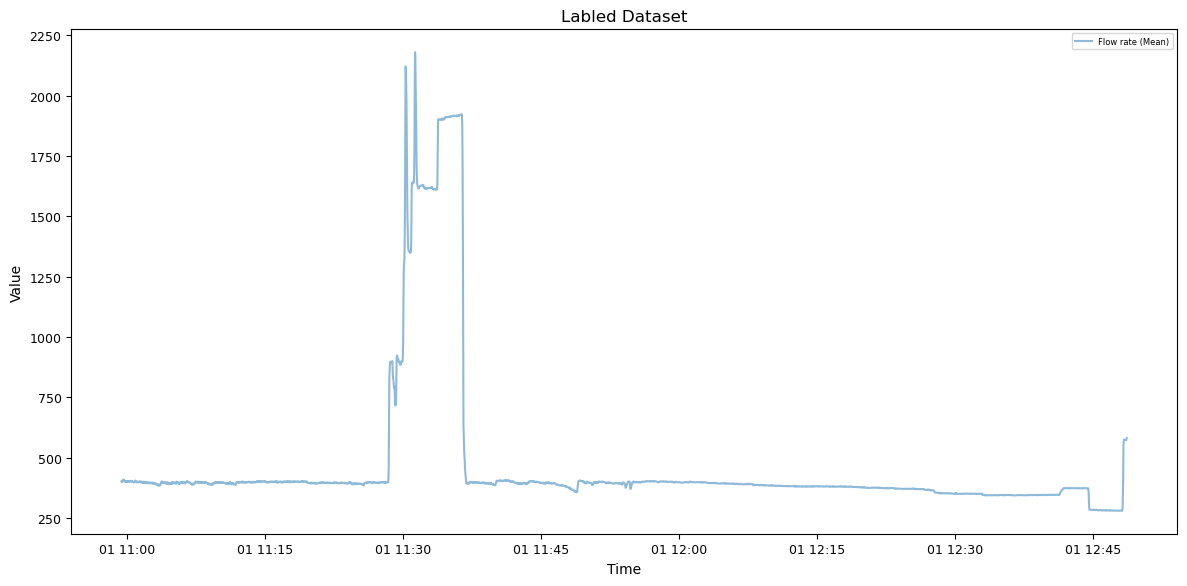

In [26]:
dv.visualize_plug_event(dataset3, plug_column="Plug", name="Labled Dataset")

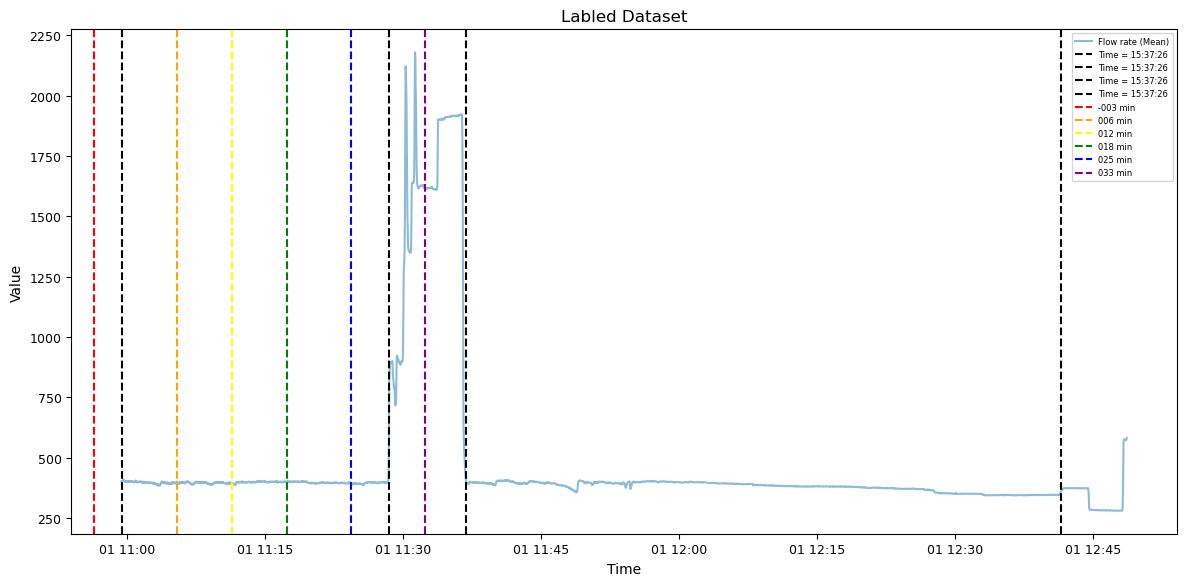

In [27]:
dv.visualize_plug_event(dataset3, plug_column="Plug", name="Labled Dataset", extra_id=3)

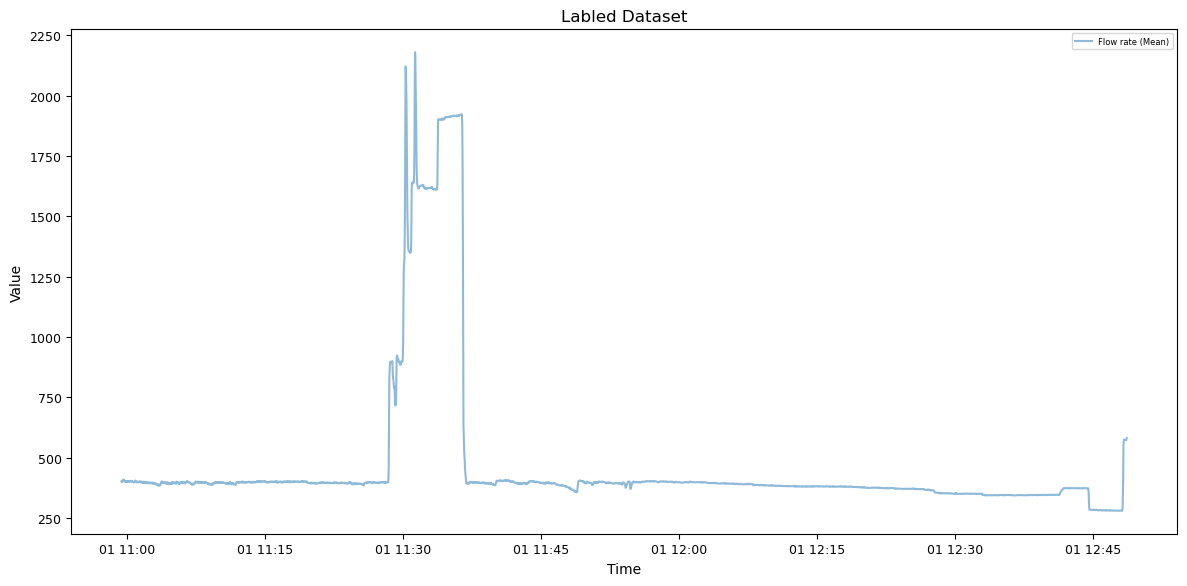

In [28]:
dv.visualize_plug_event(dataset3, plug_column="Plug", name="Labled Dataset")

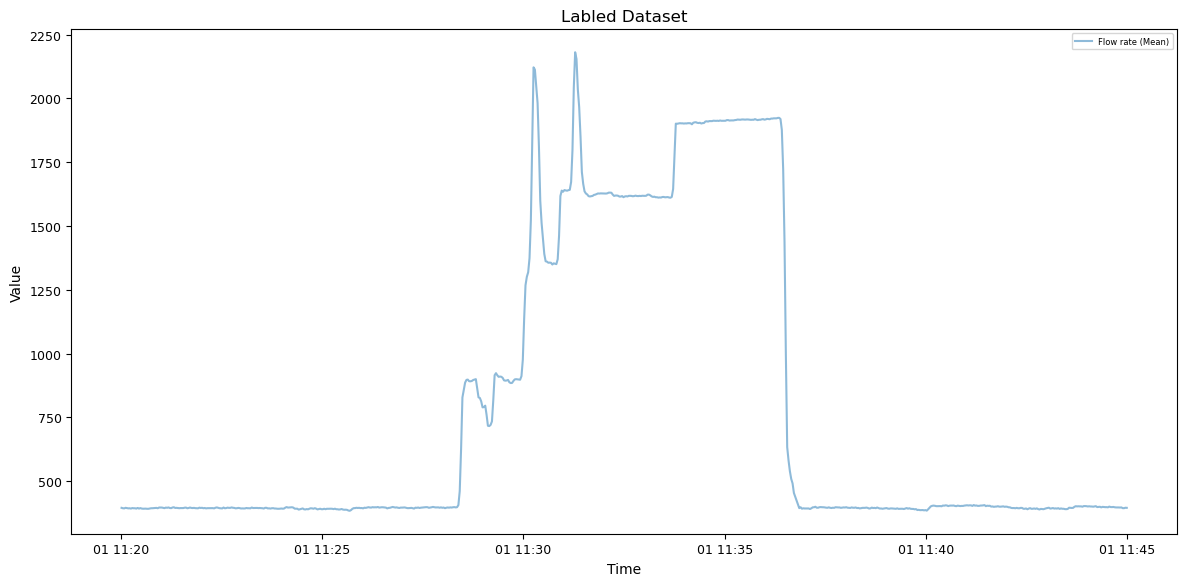

2021-09-01 11:28:25.069000


In [29]:
# Removing the spike, finding rise point
df3 = dataset3.copy().loc["2021-09-01 11:20:00": "2021-09-01 11:45:00"]
dv.visualize_plug_event(df3, plug_column="Plug", name="Labled Dataset")
spike_start = df3[
    (df3["Flow rate (Mean)"] >= 450) &
    (df3["Flow rate (Mean)"] <= 500)
].index[0]

print(spike_start)


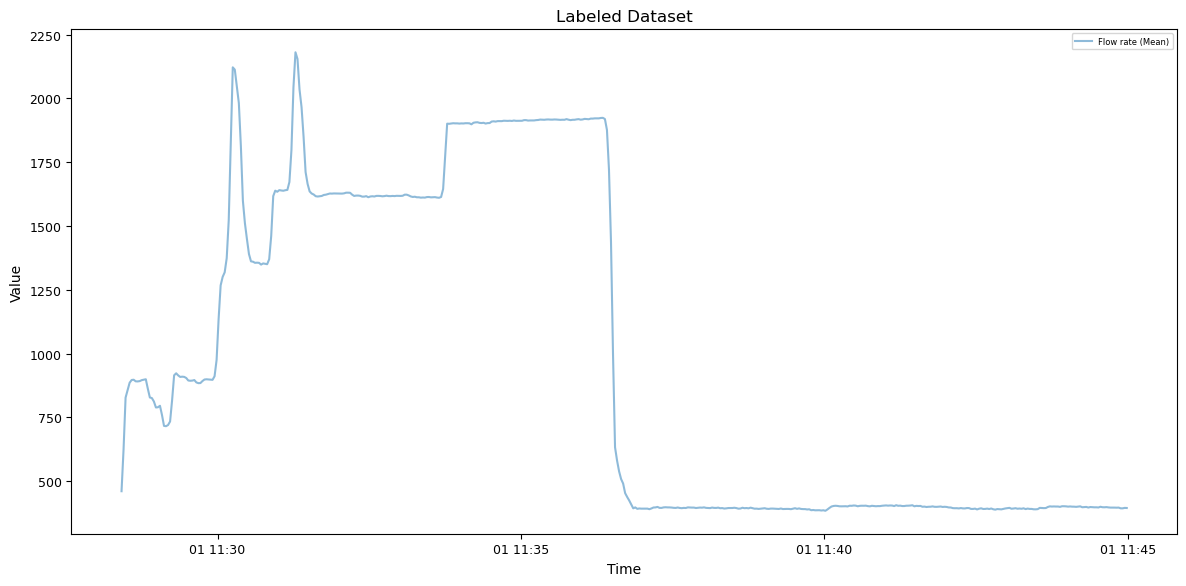

2021-09-01 11:36:49.038000


In [30]:
# Removing the spike, finding stabilization point
df3 = dataset3.copy().loc[spike_start: "2021-09-01 11:45:00"]
dv.visualize_plug_event(df3, plug_column="Plug", name="Labeled Dataset")
spike_end = df3[
    (df3["Flow rate (Mean)"] >= 390) &
    (df3["Flow rate (Mean)"] <= 410)
].index[0]

print(spike_end)

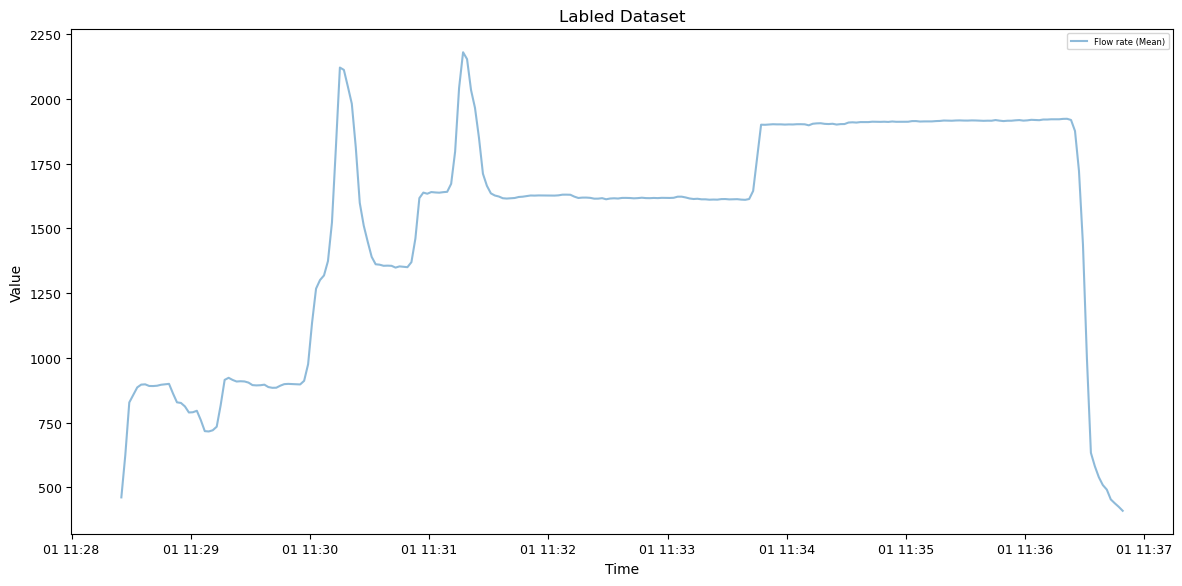

In [31]:
# Spike
df3 = dataset3.copy().loc[spike_start: spike_end]
dv.visualize_plug_event(df3, plug_column="Plug", name="Labled Dataset")

In [32]:
# Removing spike
df3 = dataset3.copy()

df3 = df3[
    ~(
        (df3.index >= pd.Timestamp(spike_start)) &
        (df3.index <= pd.Timestamp(spike_end))
    )
]

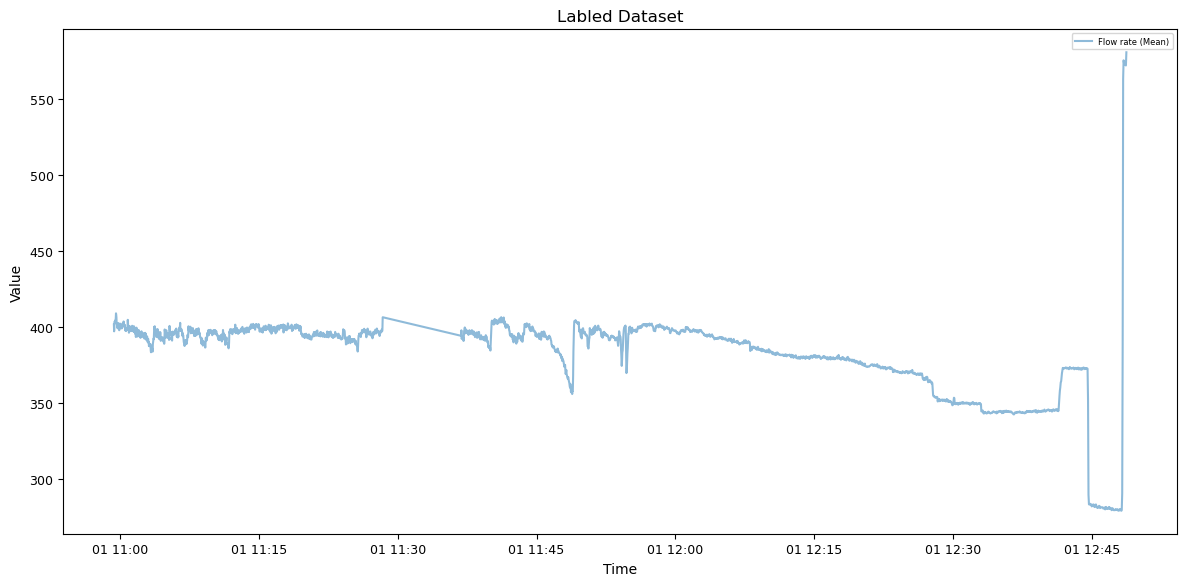

In [33]:
dv.visualize_plug_event(df3, plug_column="Plug", name="Labled Dataset")

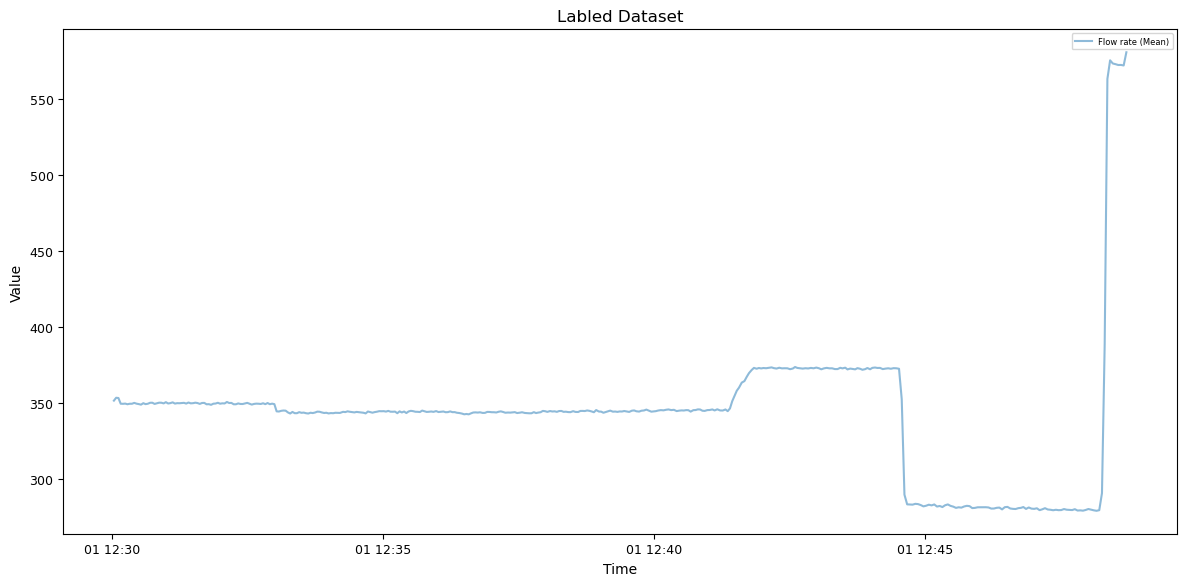

2021-09-01 12:41:31.312000


In [34]:
# End of experiment spike removal
# Removing the spike, finding rise point
df31 = dataset3.copy().loc["2021-09-01 12:30:00": ]
dv.visualize_plug_event(df31, plug_column="Plug", name="Labled Dataset")
end_spike = df31[
    (df31["Flow rate (Mean)"] >= 355) &
    (df31["Flow rate (Mean)"] <= 370)
].index[0]

print(end_spike)

In [35]:
df3 = df3.copy()
df3 = df3.loc[:end_spike]

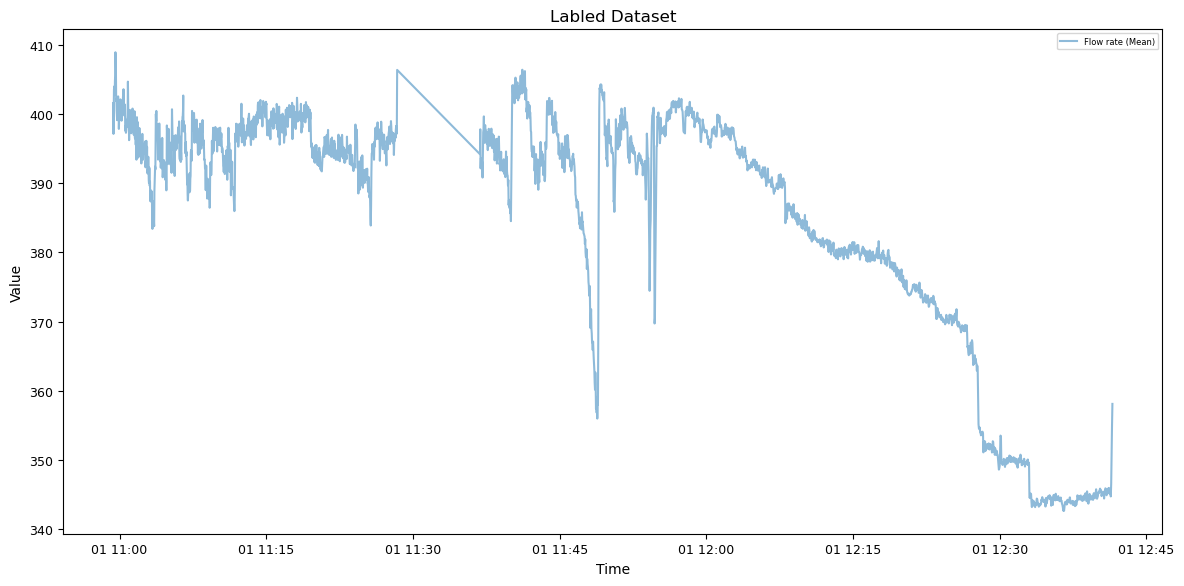

In [36]:
dataset3 = df3.copy()
dv.visualize_plug_event(dataset3, plug_column="Plug", name="Labled Dataset")

# Data 4
No blockage

In [37]:
show_info(dataset4)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 15:14:08.717,21.289102,-7.686529,21.978412,-7.887004,0.234429,0.241925,0.430600,1.023696
1900-01-01 15:14:09.717,21.273088,-7.692305,21.964366,-7.885036,0.233763,0.241222,0.430003,1.000122
1900-01-01 15:14:10.717,21.281620,-7.690073,21.969485,-7.881623,0.233689,0.240896,0.431041,0.957688
1900-01-01 15:14:11.717,21.273613,-7.691123,21.965547,-7.872829,0.234797,0.243133,0.432006,0.849248
1900-01-01 15:14:12.717,21.278076,-7.700311,21.966991,-7.865742,0.234015,0.241999,0.430940,0.594648


In [38]:
dataset4 = flow_rate_missing(dataset4, missing=True)

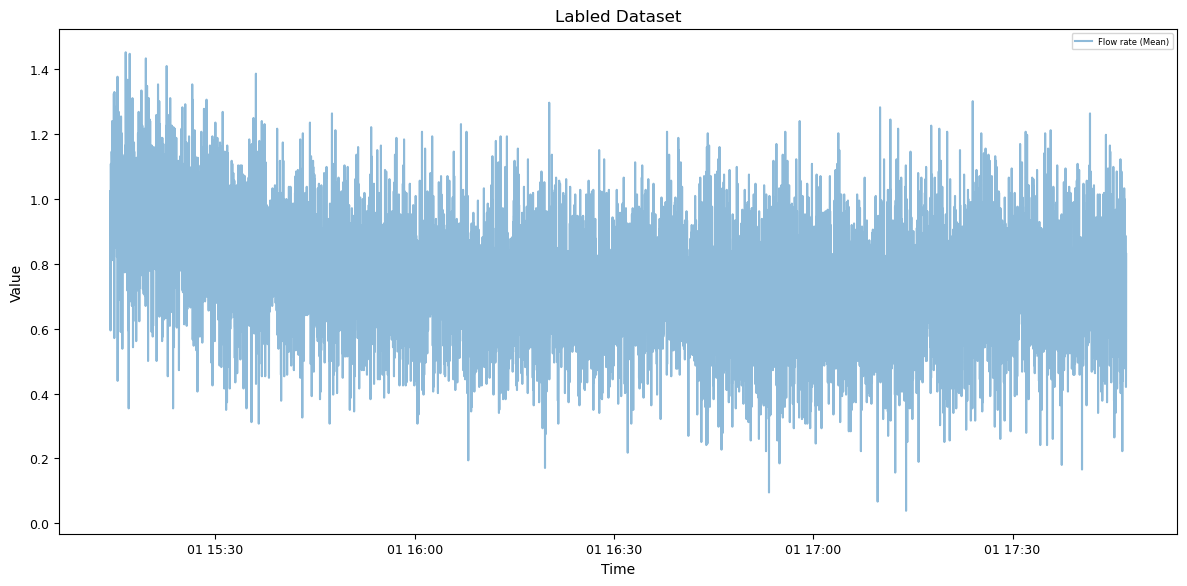

In [39]:
set_no_plug(dataset4)
dv.visualize_plug_event(dataset4, plug_column="Plug", name="Labled Dataset")

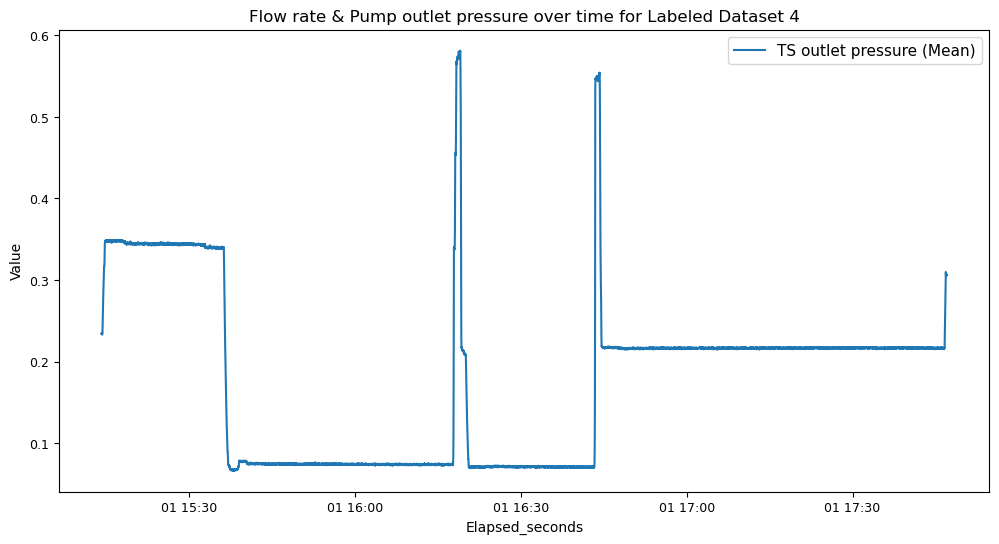

In [40]:
dv.visualize_key_column(dataset4, key="TS outlet pressure (Mean)", name="Labeled Dataset 4")

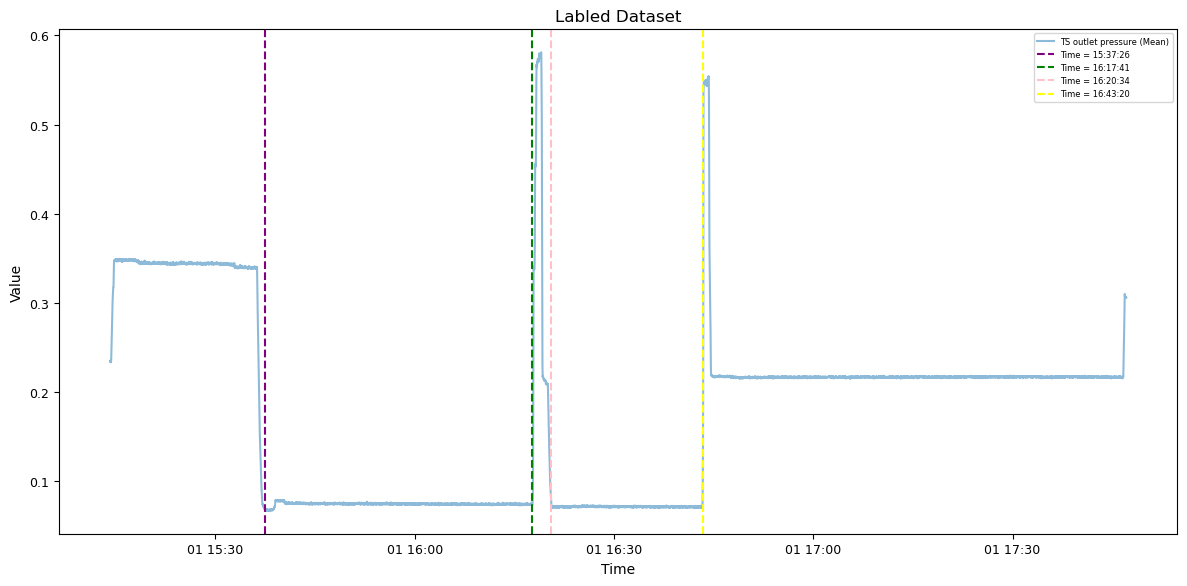

In [41]:
dv.visualize_plug_event(dataset4, plug_column="Plug", key="TS outlet pressure (Mean)", name="Labled Dataset", extra_id=4)

In [42]:
# Remove the time intervals that are not described in the case description, meaning manual adjustments
df = dataset4.copy()

df4 = df[
    ~(
        ((df.index >= df.index[0]) & (df.index <= pd.Timestamp("1900-01-01 15:37:26"))) |
        ((df.index >= pd.Timestamp("1900-01-01 16:17:41")) & (df.index <= pd.Timestamp("1900-01-01 16:20:34"))) |
        (df.index >= pd.Timestamp("1900-01-01 16:43:20"))
    )
]

In [43]:
df4.head(5)

,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean),flow_rate_missing,Plug
Time,,,,,,,,,,
1900-01-01 15:37:26.717,21.336225,-1.712753,23.477291,-2.001667,0.067945,0.068929,0.166779,0.919970,1,0
1900-01-01 15:37:27.717,21.337406,-1.708553,23.469546,-2.005867,0.067961,0.068515,0.165364,0.849248,1,0
1900-01-01 15:37:28.717,21.330449,-1.705796,23.465214,-2.007967,0.067751,0.067669,0.163627,0.688944,1,0
1900-01-01 15:37:29.717,21.334912,-1.700152,23.461801,-2.010854,0.067819,0.067853,0.162571,0.453204,1,0
1900-01-01 15:37:30.717,21.337013,-1.697396,23.461932,-2.014923,0.068281,0.068693,0.161156,0.910540,1,0


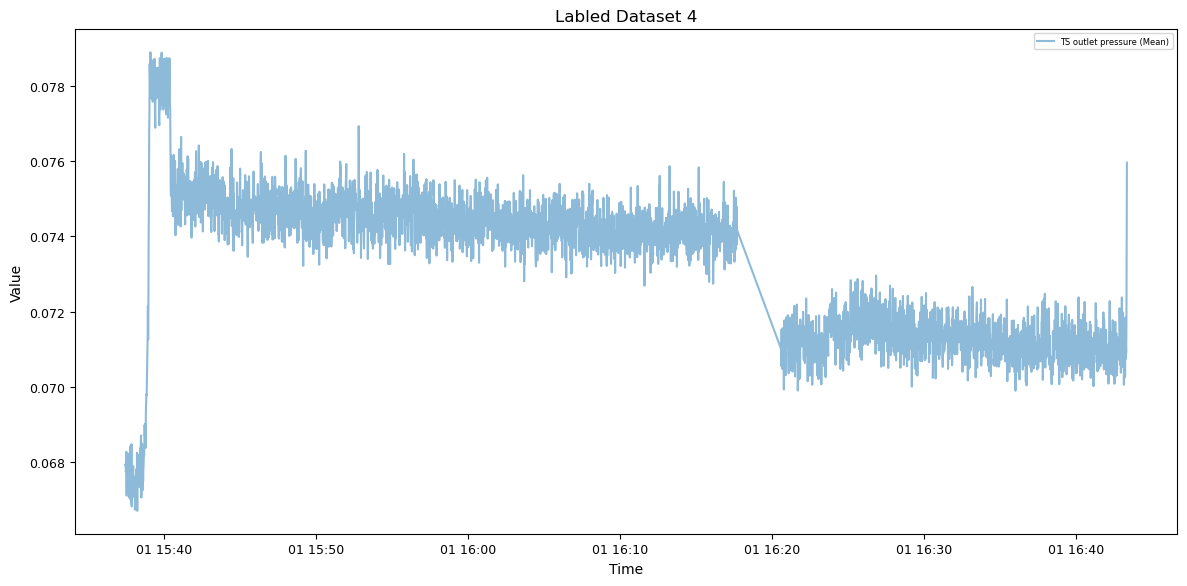

In [44]:
dv.visualize_plug_event(df4, plug_column="Plug", key="TS outlet pressure (Mean)", name="Labled Dataset 4")

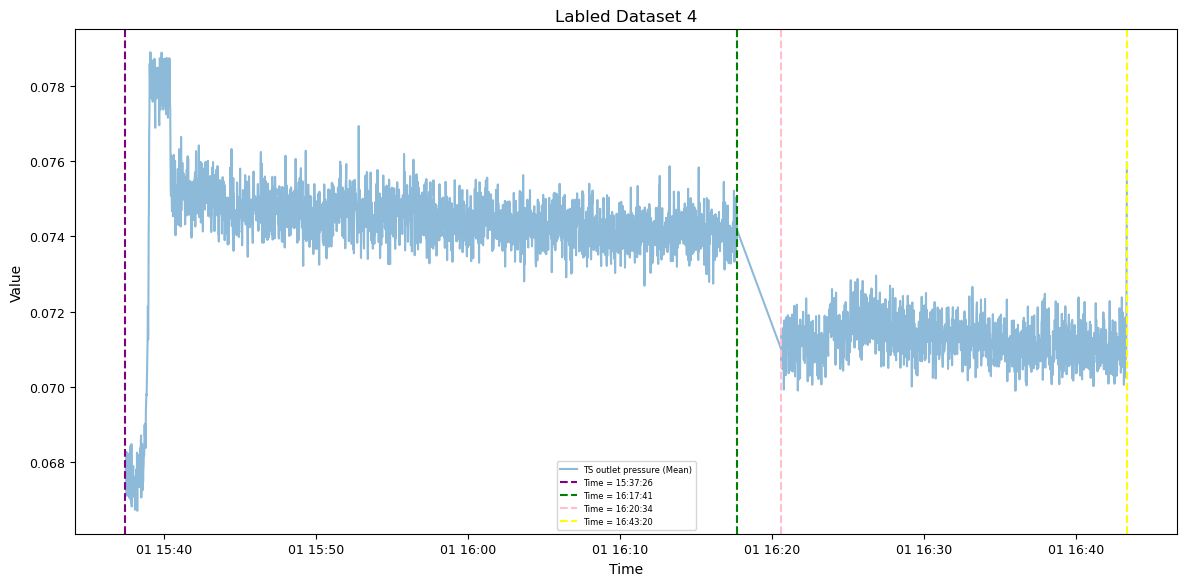

In [45]:
dv.visualize_plug_event(df4, plug_column="Plug", key="TS outlet pressure (Mean)", name="Labled Dataset 4", extra_id=4)

In [46]:
dataset4 = df4

In [47]:
# check for big values
print("Max values in dataset4:\n", dataset4.max())
print("Min values in dataset4:\n", dataset4.min())
print(dataset4.info())

Max values in dataset4:
 Temperature TS outlet (Mean)    21.530623
Temperature TS inlet (Mean)      0.457931
Bypass temperature (Mean)       23.477291
Tank temperature (Mean)         -1.477327
TS outlet pressure (Mean)        0.078887
TS inlet pressure (Mean)         0.079698
Pump outlet pressure (Mean)      0.223032
Flow rate (Mean)                 1.264151
flow_rate_missing                1.000000
Plug                             0.000000
dtype: float64
Min values in dataset4:
 Temperature TS outlet (Mean)    21.280964
Temperature TS inlet (Mean)     -1.780874
Bypass temperature (Mean)       23.034506
Tank temperature (Mean)         -2.678518
TS outlet pressure (Mean)        0.066717
TS inlet pressure (Mean)         0.066913
Pump outlet pressure (Mean)      0.124967
Flow rate (Mean)                 0.193889
flow_rate_missing                1.000000
Plug                             0.000000
dtype: float64
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3781 entries, 1900-01-01 15

In [48]:
dataset4.describe(include='all')

,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean),flow_rate_missing,Plug
count,3781.000000,3781.000000,3781.000000,3781.000000,3781.000000,3781.000000,3781.000000,3781.000000,3781.0,3781.0
mean,21.402293,-0.733659,23.208798,-1.976479,0.073235,0.073201,0.131899,0.746305,1.0,0.0
std,0.047574,0.550341,0.119348,0.244610,0.001945,0.001753,0.007176,0.157676,0.0,0.0
min,21.280964,-1.780874,23.034506,-2.678518,0.066717,0.066913,0.124967,0.193889,1.0,0.0
25%,21.371272,-1.155185,23.101062,-2.120054,0.071442,0.071828,0.126676,0.641796,1.0,0.0
50%,21.407894,-0.740158,23.163154,-1.980798,0.073952,0.073534,0.132611,0.745522,1.0,0.0
75%,21.435721,-0.440242,23.325933,-1.812668,0.074608,0.074416,0.133594,0.853963,1.0,0.0
max,21.530623,0.457931,23.477291,-1.477327,0.078887,0.079698,0.223032,1.264151,1.0,0.0


In [49]:
contains_infinite_or_big_values(dataset4)

False

# Dataset 5
Plug at 70 mins

In [50]:
show_info(dataset5)

Dataset columns: ['TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
TS inlet pressure (Mean)           float64
Pump outlet pressure (Mean)        float64
Differential pressure (Mean)       float64
Flow rate (Mean)                   float64
Tank temperature (Mean)            float64
Temperature TS inlet (Mean)        float64
Temperature TS outlet (Mean)       float64
Bypass temperature (Mean)          float64
Temperature TS outlet (Std Dev)    float64
Temperature TS inlet (Std Dev)     float64
Bypass 

,TS inlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
2021-08-21 11:07:40.450,0.652198,0.002561,0.216821,1197.850879,21.892479,-6.356868,-5.944637,-5.825225,0.244302,0.724920,0.213840,0.282836,0.018072,0.081870,0.004608,11.816486
2021-08-21 11:07:40.949,0.650550,0.002615,0.216269,1196.577000,21.904315,-6.356699,-5.943776,-5.804735,0.247066,0.757112,0.213078,0.283316,0.018405,0.080948,0.004419,11.061990
2021-08-21 11:07:41.453,0.651297,0.002800,0.215000,1192.332124,21.883107,-6.318099,-5.939004,-5.823056,0.254509,0.747501,0.219824,0.281944,0.018836,0.079520,0.004669,11.592692
2021-08-21 11:07:41.949,0.651998,0.002484,0.215635,1189.644134,21.905444,-6.318045,-5.936312,-5.803727,0.245705,0.761614,0.199970,0.279040,0.018200,0.080179,0.005180,11.194329
2021-08-21 11:07:42.453,0.656662,0.002737,0.219138,1189.778269,21.904721,-6.317839,-5.936660,-5.802740,0.244332,0.777832,0.206917,0.256907,0.018160,0.082592,0.004637,10.450238


In [51]:
# Find 70 minutes marker
start_time = dataset5.index.min()
marker_time = start_time + pd.Timedelta(minutes=70)
print(f"70 minutes marker timestamp: {marker_time}")

# set plug
dataset5['Plug'] = np.where(dataset5.index >= marker_time, 1, 0)

70 minutes marker timestamp: 2021-08-21 12:17:40.450000


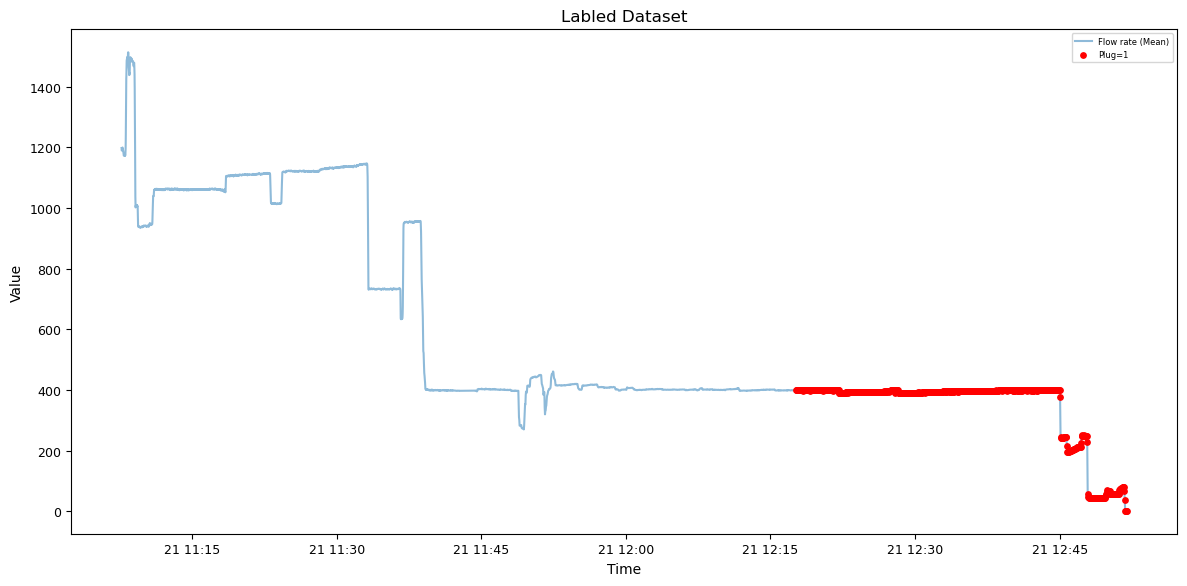

In [52]:
dv.visualize_plug_event(dataset5, plug_column="Plug", name="Labled Dataset")

# Dataset 6
No plug - manual adjustments

In [53]:
show_info(dataset6)

Dataset columns: ['TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
TS inlet pressure (Mean)           float64
Pump outlet pressure (Mean)        float64
Differential pressure (Mean)       float64
Flow rate (Mean)                   float64
Tank temperature (Mean)            float64
Temperature TS inlet (Mean)        float64
Temperature TS outlet (Mean)       float64
Bypass temperature (Mean)          float64
Temperature TS outlet (Std Dev)    float64
Temperature TS inlet (Std Dev)     float64
Bypass 

,TS inlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
2021-09-23 11:44:15.469,-0.000953,0.000388,-0.002267,0.751986,22.254471,23.476945,22.523866,23.597269,0.204264,0.149411,0.118877,0.198649,0.013532,0.004897,0.005212,3.493279
2021-09-23 11:44:15.973,-0.000864,0.000299,-0.002195,0.701742,22.275812,23.469334,22.524412,23.596239,0.177941,0.149632,0.125484,0.187145,0.013116,0.005382,0.005186,3.441039
2021-09-23 11:44:16.474,-0.000679,0.000365,-0.002517,0.576880,22.277582,23.477137,22.522801,23.594067,0.177954,0.144385,0.118495,0.207919,0.012904,0.005223,0.005290,3.247005
2021-09-23 11:44:16.970,-0.000762,0.000494,-0.002137,0.809020,22.254735,23.465830,22.521484,23.593299,0.201474,0.144347,0.118798,0.196353,0.014150,0.005094,0.005319,2.960882
2021-09-23 11:44:17.469,-0.000832,0.000511,-0.002550,0.612487,22.248877,23.471958,22.525223,23.593919,0.214081,0.154330,0.122937,0.168015,0.014046,0.004871,0.005322,3.166494


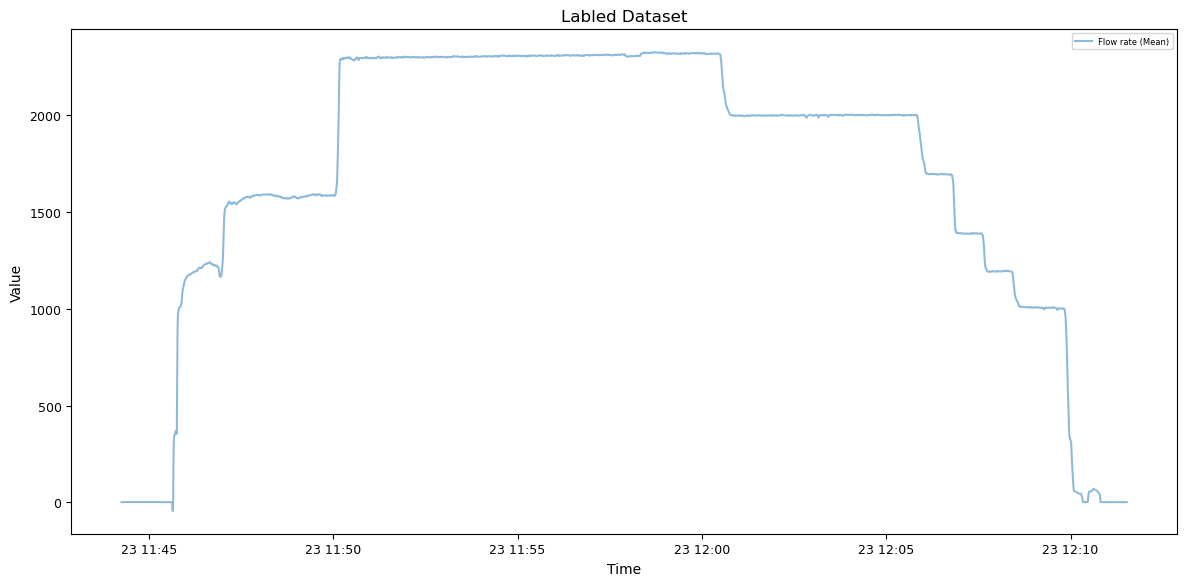

In [54]:
set_no_plug(dataset6)
dv.visualize_plug_event(dataset6, plug_column="Plug", name="Labled Dataset")

# Dataset 7
No plug

In [55]:
show_info(dataset7)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 11:05:25.279,-4.685960,-4.767171,24.552289,-4.856727,0.638409,0.981819,1.100481,2002.167506
1900-01-01 11:05:26.279,-4.648682,-4.732914,24.528003,-4.837302,0.639438,0.983993,1.102310,2000.616334
1900-01-01 11:05:27.279,-4.679922,-4.736195,24.537323,-4.852527,0.641821,0.987001,1.105452,2000.390024
1900-01-01 11:05:28.279,-4.664958,-4.732389,24.538505,-4.827196,0.641307,0.986917,1.106306,2001.936481
1900-01-01 11:05:29.279,-4.651307,-4.724776,24.532991,-4.832052,0.640892,0.984943,1.103081,2001.144393


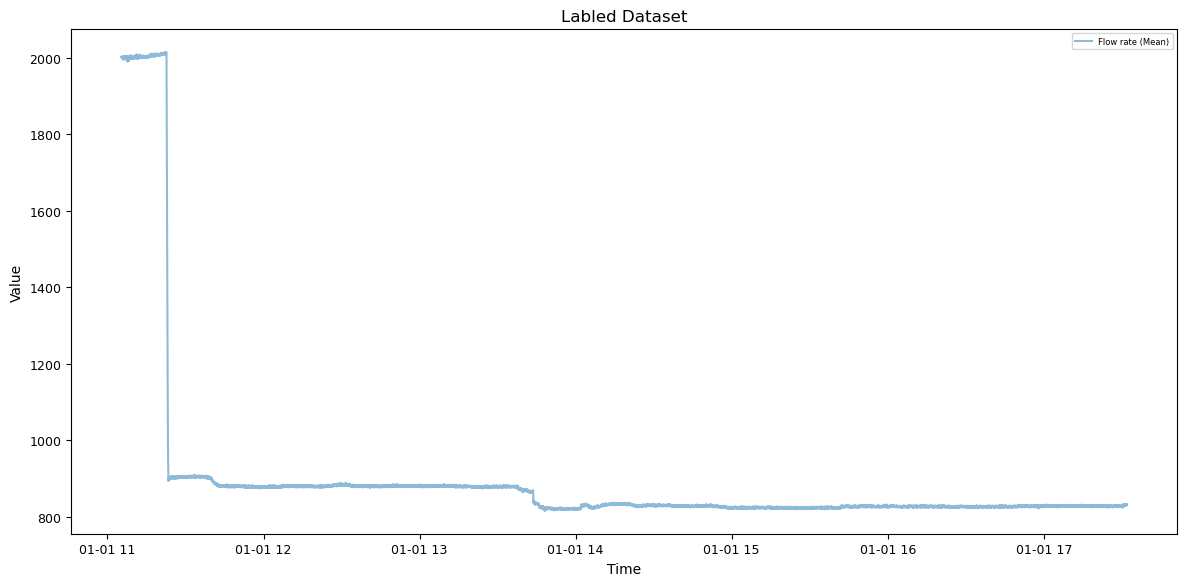

In [56]:
set_no_plug(dataset7)
dv.visualize_plug_event(dataset7, plug_column="Plug", name="Labled Dataset")

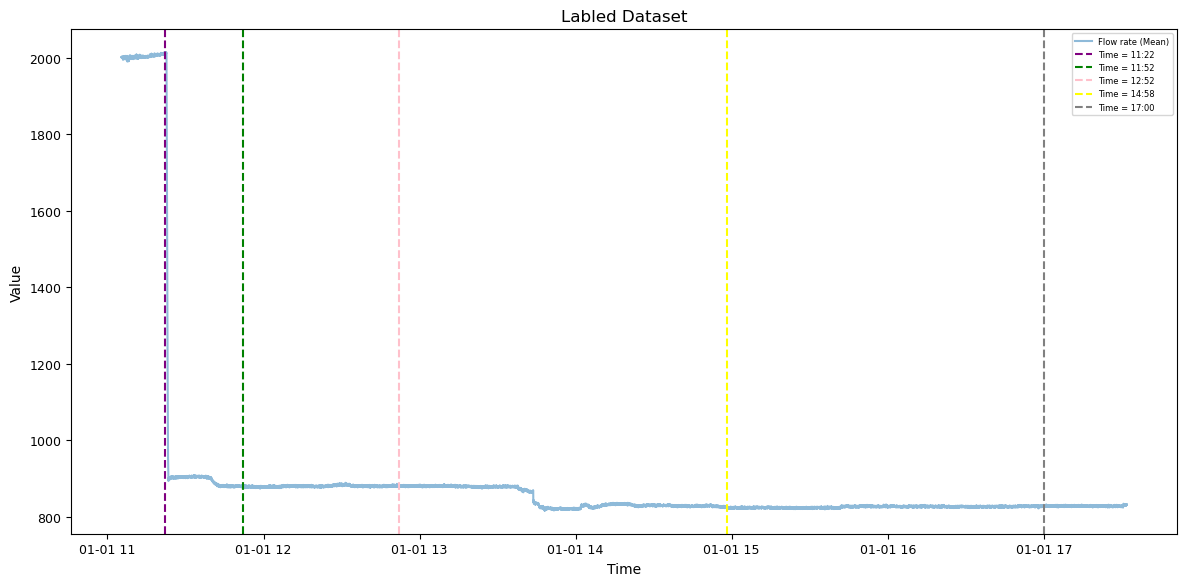

In [57]:
# Check for specific times in dataset7
dv.visualize_plug_event(dataset7, plug_column="Plug", name="Labled Dataset", extra_id=7)

# Dataset 8
Loop block - 15:11:12-15:16:10  - first run
orifice block - 15:19:56-15:24:32 - second run

In [58]:
show_info(dataset8)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 4
Duplicate index timestamps: 4
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 14:51:06.330,22.084809,23.496209,22.423823,22.306702,-0.001149,-0.000124,0.037587,1.127421
1900-01-01 14:51:07.330,22.086515,23.472452,22.425135,22.309064,-0.001296,-0.000103,0.037991,1.004836
1900-01-01 14:51:08.330,22.086122,23.481640,22.424741,22.308014,-0.001181,-0.000035,0.038083,0.948259
1900-01-01 14:51:09.330,22.088222,23.485972,22.425135,22.310245,-0.000960,0.000044,0.038221,1.103847
1900-01-01 14:51:10.330,22.084546,23.490697,22.424085,22.312214,-0.001223,0.000075,0.037973,1.094418


In [59]:
# cut out 
# 1500 - 1700 and 2000 - 2200 
dataset8 = cut(dataset8, 1500, 1700)
dataset8 = cut(dataset8, 2000, 2200)

In [60]:
print(dataset8.index[:5])
print(dataset8.index.dtype)
print(type(dataset8.index[0]))

# Check if any plugs fall in the expected range
start = pd.Timestamp('1900-01-01 15:11:12')
end = pd.Timestamp('1900-01-01 15:16:10')
print("Matches found:", ((dataset8.index >= start) & (dataset8.index <= end)).sum())

# Check actual time range of dataset8
print("Index min:", dataset8.index.min())
print("Index max:", dataset8.index.max())

DatetimeIndex(['1900-01-01 14:51:06.330000', '1900-01-01 14:51:07.330000',
               '1900-01-01 14:51:08.330000', '1900-01-01 14:51:09.330000',
               '1900-01-01 14:51:10.330000'],
              dtype='datetime64[ns]', name='Time', freq=None)
datetime64[ns]
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
Matches found: 294
Index min: 1900-01-01 14:51:06.330000
Index max: 1900-01-01 15:41:20.330000


In [61]:
# find first plug
start_time_first_plug = '15:11:12'
end_time_first_plug = '15:16:10'

start_time_second_plug = '15:19:56'
end_time_second_plug = '15:24:32'

set_plug_at_time(dataset8, start_time_first_plug, end_time_first_plug)
set_plug_at_time(dataset8, start_time_second_plug, end_time_second_plug)

In [62]:
cut_time = dataset8.index[0] + pd.Timedelta(seconds=1500)

first_dataset8 = dataset8[(dataset8.index < cut_time)]
second_dataset8 = dataset8[(dataset8.index > cut_time)]

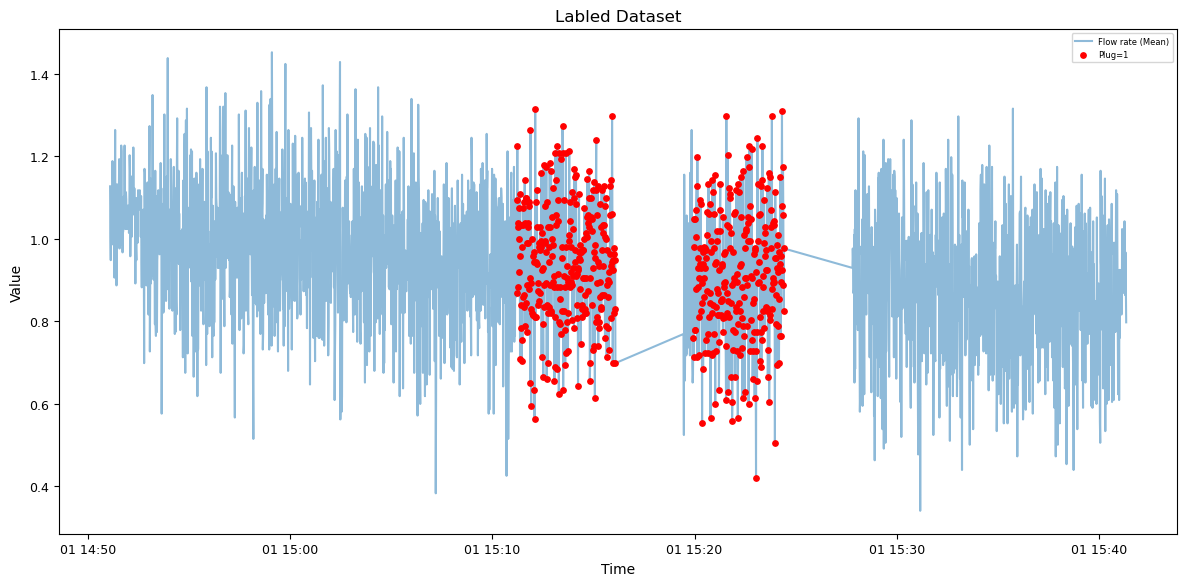

In [63]:
dv.visualize_plug_event(dataset8, plug_column="Plug", name="Labled Dataset")

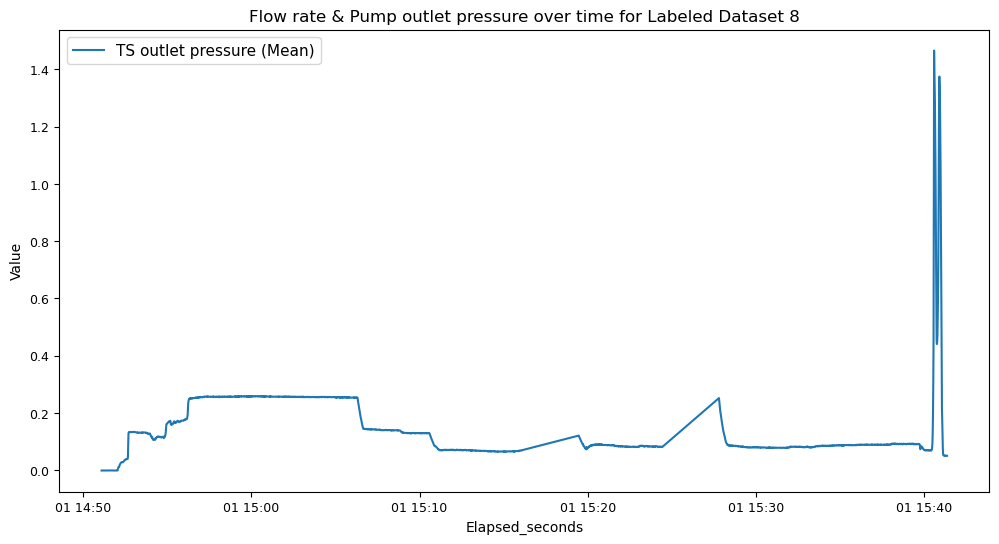

In [64]:
dv.visualize_key_column(dataset8, key="TS outlet pressure (Mean)", name="Labeled Dataset 8")

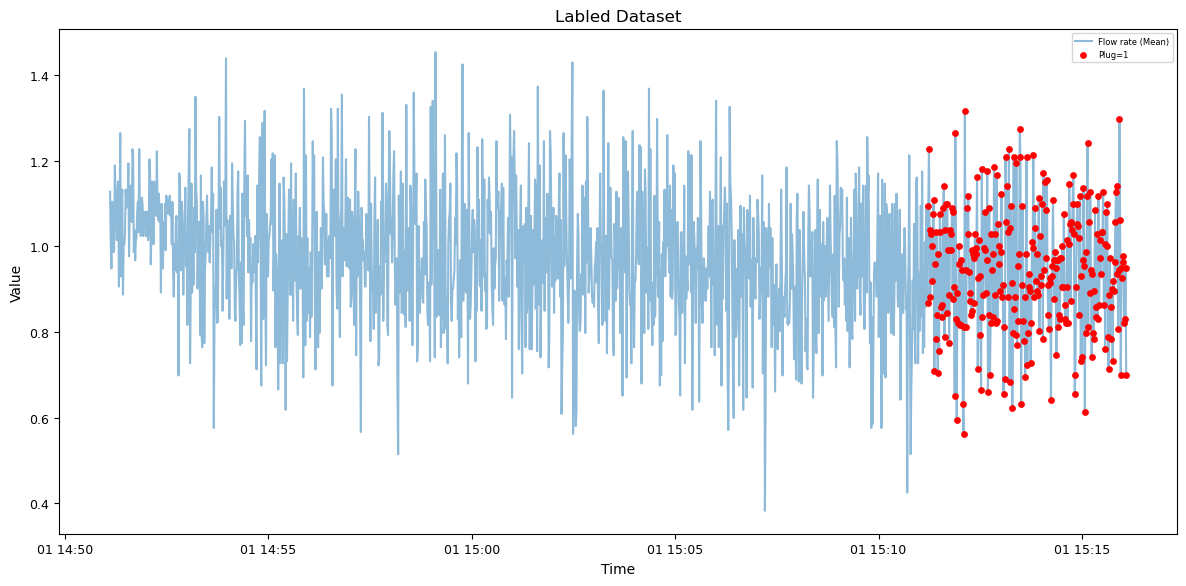

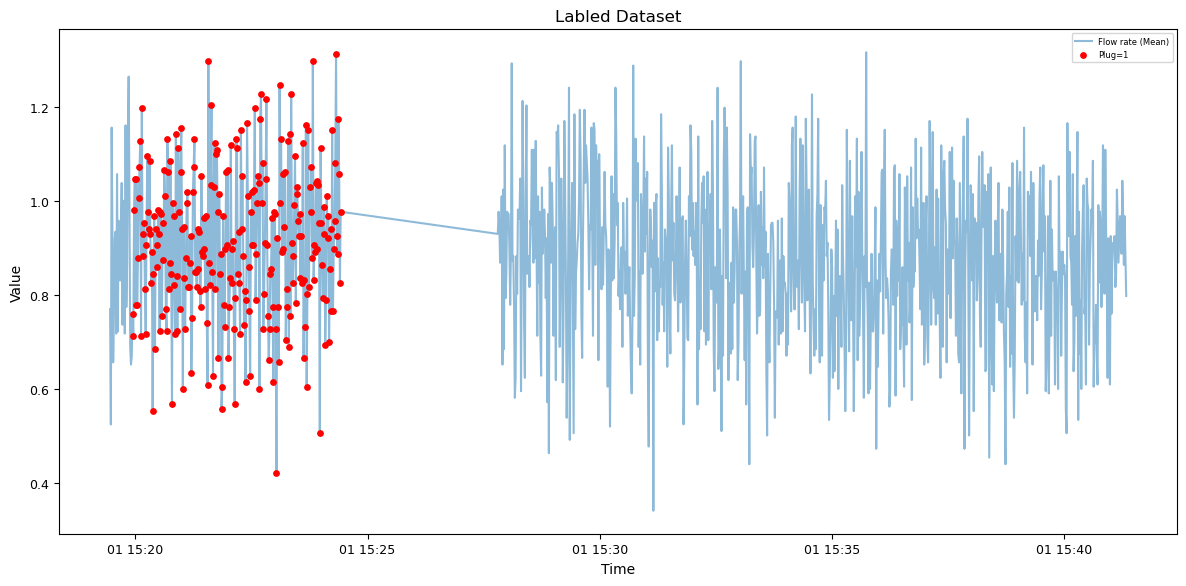

In [65]:
dv.visualize_plug_event(first_dataset8, plug_column="Plug", name="Labled Dataset")
dv.visualize_plug_event(second_dataset8, plug_column="Plug", name="Labled Dataset")

# Dataset 9
13:15:49-13:44:06 - test section block

In [66]:
show_info(dataset9)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 12:50:22.552,22.105023,22.784024,22.143948,21.820424,-0.001144,0.001010,0.030614,0.962403
1900-01-01 12:50:23.552,22.103317,22.764467,22.139616,21.815305,-0.001050,0.001136,0.030568,1.070844
1900-01-01 12:50:24.552,22.107123,22.770242,22.134496,21.820030,-0.001286,0.001178,0.030586,1.136851
1900-01-01 12:50:25.552,22.105286,22.778642,22.133052,21.819111,-0.001212,0.001152,0.030779,1.150995
1900-01-01 12:50:26.552,22.104104,22.769192,22.133183,21.818061,-0.001223,0.000873,0.030467,1.188714


In [67]:
set_plug_at_time(dataset9, '13:15:49', '13:44:06')

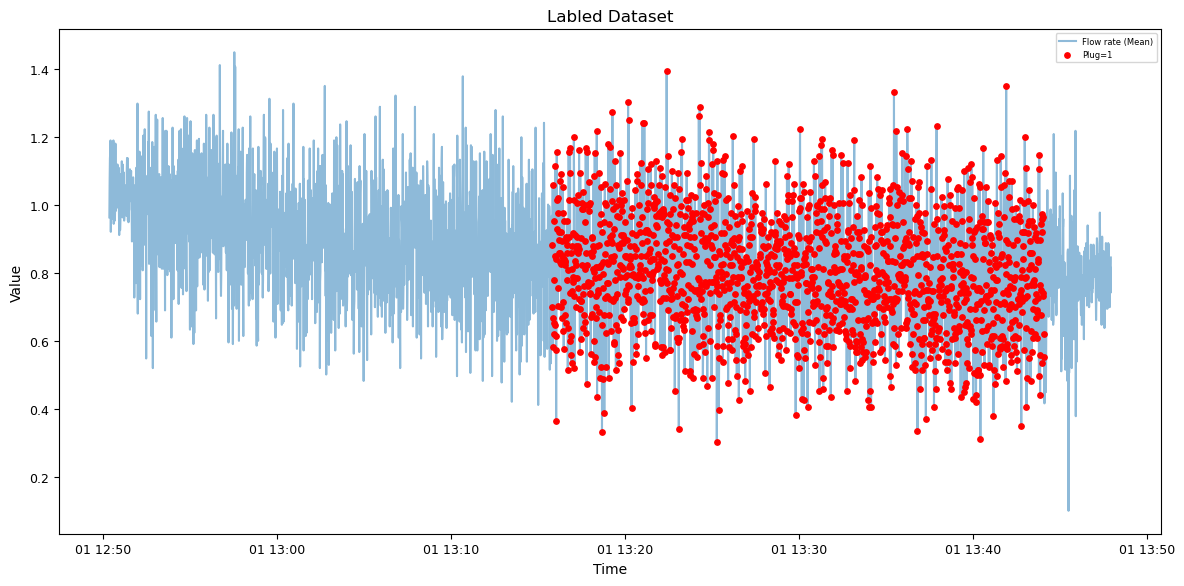

In [68]:
dv.visualize_plug_event(dataset9, plug_column="Plug", name="Labled Dataset")

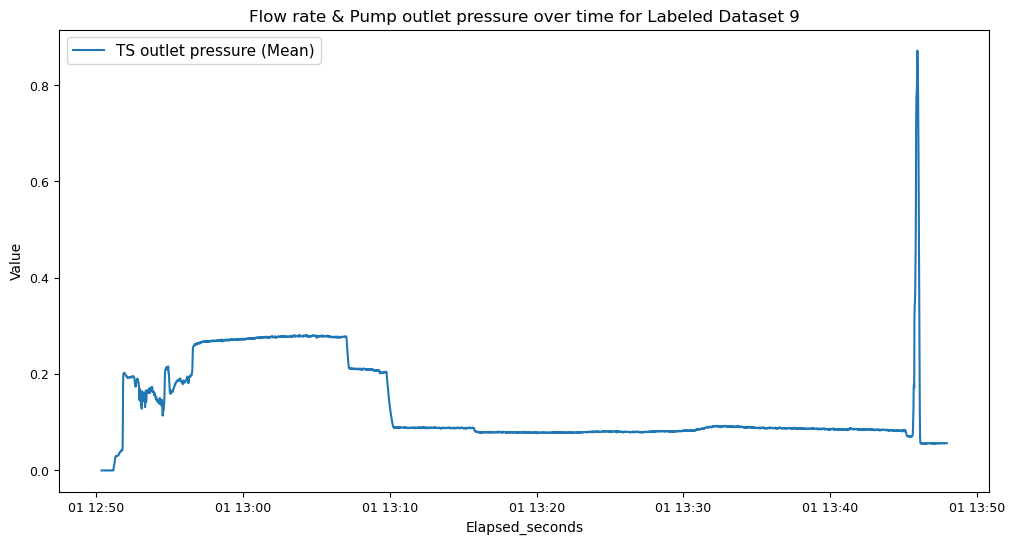

In [69]:
dv.visualize_key_column(dataset9, key="TS outlet pressure (Mean)", name="Labeled Dataset 9")

# Dataset 10
3 runs

13:57:15 - 13:59:21 -> Run 1 - loop blockage

14:01:48 - 14:06:57 -> Run 2 - orifice blockage

14:27:16 - 14:31:41 -> Run 3 - no block

In [70]:
show_info(dataset10)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:55:39.663,21.999620,-2.009256,24.051350,-2.157328,0.354064,0.366056,0.646015,0.622937
1900-01-01 13:55:40.663,21.992532,-2.007550,24.048330,-2.145516,0.354553,0.366539,0.646474,1.042555
1900-01-01 13:55:41.663,21.996995,-2.005187,24.044261,-2.144203,0.354437,0.365835,0.645950,0.740807
1900-01-01 13:55:42.663,21.989644,-2.004662,24.046624,-2.144203,0.354327,0.365914,0.646400,1.165140
1900-01-01 13:55:43.663,21.976124,-2.009256,24.031921,-2.149060,0.354642,0.365273,0.646134,0.886966


In [71]:
set_plug_at_time(dataset10, '13:57:15', '13:59:21')
set_plug_at_time(dataset10, '14:01:48', '14:06:57')

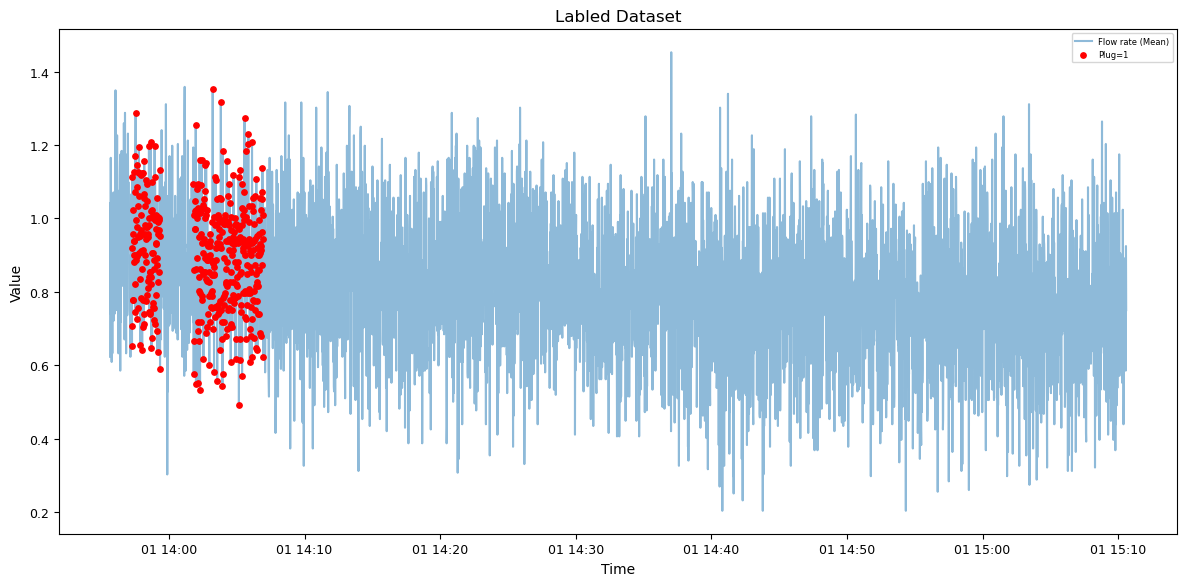

In [72]:
dv.visualize_plug_event(dataset10, plug_column="Plug", name="Labled Dataset")

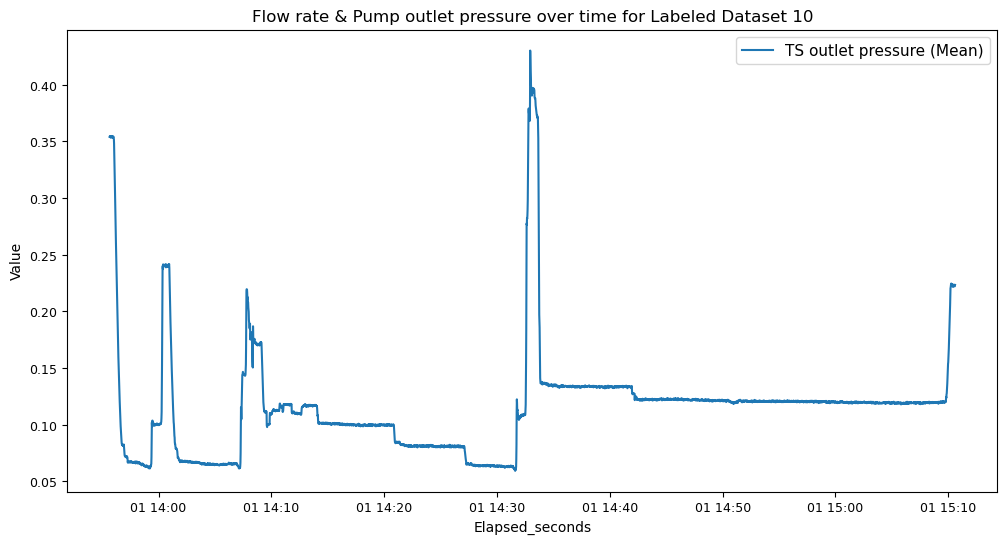

In [73]:
dv.visualize_key_column(dataset10, key="TS outlet pressure (Mean)", name="Labeled Dataset 10")

# Dataset 11

4 runs

Time of runs:

14:33:05 – 15:14:26 -> Run 1

15:20:20 – 15:28:59 -> Run 2 - block

15:33:24 – 15:44:06 -> Run 3 - block

15:49:03 - 16:08:07 -> Run 4 - block

In [74]:
show_info(dataset11)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:56:49.628,21.208376,-6.971719,23.120621,-7.084154,0.251241,0.261635,0.463390,3.786573
1900-01-01 13:56:50.628,21.208376,-6.971456,23.122066,-7.081135,0.251745,0.262880,0.463335,3.720566
1900-01-01 13:56:51.628,21.223209,-6.960037,23.127054,-7.081267,0.251136,0.261336,0.462848,3.687562
1900-01-01 13:56:52.628,21.197350,-6.963318,23.122197,-7.075360,0.252407,0.262402,0.463518,3.711136
1900-01-01 13:56:53.628,21.198794,-6.957412,23.116027,-7.074573,0.252134,0.262449,0.463188,3.692277


In [75]:
set_plug_at_time(dataset11, '15:20:20', '15:28:59')
set_plug_at_time(dataset11, '15:33:24', '15:44:06')
set_plug_at_time(dataset11, '15:49:03', '16:08:07')

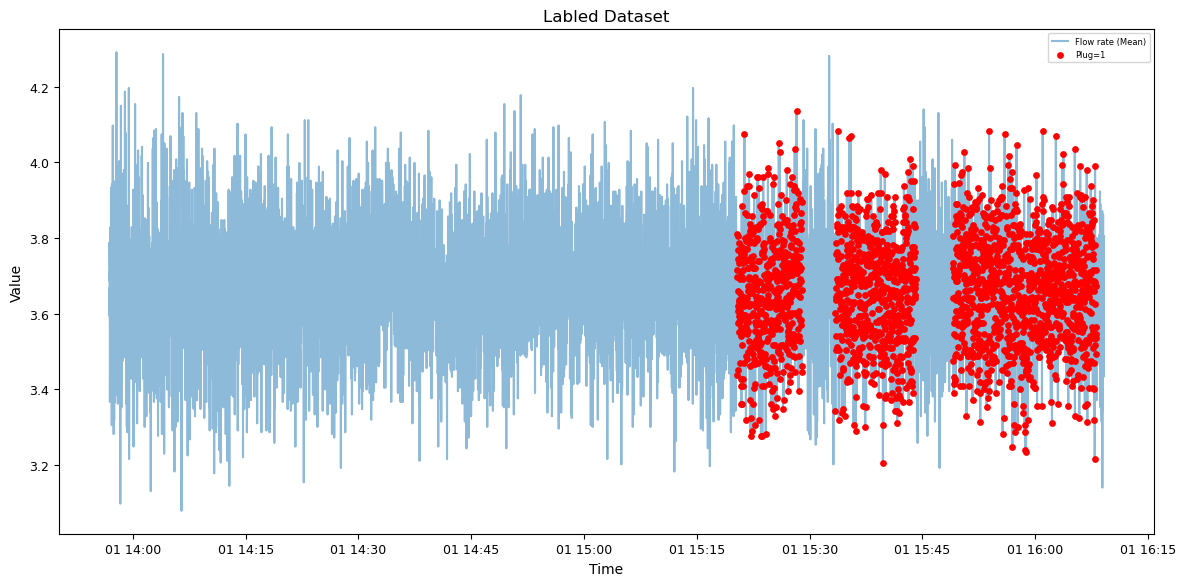

In [76]:
dv.visualize_plug_event(dataset11, plug_column="Plug", name="Labled Dataset")

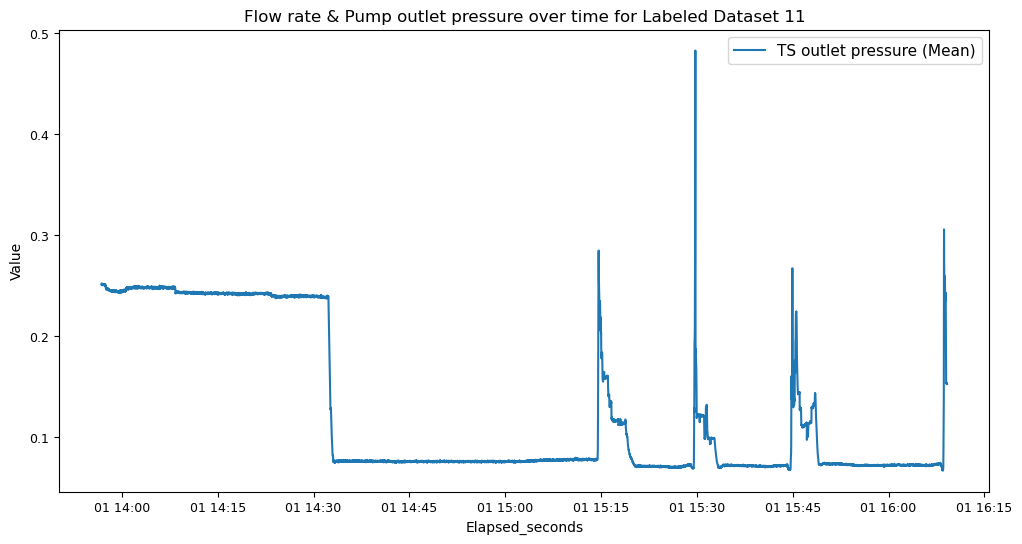

In [77]:
dv.visualize_key_column(dataset11, key="TS outlet pressure (Mean)", name="Labeled Dataset 11")

# Dataset 12
3 runs

Time-codes:

13:53:03 – 15:02:50

15:08:37 – 16:08:03

16:15:39 - 17:03:21 Loop blockage

In [78]:
show_info(dataset12)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:35:02.939,21.251430,-5.328284,22.052975,-5.492760,0.255420,0.269122,0.475168,1.683769
1900-01-01 13:35:03.939,21.254187,-5.318308,22.060589,-5.488297,0.254701,0.268671,0.474984,1.415025
1900-01-01 13:35:04.939,21.252086,-5.320540,22.060195,-5.481210,0.255132,0.268225,0.475122,1.443314
1900-01-01 13:35:05.939,21.230953,-5.324215,22.058620,-5.481341,0.254554,0.268639,0.474617,1.396165
1900-01-01 13:35:06.939,21.234760,-5.317258,22.063477,-5.478191,0.256155,0.269616,0.475710,1.853502


In [79]:
set_plug_at_time(dataset12, '16:15:39', '17:03:21')

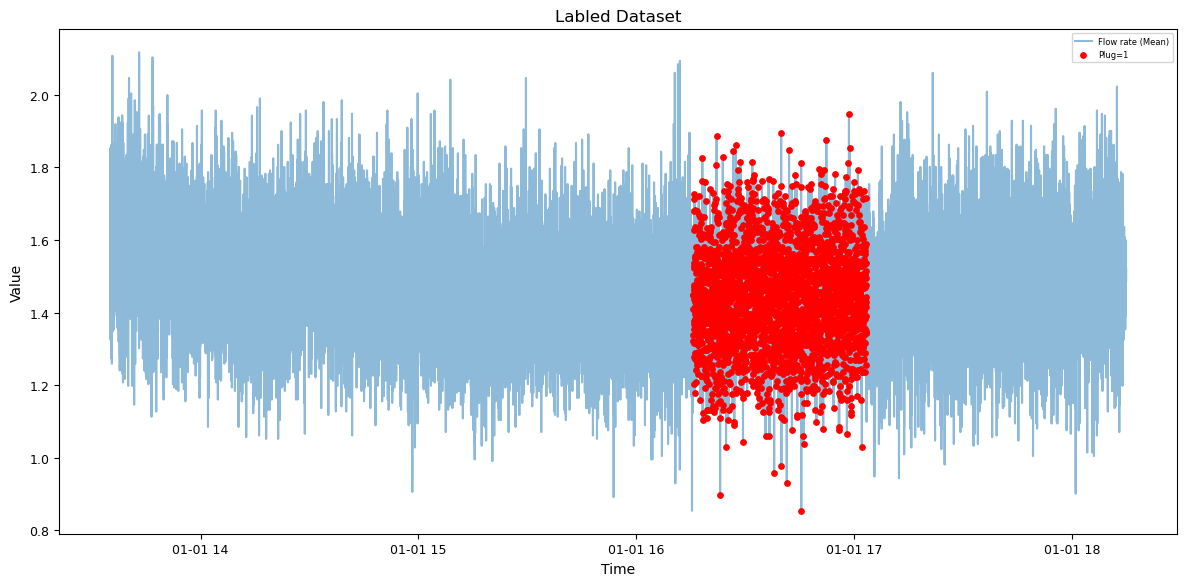

In [80]:
dv.visualize_plug_event(dataset12,   plug_column="Plug", name="Labled Dataset")

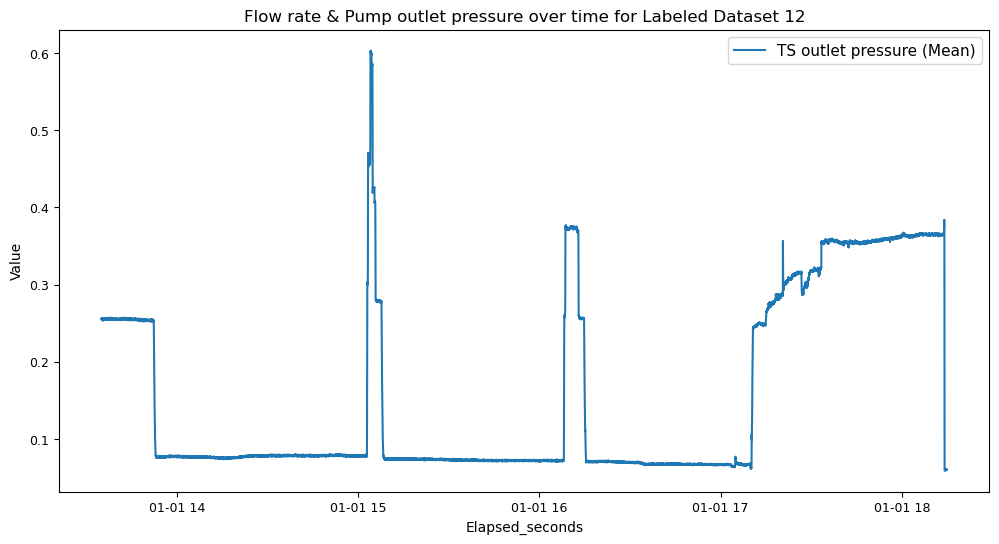

In [81]:
dv.visualize_key_column(dataset12, key="TS outlet pressure (Mean)", name="Labeled Dataset 12")

# Dataset 13
> new data

Target flowrate: Differential pressure test

Pressure difference measured in the range 2000-800 kg/h
Orfice blockage at 600kg/h of pressure difference.


In [82]:
show_info(dataset13)

Dataset columns: ['TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
TS inlet pressure (Mean)           float64
Pump outlet pressure (Mean)        float64
Differential pressure (Mean)       float64
Flow rate (Mean)                   float64
Tank temperature (Mean)            float64
Temperature TS inlet (Mean)        float64
Temperature TS outlet (Mean)       float64
Bypass temperature (Mean)          float64
Temperature TS outlet (Std Dev)    float64
Temperature TS inlet (Std Dev)     float64
Bypass 

,TS inlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
2021-10-01 09:24:54.672,0.000466,0.001626,-0.000470,1.132212,20.667575,23.683617,22.147018,22.637862,0.260384,0.256678,0.132427,0.751814,0.014425,0.006918,0.004982,4.738522
2021-10-01 09:24:55.176,-0.000332,0.001727,-0.000135,0.870128,20.739365,23.685747,22.165005,22.641643,0.257947,0.277226,0.125732,0.833738,0.013526,0.006416,0.004904,4.278510
2021-10-01 09:24:55.677,-0.000019,0.001423,-0.000757,0.906258,20.827817,23.710565,22.190586,22.640828,0.240683,0.244855,0.131860,0.825807,0.013855,0.007049,0.005110,4.579807
2021-10-01 09:24:56.176,0.000157,0.001500,-0.000507,1.349471,20.663894,23.668181,22.143539,22.639754,0.267119,0.270540,0.128743,0.762621,0.013506,0.007027,0.005022,4.683379
2021-10-01 09:24:56.672,-0.000646,0.001669,-0.000452,0.913582,20.778449,23.695525,22.177452,22.634156,0.252703,0.262686,0.122484,0.864748,0.013657,0.006340,0.005084,4.174759


In [83]:
#Set plug based on description
time = '2021-10-01 09:30:00.330000'

if 'Plug' not in dataset13.columns:
    dataset13['Plug'] = 0  
dataset13['Plug'] = np.where((dataset13.index >= time) & (dataset13["Flow rate (Mean)"] < 601), 1, dataset13['Plug'])

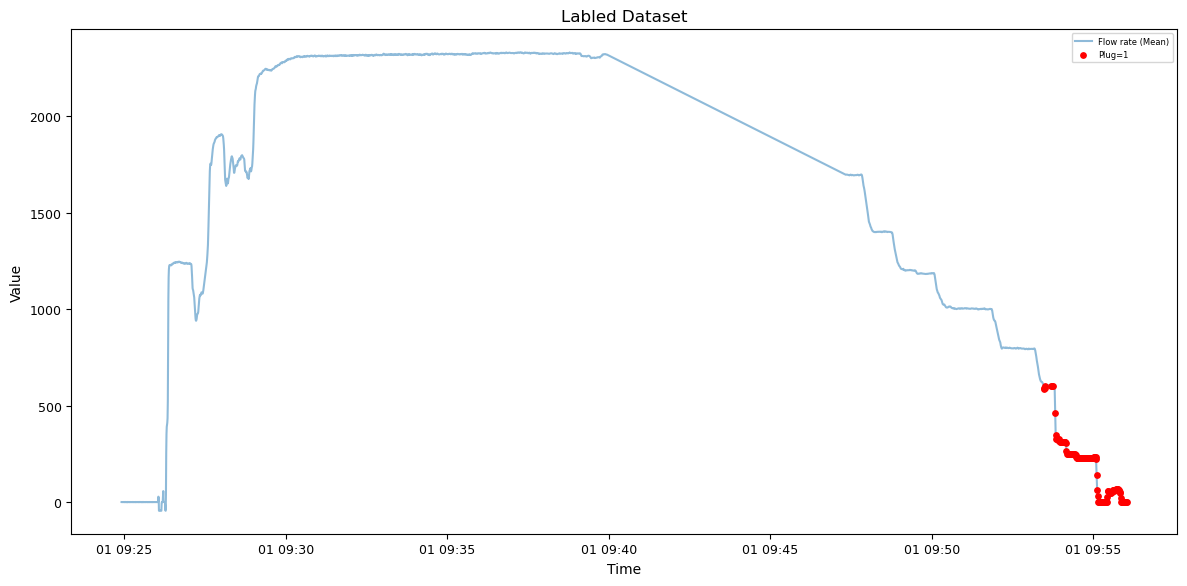

In [84]:
dv.visualize_plug_event(dataset13, plug_column="Plug", name="Labled Dataset")

# Dataset 14

In [85]:
show_info(dataset14)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 11:28:48.233,-5.329010,-5.536322,22.401900,-5.742002,0.658827,0.980575,1.102227,1932.892828
1900-01-01 11:28:49.233,-5.319952,-5.533040,22.421328,-5.732158,0.659825,0.982407,1.105286,1932.906972
1900-01-01 11:28:50.233,-5.317459,-5.512696,22.388773,-5.722708,0.660072,0.982150,1.104478,1934.726888
1900-01-01 11:28:51.233,-5.300132,-5.488808,22.415684,-5.708796,0.660129,0.983825,1.105975,1934.736318
1900-01-01 11:28:52.233,-5.301576,-5.478963,22.368819,-5.704727,0.663437,0.986476,1.108961,1936.650530


In [86]:
set_no_plug(dataset14)

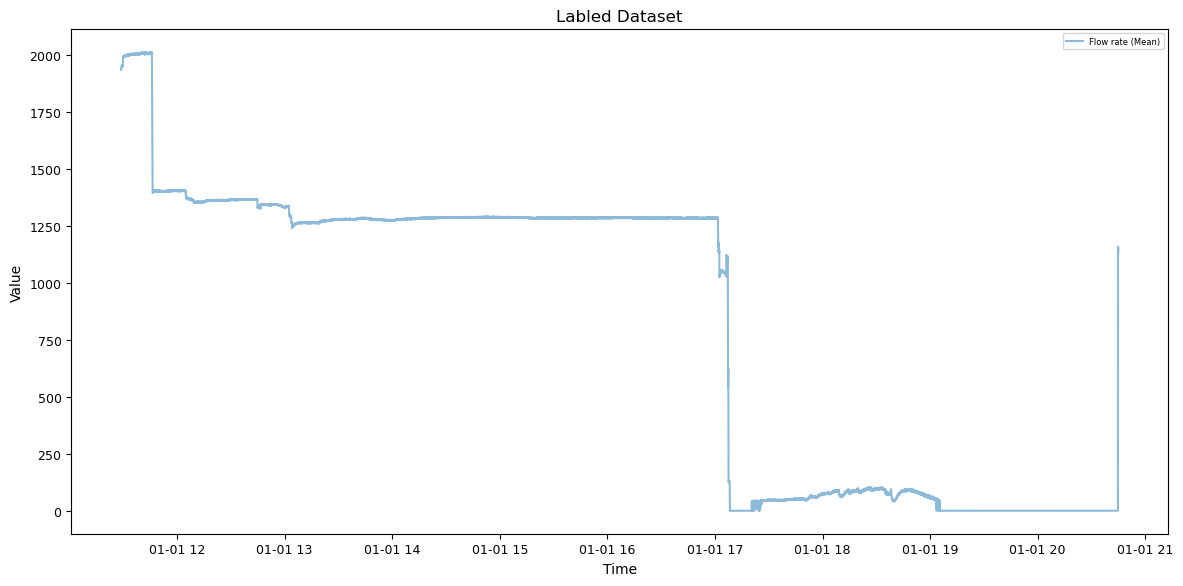

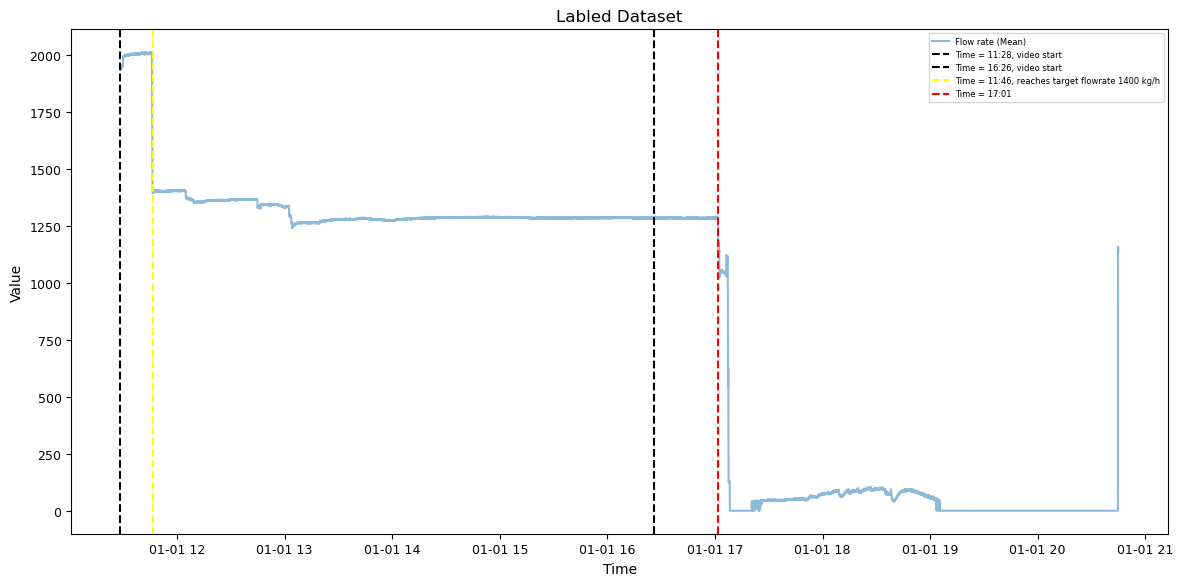

In [87]:
dv.visualize_plug_event(dataset14, plug_column="Plug", name="Labled Dataset")
dv.visualize_plug_event(dataset14, plug_column="Plug", name="Labled Dataset", extra_id=14)

In [88]:
# Find first stabilization point, target flowrate 1400 kg/h
first_1400 = dataset14[
    (dataset14["Flow rate (Mean)"] >= 1390) &
    (dataset14["Flow rate (Mean)"] <= 1410)
].index[0]

print(first_1400)
dataset14 = dataset14.loc[first_1400:]

1900-01-01 11:46:21.233000


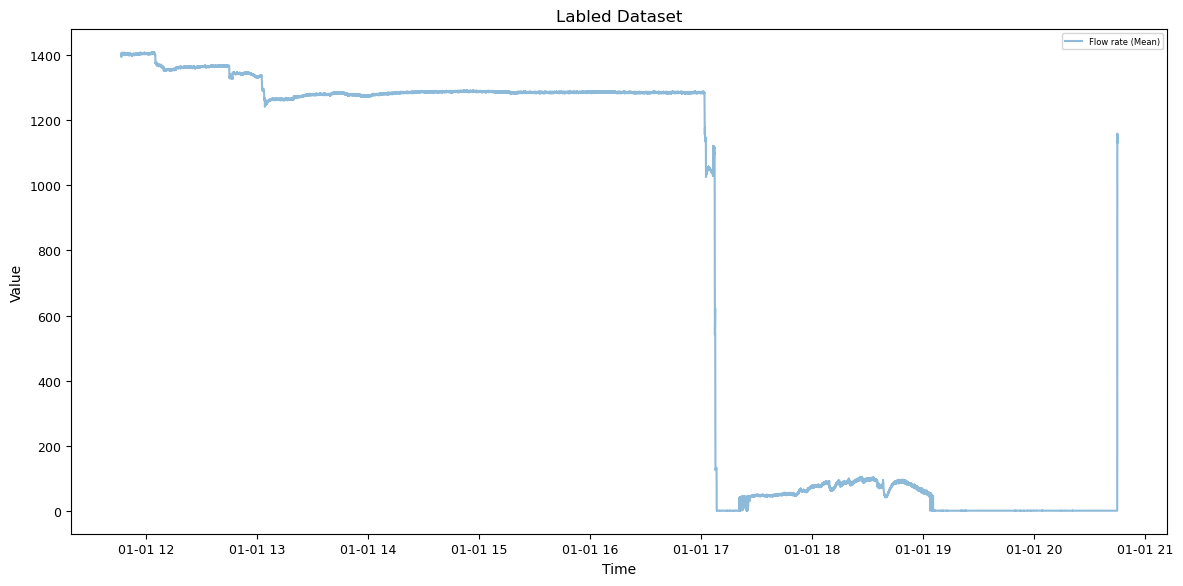

In [89]:
dv.visualize_plug_event(dataset14, plug_column="Plug", name="Labled Dataset")

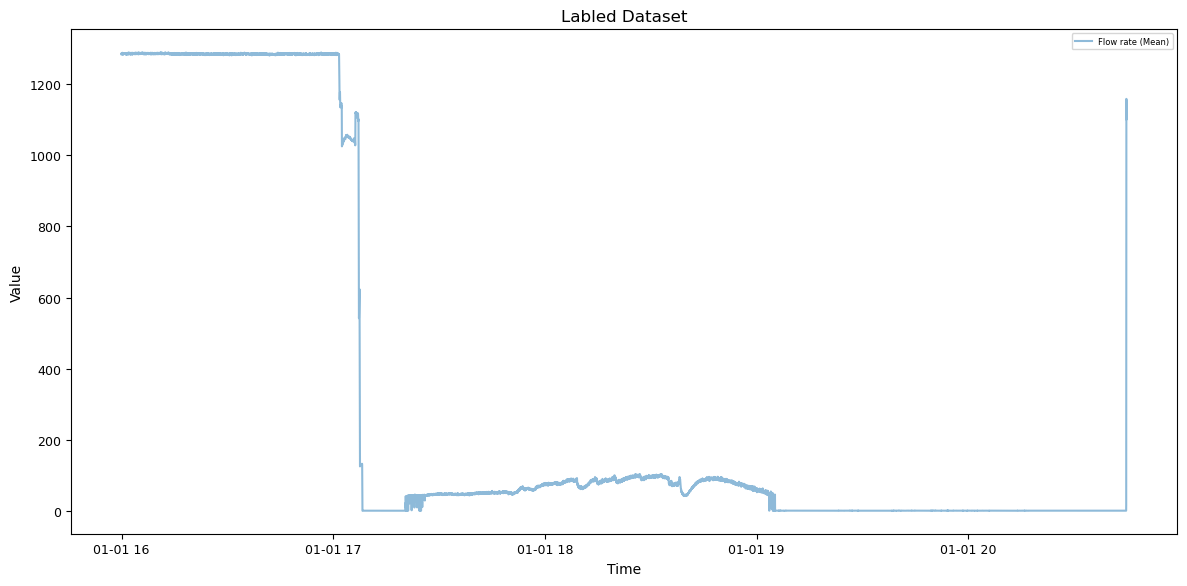

1900-01-01 17:01:44.233000


In [90]:
# Find plummet point, flowrate drops to 0
df14 = dataset14.copy().loc["1900-01-01 16:00:00": ]
dv.visualize_plug_event(df14, plug_column="Plug", name="Labled Dataset")
plummet_point = df14[
    (df14["Flow rate (Mean)"] >= 1200) &
    (df14["Flow rate (Mean)"] <= 1250)
].index[0]

print(plummet_point)

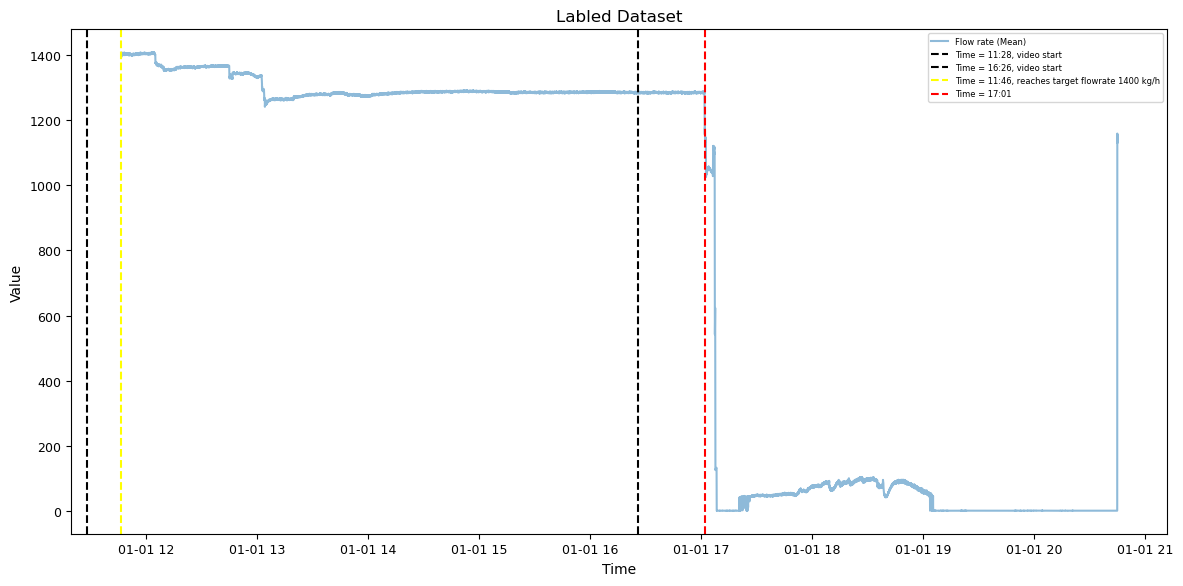

In [91]:
dv.visualize_plug_event(dataset14, plug_column="Plug", name="Labled Dataset", extra_id=14)

In [92]:
# Remove last section 
dataset14 = dataset14.loc[:plummet_point]

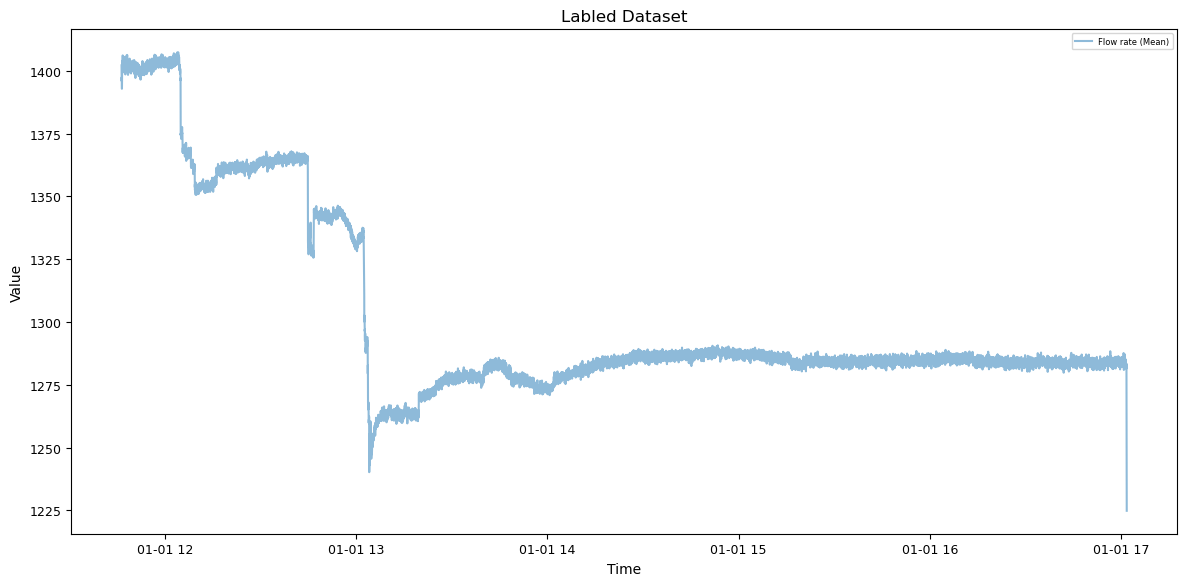

In [93]:
dv.visualize_plug_event(dataset14, plug_column="Plug", name="Labled Dataset")

# Dataset 15

13:42:38 – 13:47:05 – loop blockage

13:52:04 – 14:00:51 – test section plugging

14:07:56 – 14:15:36 – both loop and test section blocked

In [94]:
show_info(dataset15)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:19:41.191,22.534248,23.763706,22.602354,22.486644,-0.001186,-0.000612,0.034693,0.971833
1900-01-01 13:19:42.191,22.532935,23.775519,22.594347,22.487431,-0.001170,-0.000502,0.034684,0.674800
1900-01-01 13:19:43.191,22.530310,23.775519,22.594478,22.488613,-0.001034,-0.000507,0.034170,0.872822
1900-01-01 13:19:44.191,22.536086,23.777487,22.593428,22.484413,-0.001134,-0.000523,0.034941,1.051984
1900-01-01 13:19:45.191,22.533329,23.812926,22.591196,22.485200,-0.000876,-0.000586,0.034399,0.802100


In [95]:
set_plug_at_time(dataset15, '13:42:38', '13:47:05')
set_plug_at_time(dataset15, '13:52:04', '14:00:51')
set_plug_at_time(dataset15, '14:07:56', '14:15:36')

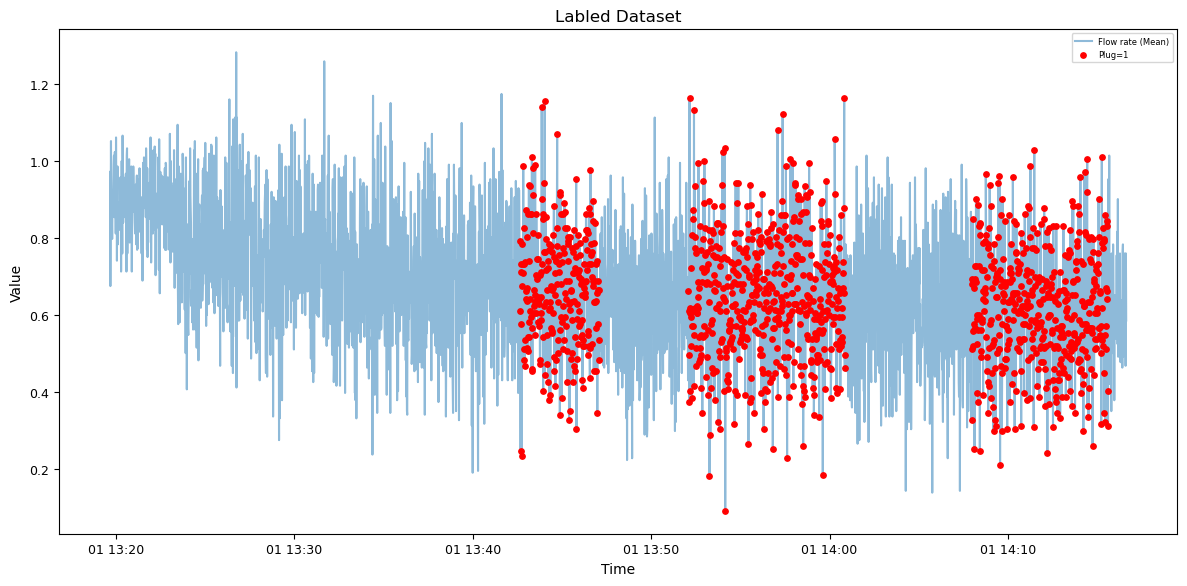

In [96]:
dv.visualize_plug_event(dataset15, plug_column="Plug", name="Labled Dataset")

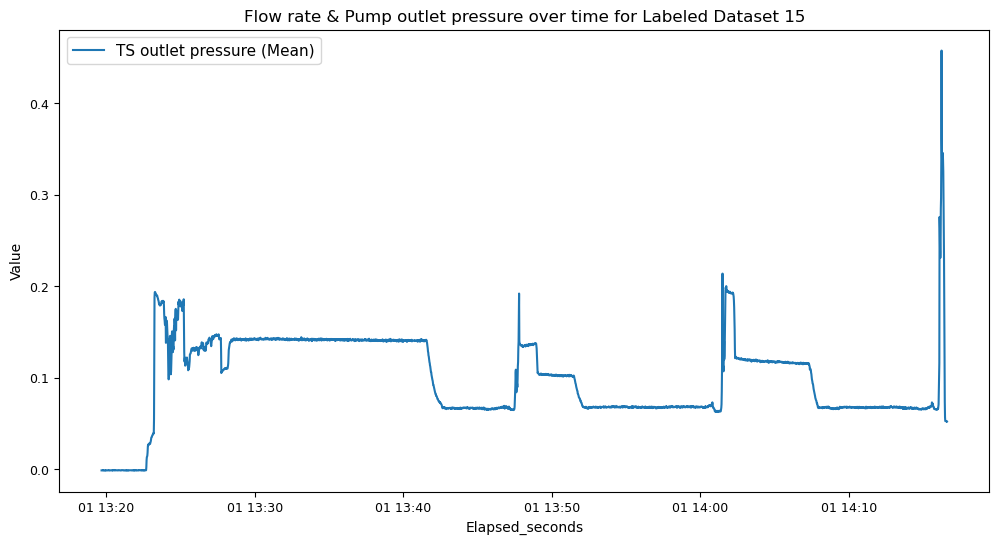

In [97]:
dv.visualize_key_column(dataset15, key="TS outlet pressure (Mean)", name="Labeled Dataset 15")

# Dataset 16

13:36:15 - 14:24:46

14:27:56 – 14:44:16

15:28:07 - 15:31:34

15:32:12 - 15:38:52

In [98]:
show_info(dataset16)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:23:44.389,21.077509,-5.584623,21.649966,-5.392748,0.222044,0.232044,0.409332,1.132136
1900-01-01 13:23:45.389,21.051650,-5.560997,21.647866,-5.310324,0.222070,0.231508,0.408863,1.264151
1900-01-01 13:23:46.389,21.059788,-5.552335,21.644190,-5.275280,0.221944,0.231724,0.408643,1.235862
1900-01-01 13:23:47.389,21.064908,-5.536059,21.645109,-5.310849,0.221508,0.231262,0.408817,1.103847
1900-01-01 13:23:48.389,21.044825,-5.527134,21.636839,-5.280793,0.221409,0.232207,0.408468,1.183999


In [99]:
set_plug_at_time(dataset16, '13:36:15', '14:24:46')
set_plug_at_time(dataset16, '14:27:56', '14:44:16')
set_plug_at_time(dataset16, '15:28:07', '15:31:34')
set_plug_at_time(dataset16, '15:32:12', '15:38:52')

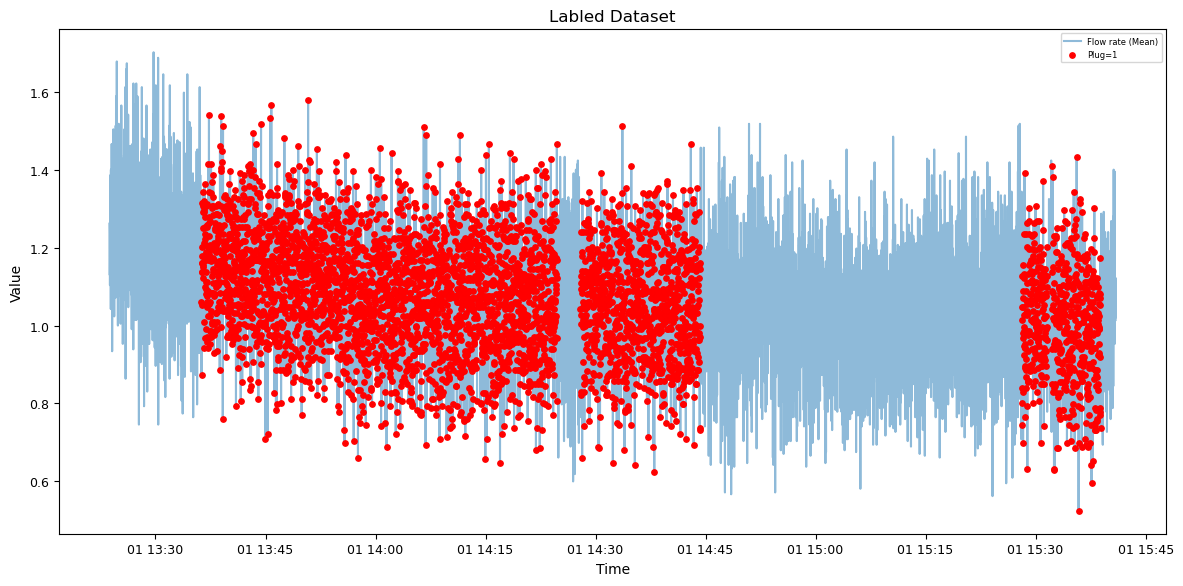

In [100]:
dv.visualize_plug_event(dataset16, plug_column="Plug", name="Labled Dataset")

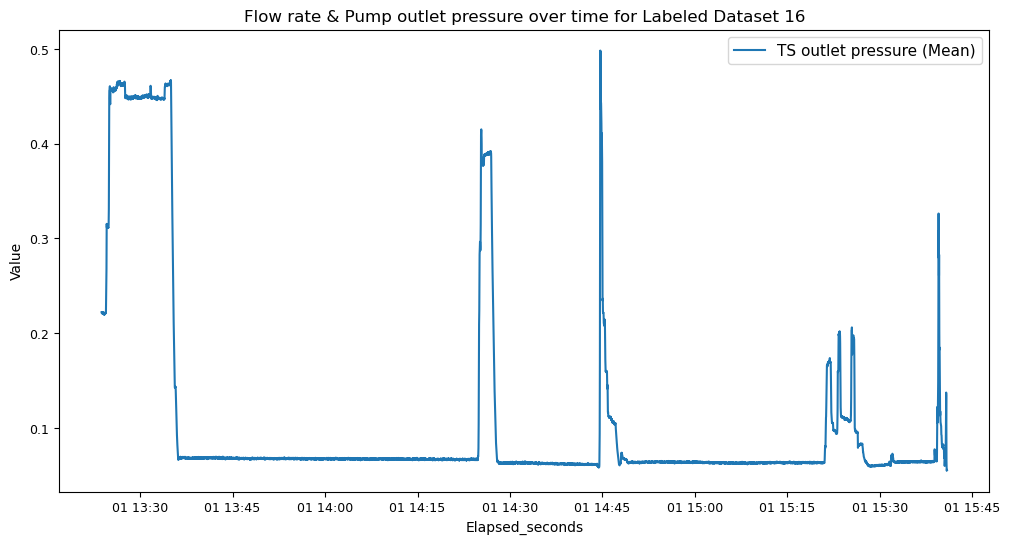

In [101]:
dv.visualize_key_column(dataset16, key="TS outlet pressure (Mean)", name="Labeled Dataset 16")

# Dataset 17

In [102]:
show_info(dataset17)

Dataset columns: ['TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
TS inlet pressure (Mean)           object
Pump outlet pressure (Mean)        object
Differential pressure (Mean)       object
Flow rate (Mean)                   object
Tank temperature (Mean)            object
Temperature TS inlet (Mean)        object
Temperature TS outlet (Mean)       object
Bypass temperature (Mean)          object
Temperature TS outlet (Std Dev)    object
Temperature TS inlet (Std Dev)     object
Bypass temperatur

,TS inlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
2021-12-07 10:41:58.843,"0,000836","0,00404","0,004198","3,945888","22,829479","23,483296","22,442092","23,99797","0,480887","0,190923","0,158951","0,602606","0,015283","0,006433","0,00609","5,141446"
2021-12-07 10:41:59.347,"0,000678","0,004164","0,003821","3,994624","22,81435","23,483396","22,456698","23,998394","0,469358","0,199789","0,160407","0,615641","0,014805","0,006316","0,006175","4,974747"
2021-12-07 10:41:59.842,"0,000699","0,00386","0,004809","3,784292","22,806458","23,486736","22,436005","23,999029","0,445332","0,191802","0,152511","0,571008","0,014498","0,006044","0,006356","5,189717"
2021-12-07 10:42:00.347,"0,001043","0,004008","0,005425","3,826238","22,825808","23,508137","22,465292","23,993446","0,442021","0,180949","0,162811","0,588595","0,014552","0,006455","0,006161","5,272929"
2021-12-07 10:42:00.843,"0,001154","0,003563","0,005216","3,556156","22,814925","23,507112","22,440504","23,988442","0,419631","0,173093","0,163582","0,578803","0,013906","0,006272","0,006103","5,048219"


In [103]:
#Convert object to float
dataset17_object_cols = dataset17.select_dtypes(include=['object']).columns

dataset17[dataset17_object_cols] = (
    dataset17[dataset17_object_cols]
      .apply(lambda s: s.astype(str).str.strip())   
      .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})  
      .apply(lambda s: s.str.replace(",", ".", regex=False)) 
)

dataset17[dataset17_object_cols] = dataset17[dataset17_object_cols].apply(pd.to_numeric, errors="coerce")


In [104]:
show_info(dataset17)

Dataset columns: ['TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
TS inlet pressure (Mean)           float64
Pump outlet pressure (Mean)        float64
Differential pressure (Mean)       float64
Flow rate (Mean)                   float64
Tank temperature (Mean)            float64
Temperature TS inlet (Mean)        float64
Temperature TS outlet (Mean)       float64
Bypass temperature (Mean)          float64
Temperature TS outlet (Std Dev)    float64
Temperature TS inlet (Std Dev)     float64
Bypass 

,TS inlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
2021-12-07 10:41:58.843,0.000836,0.004040,0.004198,3.945888,22.829479,23.483296,22.442092,23.997970,0.480887,0.190923,0.158951,0.602606,0.015283,0.006433,0.006090,5.141446
2021-12-07 10:41:59.347,0.000678,0.004164,0.003821,3.994624,22.814350,23.483396,22.456698,23.998394,0.469358,0.199789,0.160407,0.615641,0.014805,0.006316,0.006175,4.974747
2021-12-07 10:41:59.842,0.000699,0.003860,0.004809,3.784292,22.806458,23.486736,22.436005,23.999029,0.445332,0.191802,0.152511,0.571008,0.014498,0.006044,0.006356,5.189717
2021-12-07 10:42:00.347,0.001043,0.004008,0.005425,3.826238,22.825808,23.508137,22.465292,23.993446,0.442021,0.180949,0.162811,0.588595,0.014552,0.006455,0.006161,5.272929
2021-12-07 10:42:00.843,0.001154,0.003563,0.005216,3.556156,22.814925,23.507112,22.440504,23.988442,0.419631,0.173093,0.163582,0.578803,0.013906,0.006272,0.006103,5.048219


In [105]:
set_no_plug(dataset17)

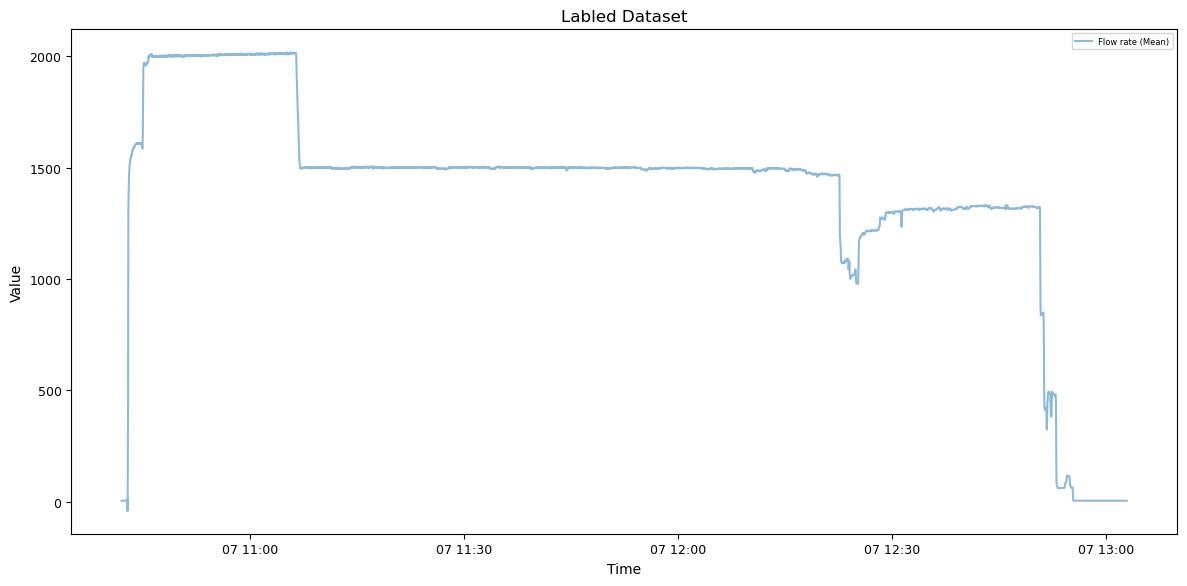

In [106]:
dv.visualize_plug_event(dataset17, plug_column="Plug", name="Labled Dataset")

In [107]:
# Find first stabilization point, target flowrate 1500 kg/h
first_1500 = dataset17[
    (dataset17["Flow rate (Mean)"] >= 1490) &
    (dataset17["Flow rate (Mean)"] <= 1510)
].index[0]

print(first_1500)
dataset17 = dataset17.loc[first_1500:]

2021-12-07 10:43:03.843000


In [108]:
# Find first stabilization point, target flowrate 1500 kg/h also after rise
df17 = dataset17.copy().loc["2021-12-07 11:00:00": ]
first_1500 = df17[
    (df17["Flow rate (Mean)"] >= 1490) &
    (df17["Flow rate (Mean)"] <= 1510)
].index[0]

print(first_1500)
dataset17 = dataset17.loc[first_1500:]

2021-12-07 11:06:58.754000


In [109]:
dataset17.loc["2021-12-07 12:22:33":"2021-12-07 12:22:37"].head(4)

,TS inlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev),Plug
Time,,,,,,,,,,,,,,,,,
2021-12-07 12:22:33.470,0.398205,0.581783,0.640668,1469.543741,-1.328289,-1.177969,-0.942394,24.963808,0.216708,0.242757,0.208697,0.982130,0.055841,0.024165,0.024196,10.645539,0
2021-12-07 12:22:35.472,0.377703,0.574778,0.642816,1467.597740,-1.316755,-1.170467,-0.954378,24.953554,0.215887,0.229823,0.210593,1.007817,0.057075,0.075455,0.061324,14.610444,0
2021-12-07 12:22:37.470,0.292908,0.608597,0.652489,1296.161913,-1.332557,-1.173899,-0.948961,24.955337,0.231677,0.235352,0.207151,0.979719,0.055104,0.025230,0.027918,172.308597,0


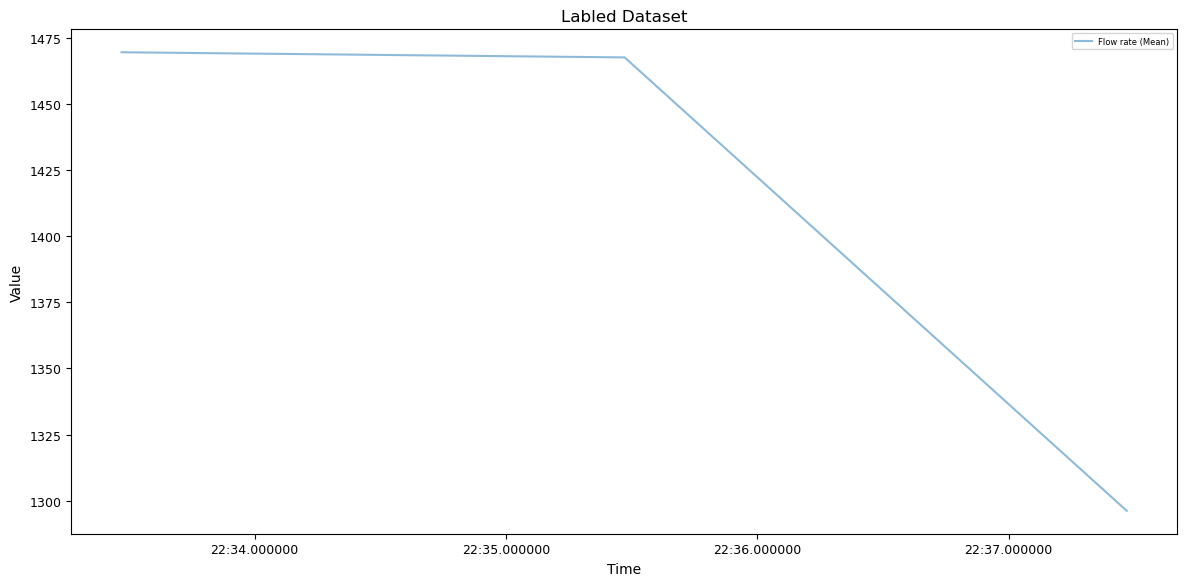

In [110]:
dv.visualize_plug_event(dataset17.loc["2021-12-07 12:22:33":"2021-12-07 12:22:37"], plug_column="Plug", name="Labled Dataset")

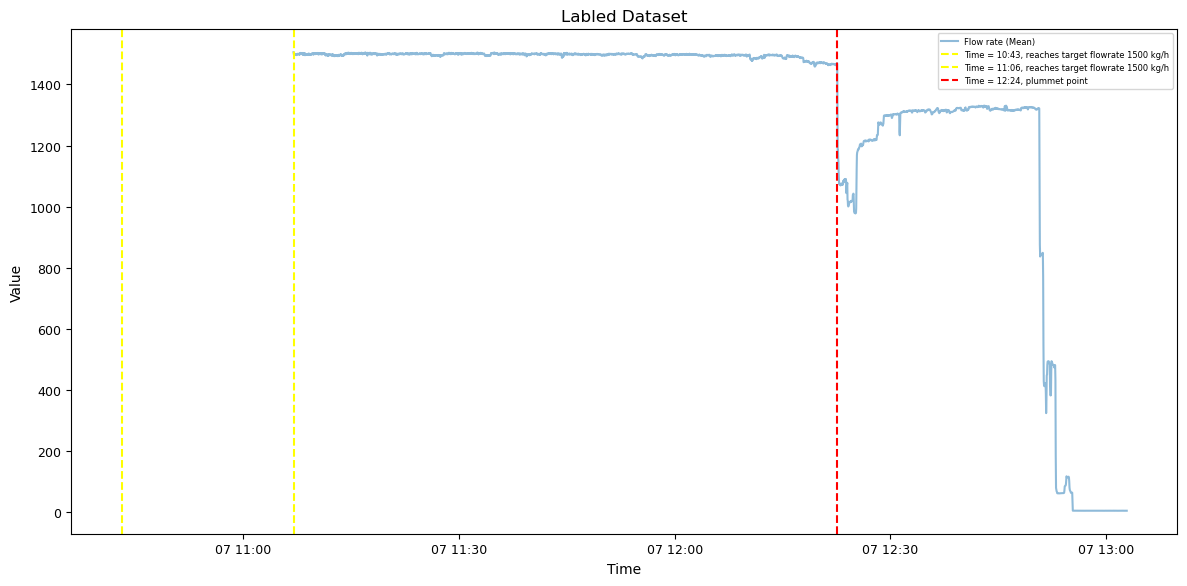

In [111]:
dv.visualize_plug_event(dataset17, plug_column="Plug", name="Labled Dataset", extra_id=17)

In [112]:
# Find plummet point, flowrate drops to 1000
plummet_point = df17[
    (df17["Flow rate (Mean)"] >= 1290) &
    (df17["Flow rate (Mean)"] <= 1400)
].index[0]

print(plummet_point)
dataset17 = dataset17.loc[:plummet_point]

2021-12-07 12:22:37.470000


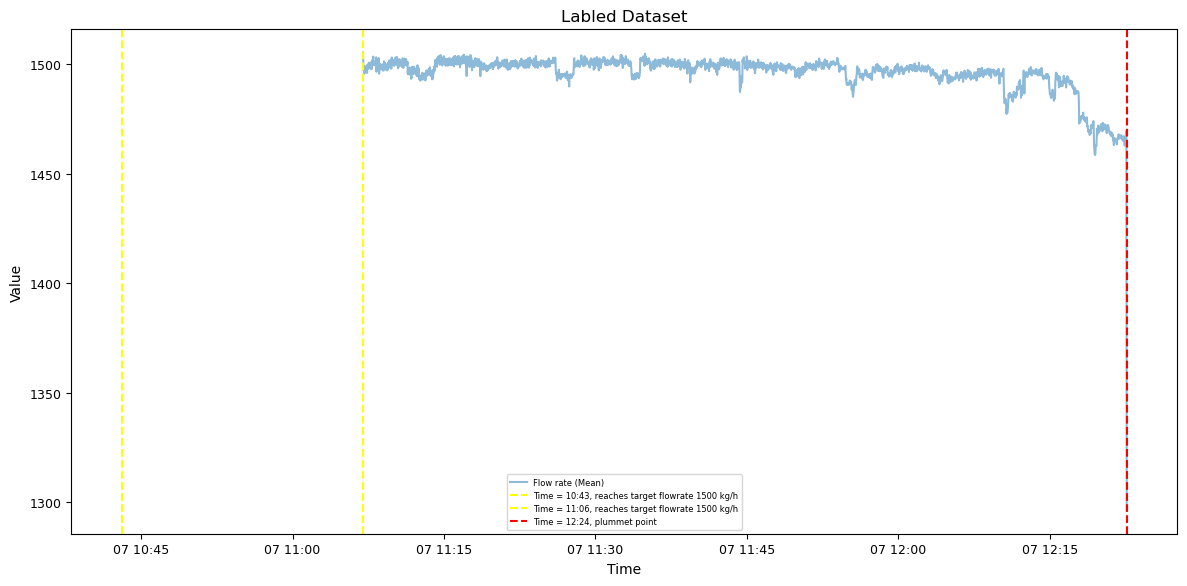

In [113]:
dv.visualize_plug_event(dataset17, plug_column="Plug", name="Labled Dataset", extra_id=17)

# Dataset 18

Reconstructed the time column based on time sampling being 20hz, meaning a sample every 0.05 seconds, since the timestamp only provides a date.
This is done to enable visualization of the dataset.

Further examination of if this reconstruction was correct was not pursued as dataset 18 was not a part of the final dataset set used. 

In [114]:
show_info(dataset18)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 3
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
2022-11-03 14:06:00.000,-5.903935,-6.084833,25.778250,-6.030487,0.320851,0.457392,0.527352,1266.091633
2022-11-03 14:06:00.500,-5.879389,-6.059764,25.781270,-5.985469,0.320661,0.457439,0.527673,1265.290115
2022-11-03 14:06:01.000,-5.878995,-6.081158,25.784158,-6.040331,0.320803,0.456578,0.526598,1263.880387
2022-11-03 14:06:01.500,-5.868363,-6.078008,25.772737,-6.035868,0.321055,0.457754,0.527563,1263.861528
2022-11-03 14:06:02.000,-5.853530,-6.033644,25.771687,-5.994525,0.320714,0.457481,0.527600,1265.011941


In [115]:
set_no_plug(dataset18)

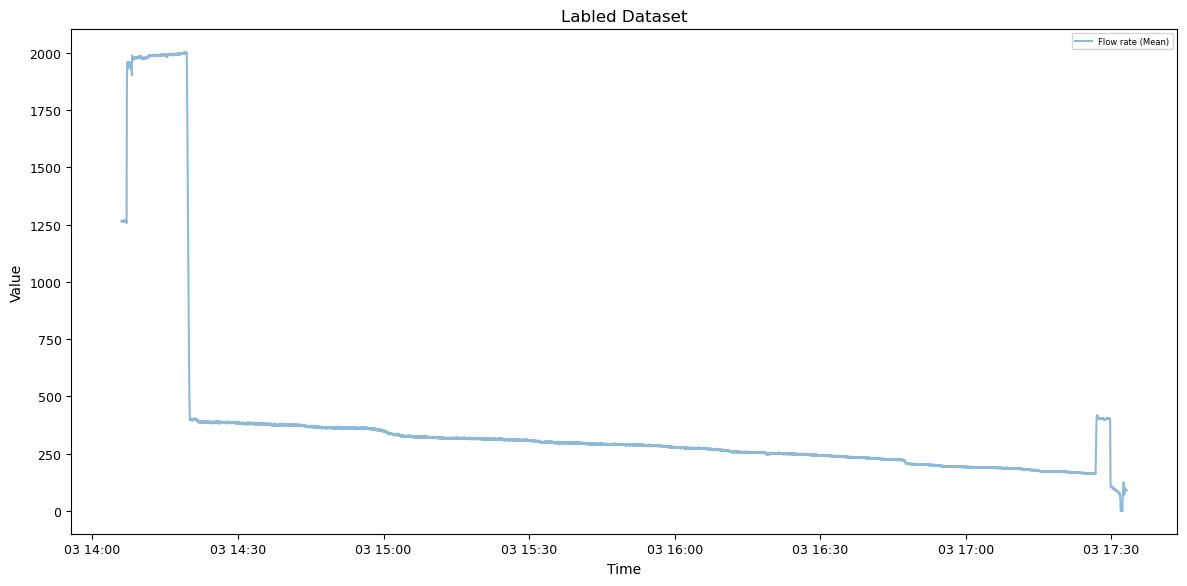

In [116]:
dv.visualize_plug_event(dataset18, plug_column="Plug", name="Labled Dataset")

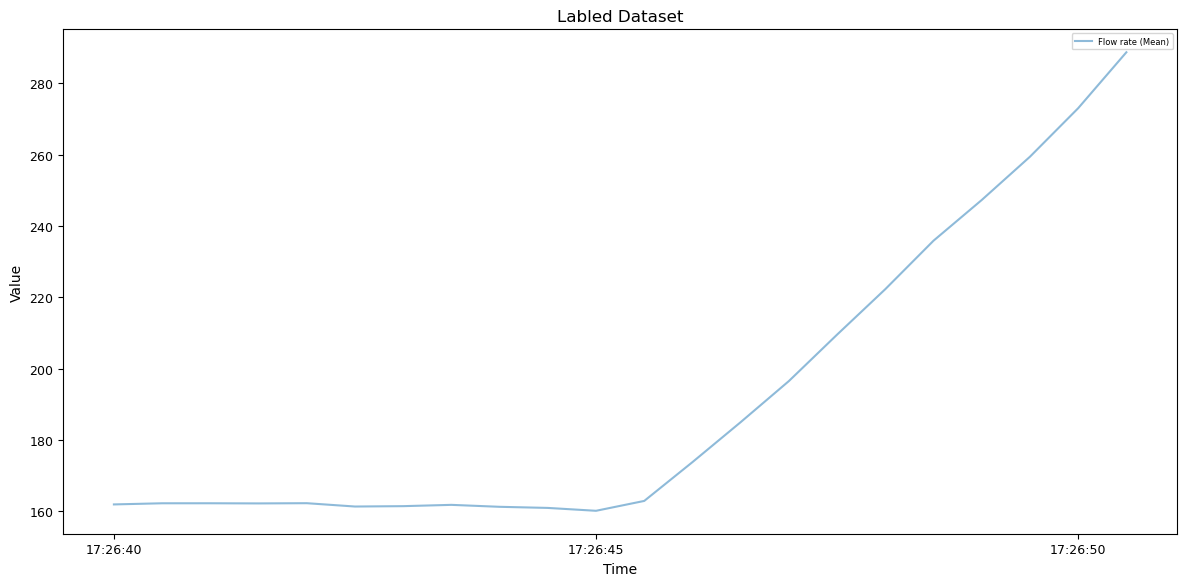

In [117]:
dv.visualize_plug_event(dataset18.loc["2022-11-03 17:26:40": "2022-11-03 17:26:50"], plug_column="Plug", name="Labled Dataset")

In [118]:
dataset18.loc["2022-11-03 17:26:40": "2022-11-03 17:26:50"]

,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean),Plug
Time,,,,,,,,,
2022-11-03 17:26:40.000,2.177044,1.807356,24.235920,-2.085535,0.089089,0.098746,0.149360,161.944818,0
2022-11-03 17:26:40.500,2.182951,1.832557,24.231850,-2.051017,0.090029,0.098962,0.149966,162.265425,0
2022-11-03 17:26:41.000,2.175075,1.800925,24.238152,-2.070179,0.088999,0.098888,0.149102,162.270140,0
2022-11-03 17:26:41.500,2.173763,1.798431,24.235132,-2.092885,0.090155,0.099356,0.149562,162.227707,0
2022-11-03 17:26:42.000,2.190302,1.835838,24.236970,-2.045110,0.089740,0.098626,0.149047,162.288999,0
2022-11-03 17:26:42.500,2.190564,1.848439,24.234738,-2.028967,0.090753,0.099424,0.149635,161.355467,0
2022-11-03 17:26:43.000,2.188333,1.829669,24.237364,-2.049967,0.089719,0.098563,0.148781,161.459193,0
2022-11-03 17:26:43.500,2.172187,1.779005,24.234738,-2.106404,0.089929,0.098820,0.148845,161.822233,0
2022-11-03 17:26:44.000,2.176388,1.807487,24.230800,-2.089473,0.089535,0.098762,0.148349,161.275315,0


In [119]:
# Find first stabilization point, target flowrate 400 kg/h
first_400 = dataset18[
    (dataset18["Flow rate (Mean)"] >= 395) &
    (dataset18["Flow rate (Mean)"] <= 405)
].index[0]

print(first_400)
dataset18 = dataset18.loc[first_400:]

2022-11-03 14:20:05


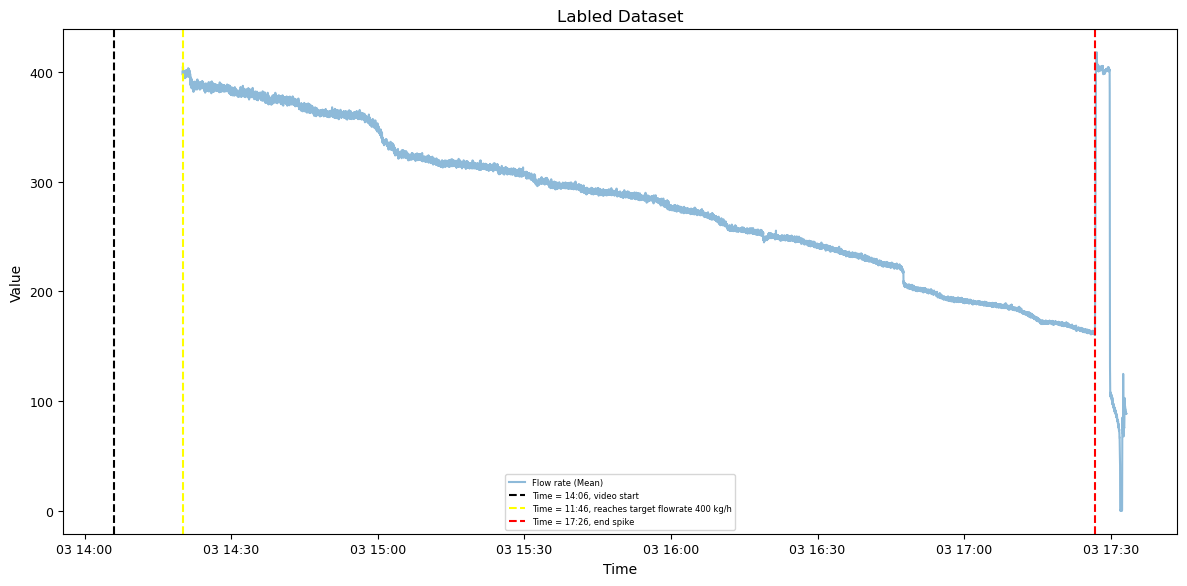

In [120]:
dv.visualize_plug_event(dataset18, plug_column="Plug", name="Labled Dataset", extra_id=18)

In [121]:
dataset18[
    (dataset18["Flow rate (Mean)"] >= 170) &
    (dataset18["Flow rate (Mean)"] <= 180)
]

,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean),Plug
Time,,,,,,,,,
2022-11-03 17:12:04.000,2.161424,2.043876,24.052400,-1.858212,0.088228,0.099802,0.149176,179.879949,0
2022-11-03 17:12:05.000,2.163524,2.090865,24.054500,-1.809387,0.088884,0.099403,0.149259,179.516909,0
2022-11-03 17:12:14.000,2.162605,2.047026,24.049512,-1.805187,0.088028,0.099366,0.148808,179.714931,0
2022-11-03 17:12:16.500,2.168381,2.031276,24.044130,-1.836162,0.087976,0.098725,0.148845,179.573486,0
2022-11-03 17:12:21.000,2.172450,2.049258,24.032184,-1.817656,0.087230,0.098683,0.148854,179.634779,0
...,...,...,...,...,...,...,...,...,...
2022-11-03 17:21:13.500,2.064028,1.761548,24.219117,-1.963999,0.089015,0.100196,0.150912,170.181588,0
2022-11-03 17:21:14.000,2.062847,1.772180,24.216754,-1.965836,0.088222,0.098536,0.148147,171.001965,0
2022-11-03 17:21:23.500,2.069804,1.790687,24.213472,-1.953105,0.089246,0.099828,0.150719,170.313603,0


In [122]:
end_spike = "2022-11-03 17:26:46.000"
dataset18 = dataset18.loc[:end_spike]

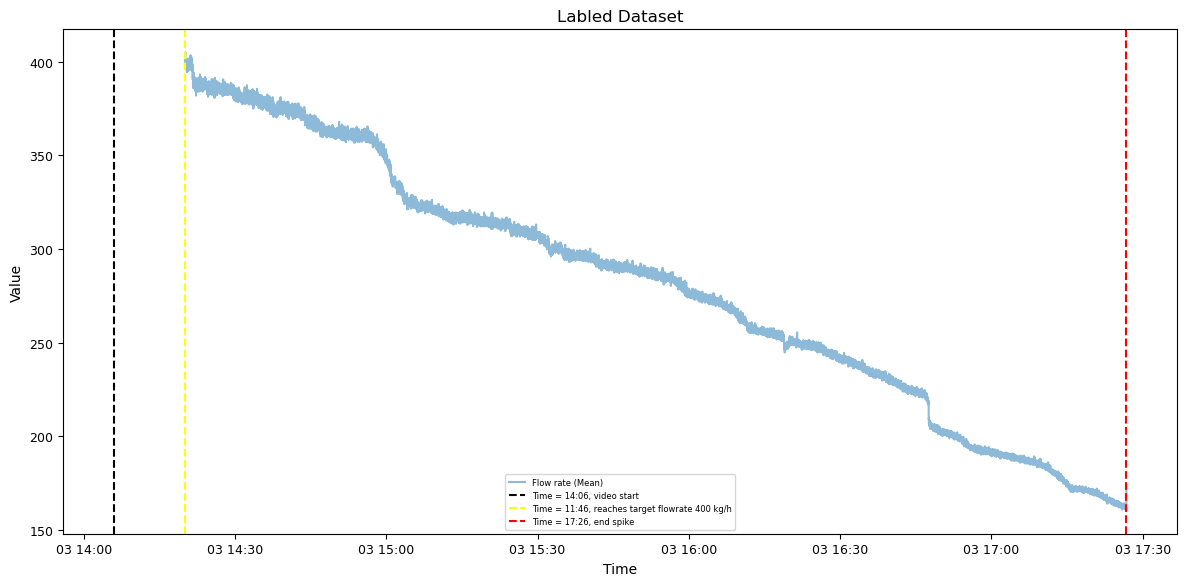

In [123]:
dv.visualize_plug_event(dataset18, plug_column="Plug", name="Labled Dataset", extra_id=18)

# Dataset 19
The result of the test: Partial blockage during the test (1500 -> 1200 kg/h), then full blockage (1200 -> 500 -> 0 kg/h). The blockage of the test section



In [124]:
show_info(dataset19)

Dataset columns: ['TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
TS inlet pressure (Mean)           float64
Pump outlet pressure (Mean)        float64
Differential pressure (Mean)       float64
Flow rate (Mean)                   float64
Tank temperature (Mean)            float64
Temperature TS inlet (Mean)        float64
Temperature TS outlet (Mean)       float64
Bypass temperature (Mean)          float64
Temperature TS outlet (Std Dev)    float64
Temperature TS inlet (Std Dev)     float64
Bypass 

,TS inlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
2021-12-11 11:42:28.036,0.645331,0.993827,1.102425,1997.612909,-6.454473,-6.336605,-6.302838,24.558803,0.174138,0.184673,0.176160,0.747064,0.180930,0.019371,0.020451,8.499998
2021-12-11 11:42:28.186,0.654391,0.998200,1.099002,1996.586745,-6.433421,-6.352767,-6.296713,24.551545,0.200224,0.212430,0.184365,0.847224,0.184619,0.023051,0.023298,9.360806
2021-12-11 11:42:28.284,0.648390,0.996805,1.099284,1995.871505,-6.422225,-6.355303,-6.317571,24.547115,0.180322,0.204341,0.177747,0.873907,0.181793,0.022466,0.027068,8.948124
2021-12-11 11:42:28.385,0.653351,1.002438,1.102732,1995.626667,-6.420660,-6.343740,-6.287243,24.567341,0.210958,0.224363,0.180844,0.874649,0.172978,0.037186,0.035184,11.113790
2021-12-11 11:42:28.484,0.649936,0.995998,1.096682,1996.248612,-6.447766,-6.386283,-6.314771,24.514656,0.184075,0.174477,0.175234,0.826061,0.177204,0.020697,0.024504,10.054284


In [125]:
#Set plug based on description
if 'Plug' not in dataset19.columns:
    dataset19['Plug'] = 0  
dataset19['Plug'] = np.where((dataset19["Flow rate (Mean)"] < 1200), 1, dataset19['Plug'])

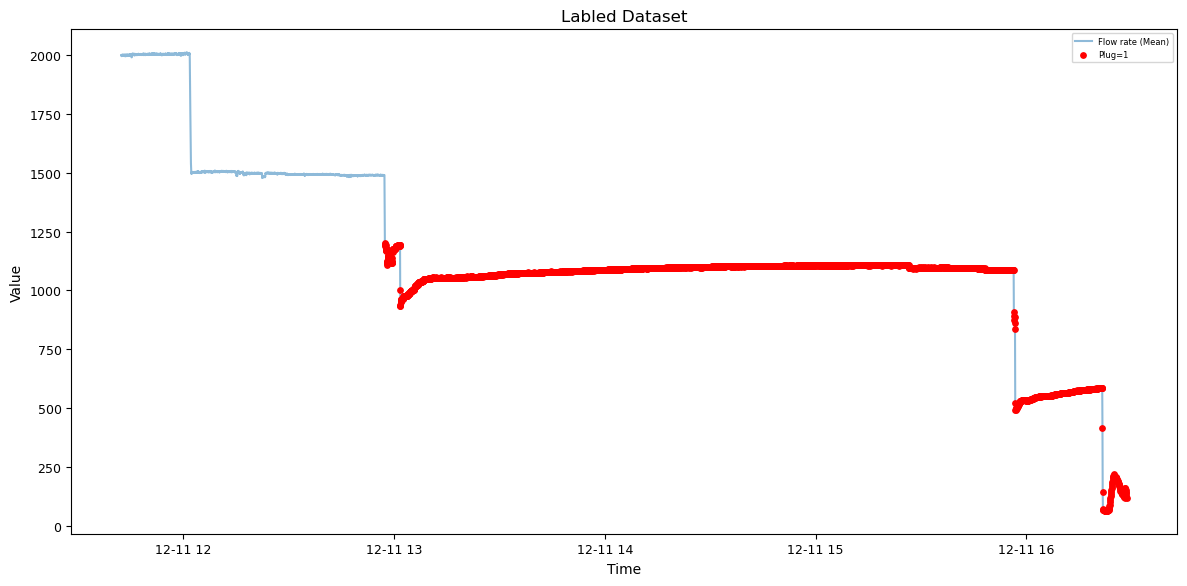

In [126]:
dv.visualize_plug_event(dataset19, plug_column="Plug", name="Labled Dataset")

# Dataset 20

14:36:10 – 14:39:59 – loop blocked (4.5 Hz)

14:52:49 - 15:05:17 – orifice blocked (5 Hz)

15:20:58 - 15:34:45 – loop blocked (5.5 Hz)

In [127]:
show_info(dataset20)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 14:03:35.269,23.113373,2.418214,23.059317,-14.946758,0.131260,0.386811,0.491457,1.103847
1900-01-01 14:03:36.269,23.113767,1.926929,23.064962,-14.741091,0.131275,0.387535,0.492945,1.240577
1900-01-01 14:03:37.269,23.103791,1.527916,23.050915,-14.520461,0.131480,0.389346,0.494516,1.014266
1900-01-01 14:03:38.269,23.109173,1.215399,23.054854,-14.290119,0.131559,0.388737,0.493956,0.835103
1900-01-01 14:03:39.269,23.112980,0.958535,23.060367,-14.090752,0.131233,0.388239,0.492330,0.811529


In [128]:
set_plug_at_time(dataset20, '14:36:10', '14:39:59')
set_plug_at_time(dataset20, '14:52:49', '15:05:17')
set_plug_at_time(dataset20, '15:20:58', '15:34:45')

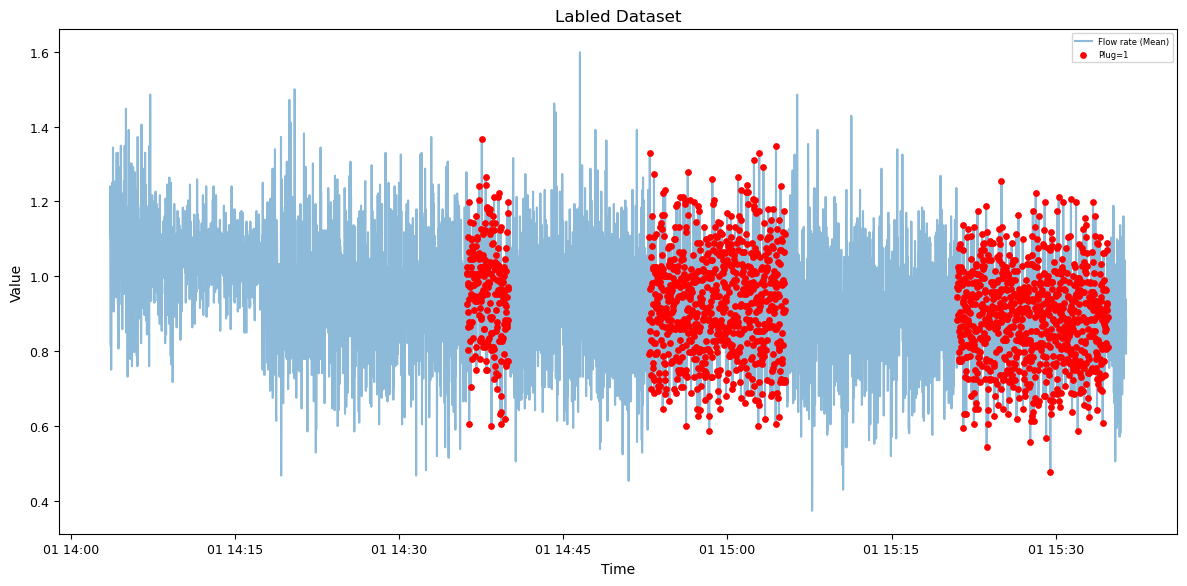

In [129]:
dv.visualize_plug_event(dataset20, plug_column="Plug", name="Labled Dataset")

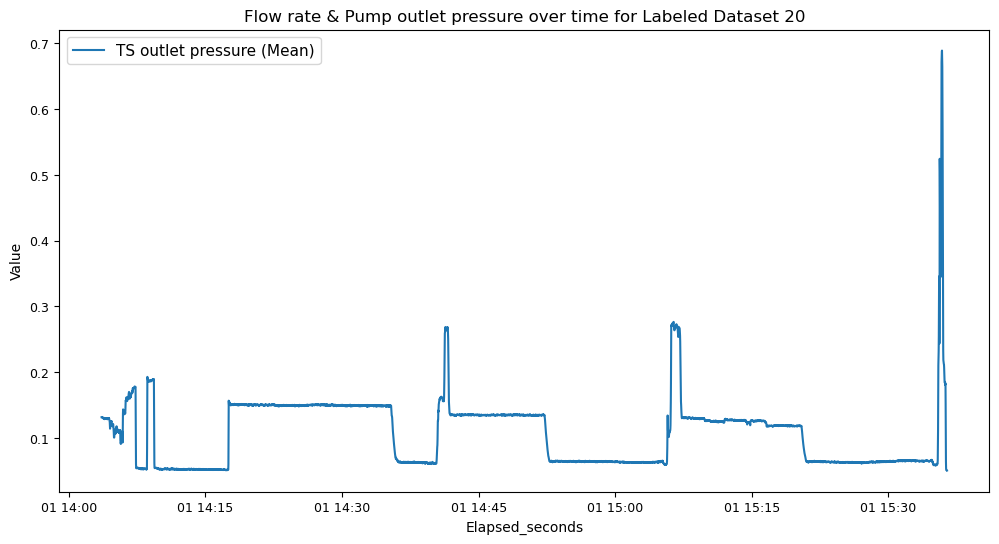

In [130]:
dv.visualize_key_column(dataset20, key="TS outlet pressure (Mean)", name="Labeled Dataset 20")

# Dataset 21

Time codes:

13:11:01 - 13:16:39 loop blocked

13:23:53 - 13:31:01 orifice blocked

13:45:42 - 14:06:44 loop blocked

14:13:36 - 14:36:09 loop blocked

In [131]:
show_info(dataset21)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 12:53:07.659,21.091422,-8.236616,21.668344,-8.412000,0.392833,0.673924,0.990813,0.717233
1900-01-01 12:53:08.659,21.104680,-8.220866,21.676090,-8.400844,0.393705,0.673924,0.990372,1.141566
1900-01-01 12:53:09.659,21.096410,-8.209840,21.678452,-8.386276,0.393327,0.673719,0.990400,1.132136
1900-01-01 12:53:10.659,21.098511,-8.196977,21.681209,-8.374201,0.396382,0.677405,0.992981,1.254721
1900-01-01 12:53:11.659,21.148915,-8.168758,21.694468,-8.348082,0.394560,0.675547,0.992292,0.853963


In [132]:
set_plug_at_time(dataset21, '13:11:01', '13:16:39')
set_plug_at_time(dataset21, '13:23:53', '13:31:01')
set_plug_at_time(dataset21, '13:45:42', '14:06:44')
set_plug_at_time(dataset21, '14:13:36', '14:36:09')

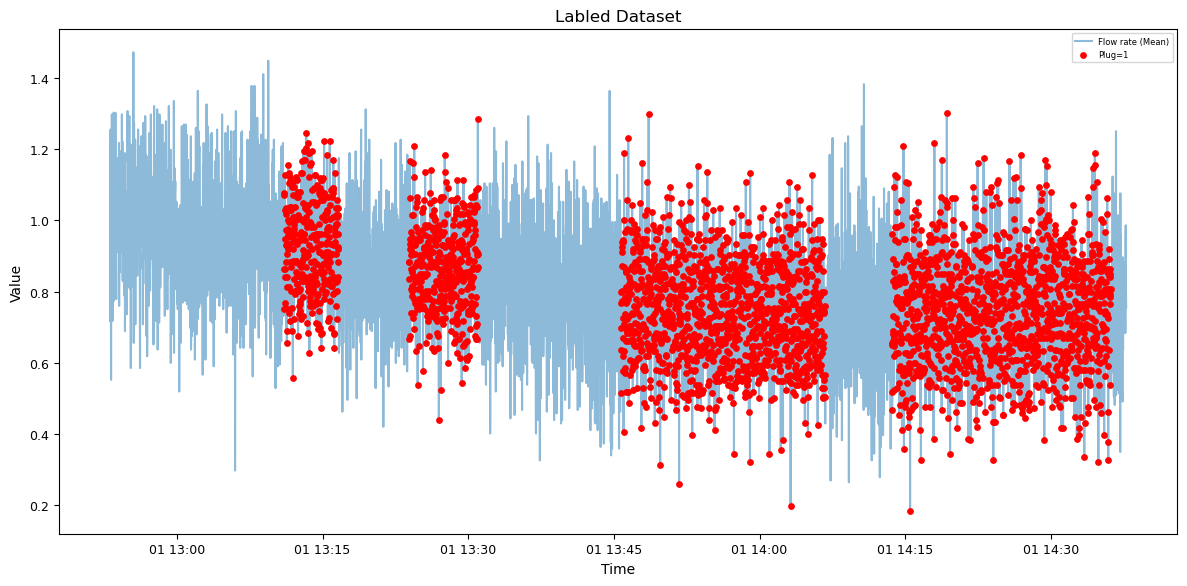

In [133]:
dv.visualize_plug_event(dataset21, plug_column="Plug", name="Labled Dataset")

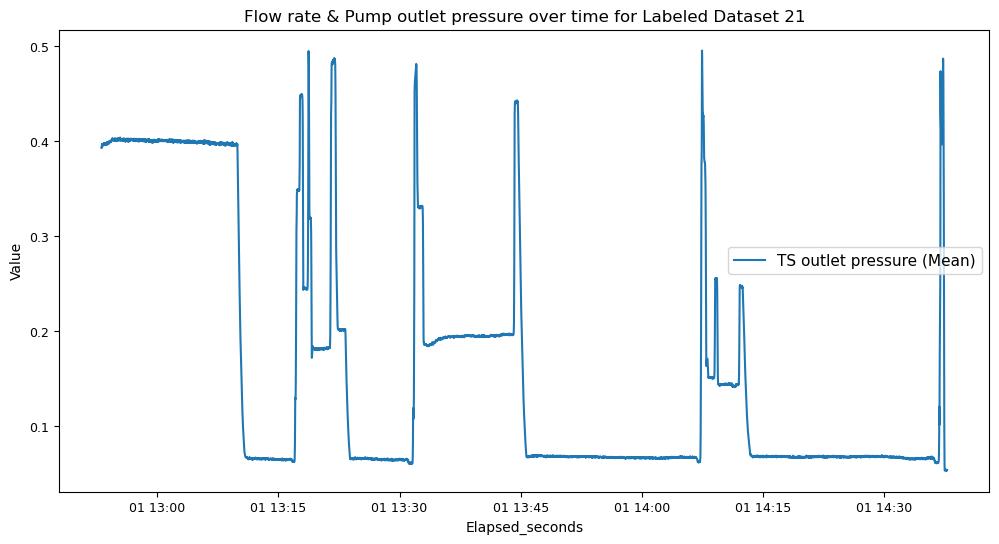

In [134]:
dv.visualize_key_column(dataset21, key="TS outlet pressure (Mean)", name="Labeled Dataset 21")

# Dataset 22
The test result: video started at 12:46:20. Loop blockage. Sedimentation at the top of the glass pipe, then covers the entire surface of the glass pipe. 


Reconstructed the time column based on time sampling being 20hz, meaning a sample every 0.05 seconds, since the timestamp only provides a date.
This is done to enable visualization of the dataset.
NB! the reconstructed time doesn´t comply with the description of the dataset, which states a 7.6% concentration changing at timestamp 13:04 which doesn´t exist with the reconstructed timeframe.

This issue was not explored further as this was not one of the datasets included in the final dataset set. 

In [135]:
show_info(dataset22)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
2022-03-15 12:46:20.000,-5.526164,-5.578060,24.612937,-5.684383,0.650201,0.994709,1.111414,2002.341954
2022-03-15 12:46:20.500,-5.452789,-5.513615,24.586157,-5.642384,0.649503,0.993024,1.110633,2002.577695
2022-03-15 12:46:21.000,-5.457908,-5.523984,24.603748,-5.639234,0.651461,0.997712,1.114639,2001.568726
2022-03-15 12:46:21.500,-5.495318,-5.548791,24.588126,-5.686483,0.650789,0.995328,1.113399,2003.162331
2022-03-15 12:46:22.000,-5.508575,-5.554041,24.590752,-5.672177,0.650810,0.993433,1.111010,2004.364607


In [136]:
#find end timestamp
end = dataset22.index.max().strftime('%H:%M:%S')
print(f"End timestamp of dataset22: {end}")
set_plug_at_time(dataset22, '13:04:00', end, custom_date="2022-03-15")

End timestamp of dataset22: 13:50:55


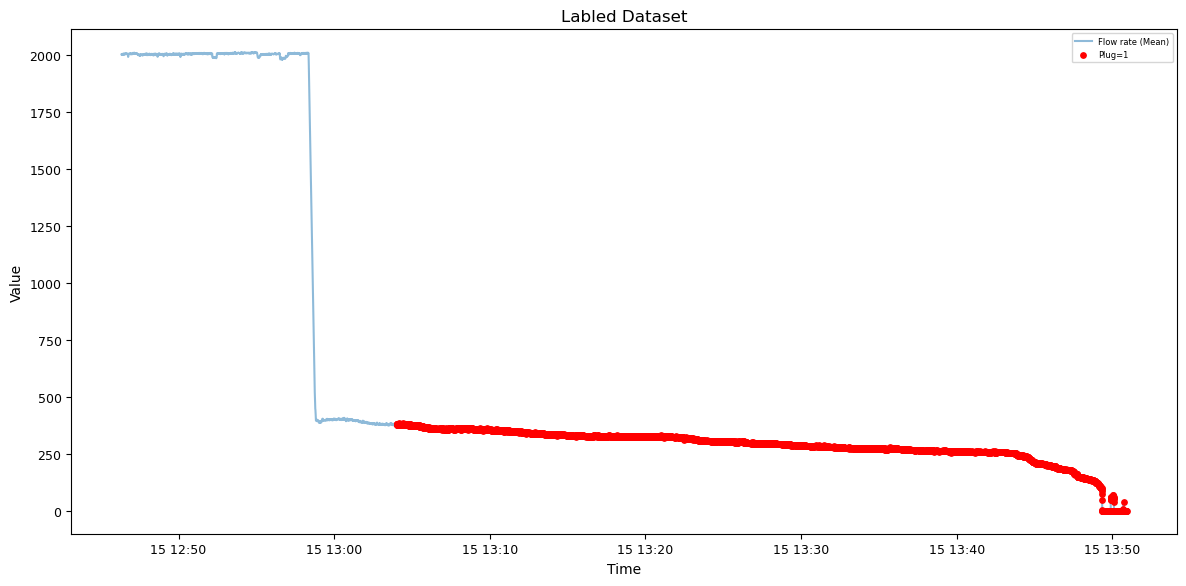

In [137]:
dv.visualize_plug_event(dataset22, plug_column="Plug", name="Labled Dataset")

# Dataset 23

13:40:14 – 13:50:30 - loop blockage


In [138]:
show_info(dataset23)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:14:36.498,22.397605,23.126729,22.143160,22.241733,-0.000603,-0.000093,0.032626,1.051984
1900-01-01 13:14:37.498,22.397999,23.068189,22.143816,22.237533,-0.000609,-0.000014,0.032488,1.146281
1900-01-01 13:14:38.498,22.396161,23.059526,22.143029,22.231758,-0.000157,0.000343,0.032745,1.320729
1900-01-01 13:14:39.498,22.394980,23.102709,22.141454,22.230446,-0.000393,0.000301,0.032681,1.169855
1900-01-01 13:14:40.498,22.401149,23.121216,22.138697,22.236615,-0.000614,0.000096,0.032286,1.150995


In [139]:
set_plug_at_time(dataset23, '13:40:14', '13:50:30')

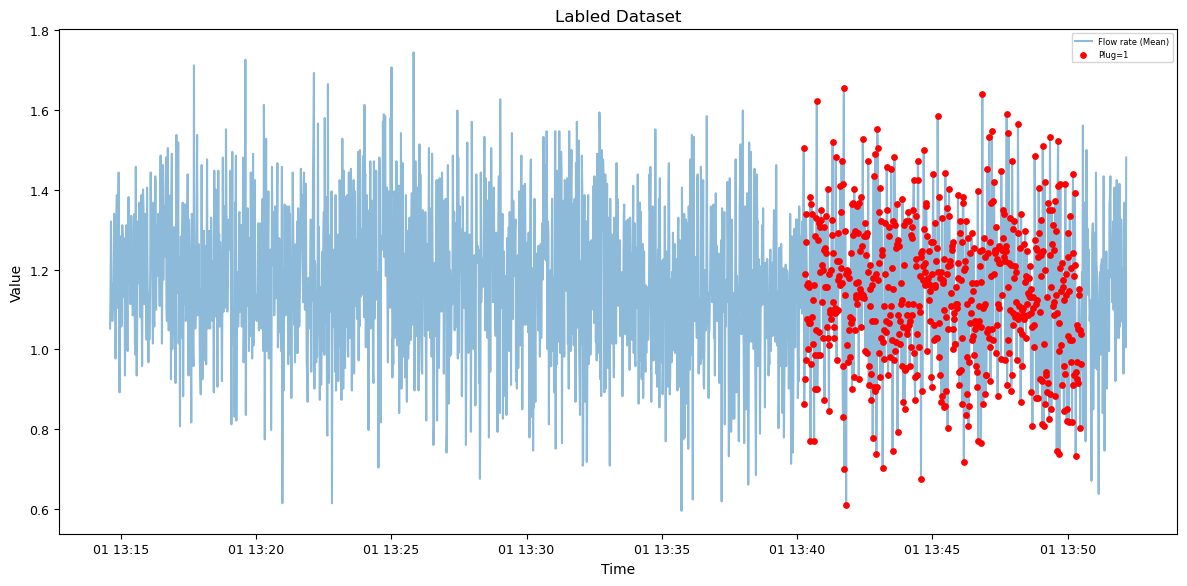

In [140]:
dv.visualize_plug_event(dataset23, plug_column="Plug", name="Labled Dataset")

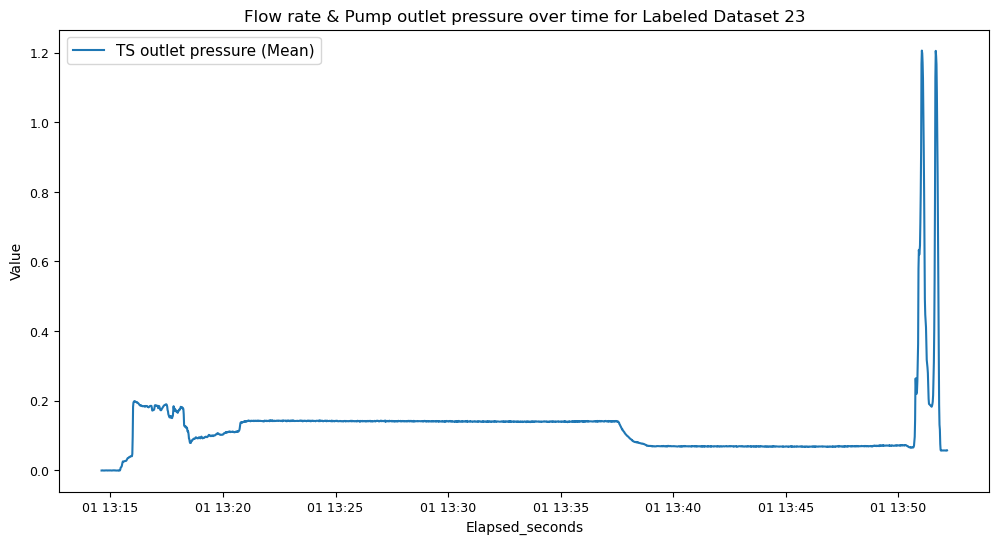

In [141]:
dv.visualize_key_column(dataset23, key="TS outlet pressure (Mean)", name="Labeled Dataset 23")

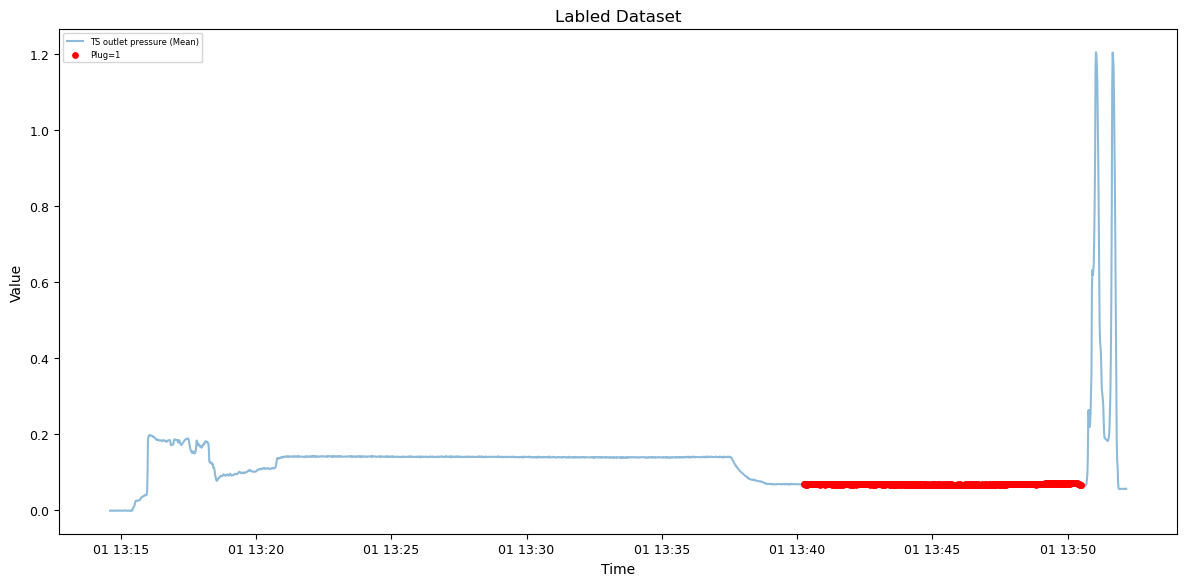

In [142]:
dv.visualize_plug_event(dataset23, plug_column="Plug", key="TS outlet pressure (Mean)", name="Labled Dataset")

# Dataset 24

In [143]:
show_info(dataset24)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:44:02.474,-5.801682,-5.979699,27.357731,-5.379098,0.666509,1.006186,1.127667,1979.130953
1900-01-01 13:44:03.474,-5.781993,-5.948854,27.350774,-5.360986,0.666650,1.006412,1.126739,1981.045165
1900-01-01 13:44:04.474,-5.777399,-5.936516,27.348148,-5.150725,0.666346,1.007273,1.127841,1982.770785
1900-01-01 13:44:05.474,-5.769260,-5.947410,27.353137,-5.214381,0.665821,1.006339,1.127758,1983.991920
1900-01-01 13:44:06.474,-5.756528,-5.933497,27.350511,-5.261105,0.666393,1.005845,1.127777,1984.048498


In [144]:
set_no_plug(dataset24)

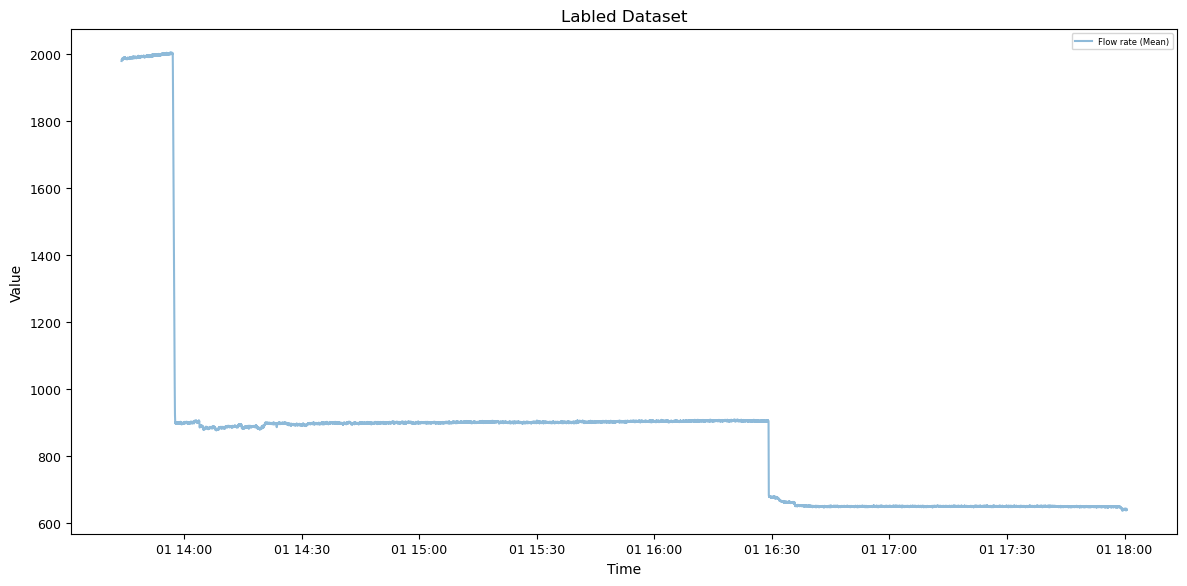

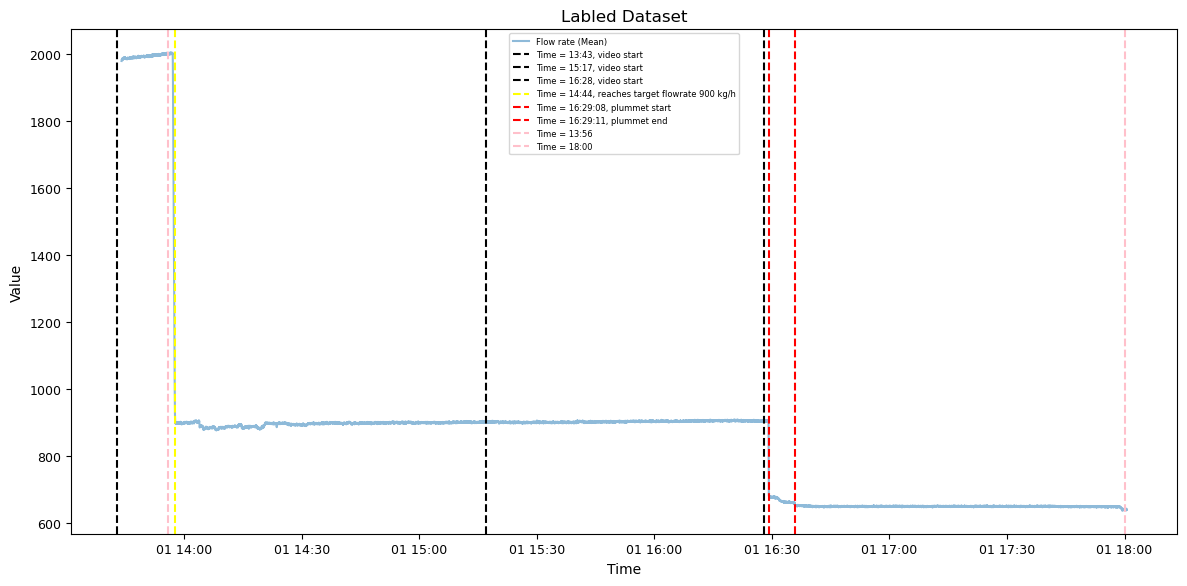

In [145]:
dv.visualize_plug_event(dataset24, plug_column="Plug", name="Labled Dataset")
dv.visualize_plug_event(dataset24, plug_column="Plug", name="Labled Dataset", extra_id=24)

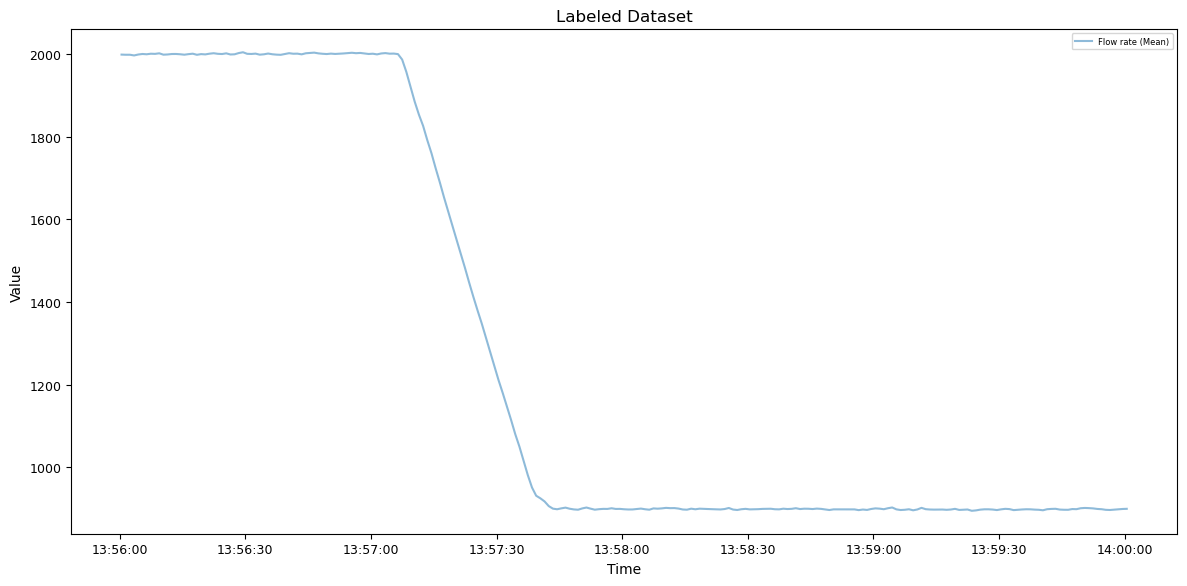

In [146]:
dv.visualize_plug_event(dataset24.loc["1900-01-01 13:56:00":"1900-01-01 14:00:00"], plug_column="Plug", name="Labeled Dataset")

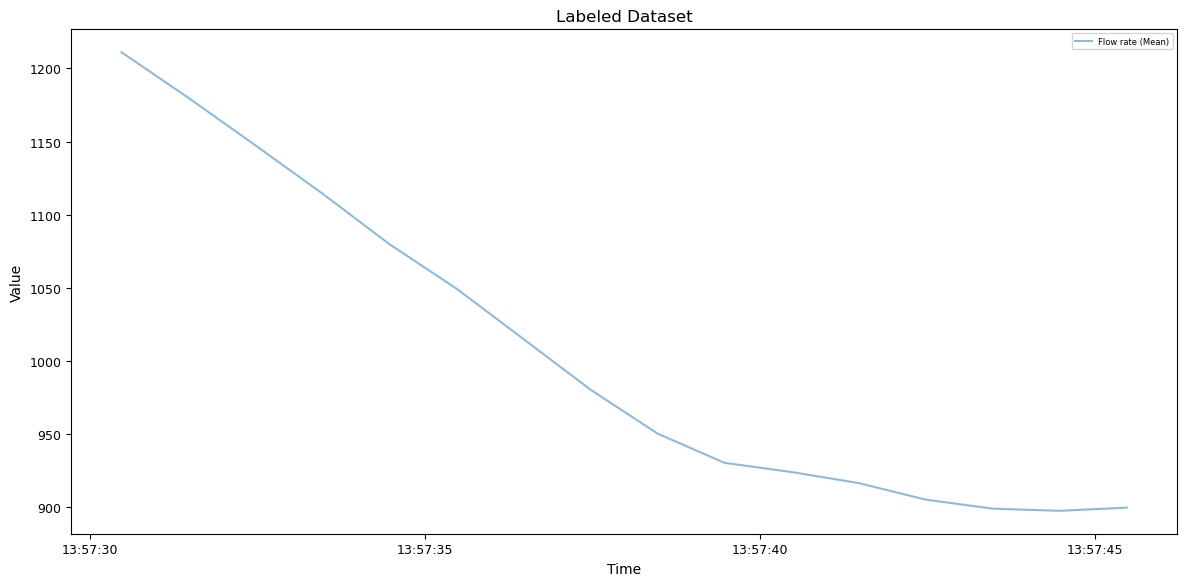

In [147]:
dv.visualize_plug_event(dataset24.loc["1900-01-01 13:57:30":"1900-01-01 13:57:45"], plug_column="Plug", name="Labeled Dataset")

In [148]:
dataset24.loc["1900-01-01 13:57:30":"1900-01-01 13:57:45"]

,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean),Plug
Time,,,,,,,,,
1900-01-01 13:57:30.474,-1.809497,-1.889290,26.361498,-1.191861,0.300264,0.418660,0.488195,1211.013242,0
1900-01-01 13:57:31.474,-1.793089,-1.893752,26.365830,-1.319303,0.288041,0.400572,0.468691,1179.820070,0
1900-01-01 13:57:32.474,-1.807528,-1.902284,26.368062,-1.147761,0.277083,0.383440,0.450454,1147.325611,0
1900-01-01 13:57:33.474,-1.795846,-1.899659,26.369506,-1.180442,0.266829,0.366901,0.430114,1114.378531,0
1900-01-01 13:57:34.474,-1.798208,-1.880233,26.364255,-1.316022,0.255956,0.352016,0.413365,1079.814271,0
1900-01-01 13:57:35.474,-1.801359,-1.884827,26.376069,-1.278091,0.245056,0.336333,0.395652,1049.450905,0
1900-01-01 13:57:36.474,-1.803065,-1.896246,26.376594,-1.318122,0.234776,0.319532,0.377774,1014.999801,0
1900-01-01 13:57:37.474,-1.805821,-1.890734,26.374232,-1.278485,0.226549,0.305802,0.362808,980.444971,0
1900-01-01 13:57:38.474,-1.787182,-1.879052,26.378038,-1.315366,0.220537,0.298430,0.353951,950.435216,0


1900-01-01 13:57:42.474000


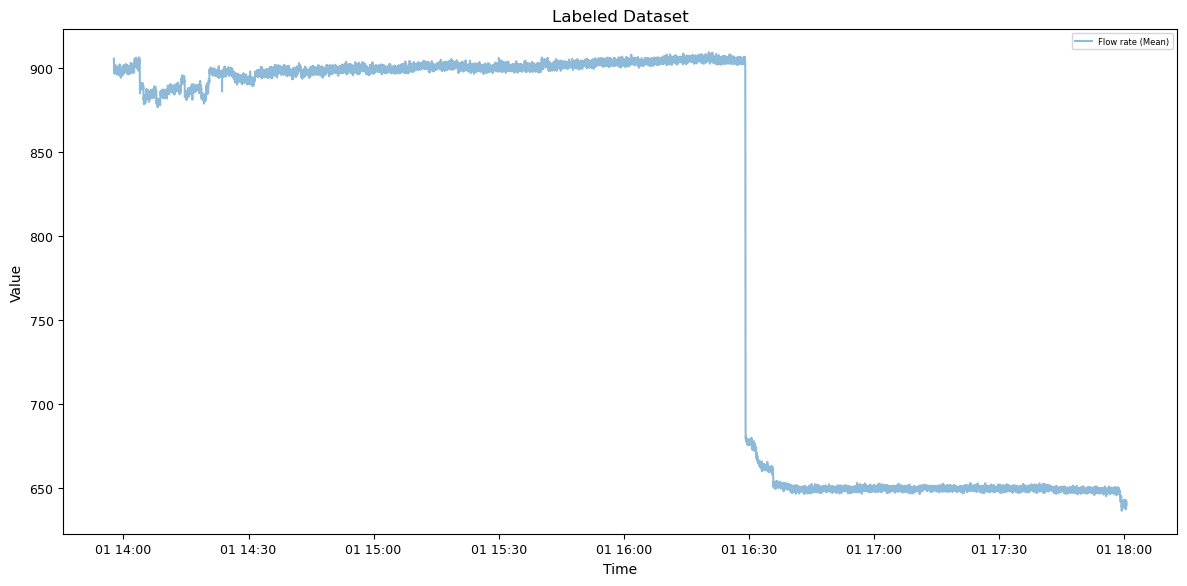

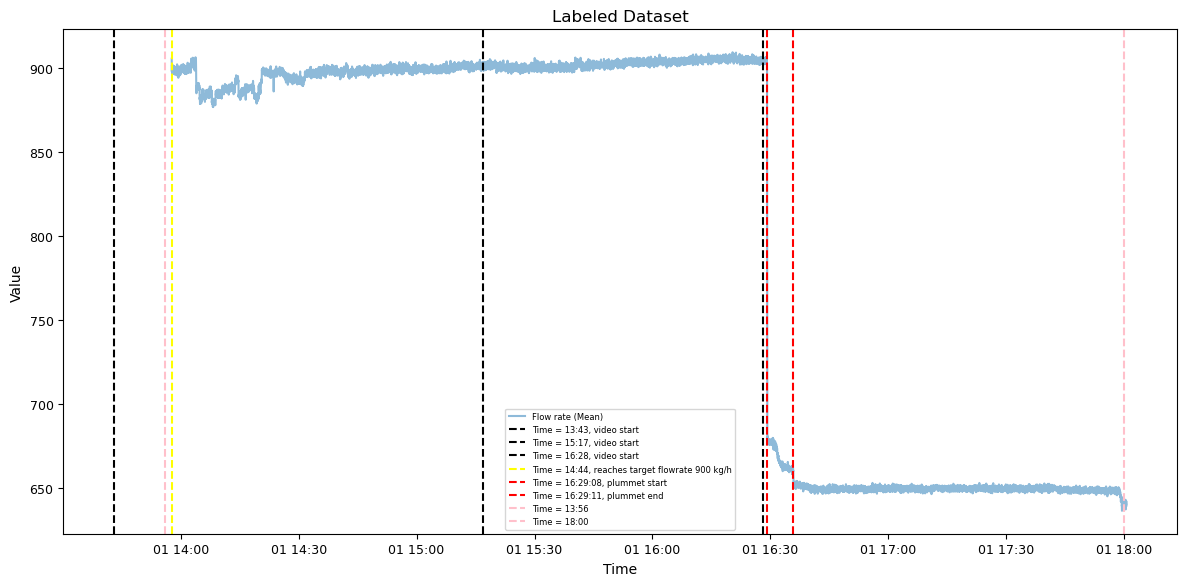

In [149]:
# Find first stabilization point, target flowrate 900 kg/h
first_900 = dataset24[
    (dataset24["Flow rate (Mean)"] >= 895) &
    (dataset24["Flow rate (Mean)"] <= 906)
].index[0]
print(first_900)
dataset24 = dataset24.loc[first_900:]

dv.visualize_plug_event(dataset24, plug_column="Plug", name="Labeled Dataset")
dv.visualize_plug_event(dataset24, plug_column="Plug", name="Labeled Dataset", extra_id=24)

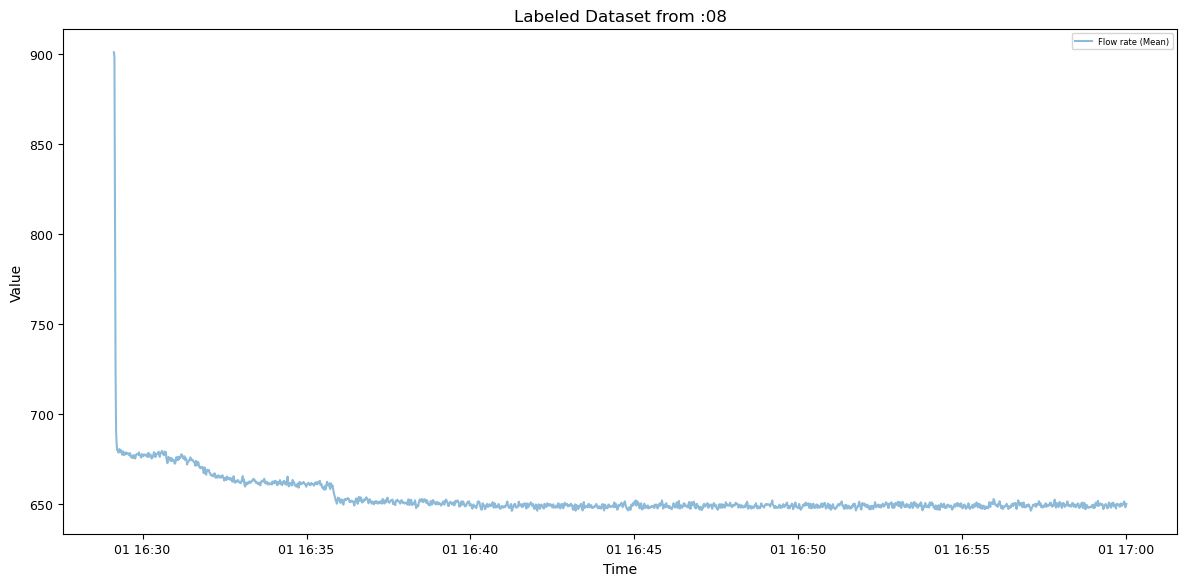

In [150]:
dv.visualize_plug_event(dataset24.loc["1900-01-01 16:29:07":"1900-01-01 17:00:00"], plug_column="Plug", name="Labeled Dataset from :08")

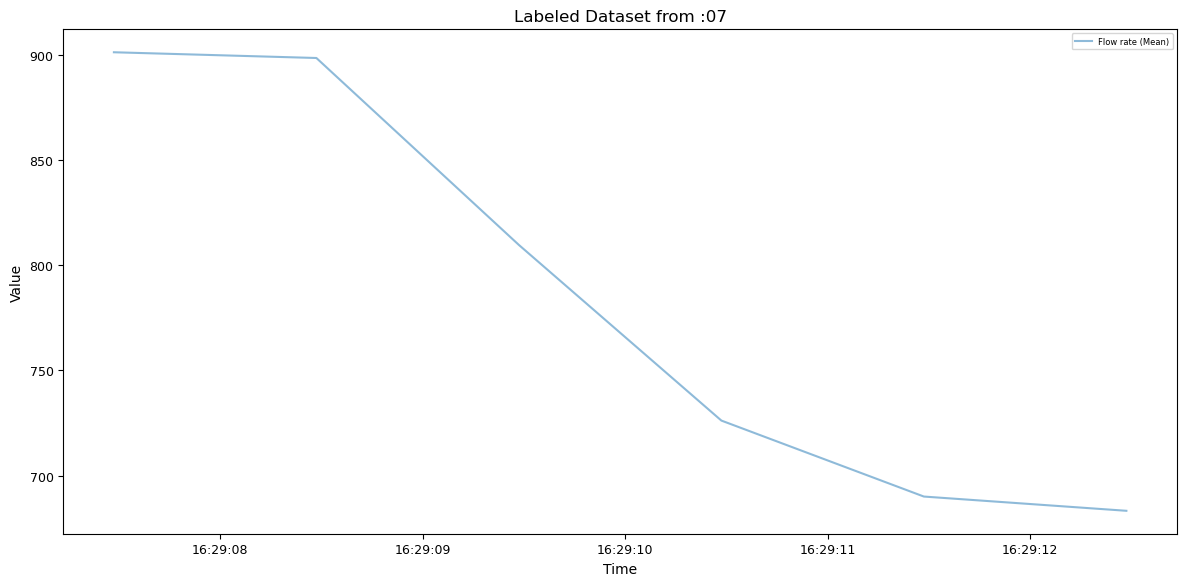

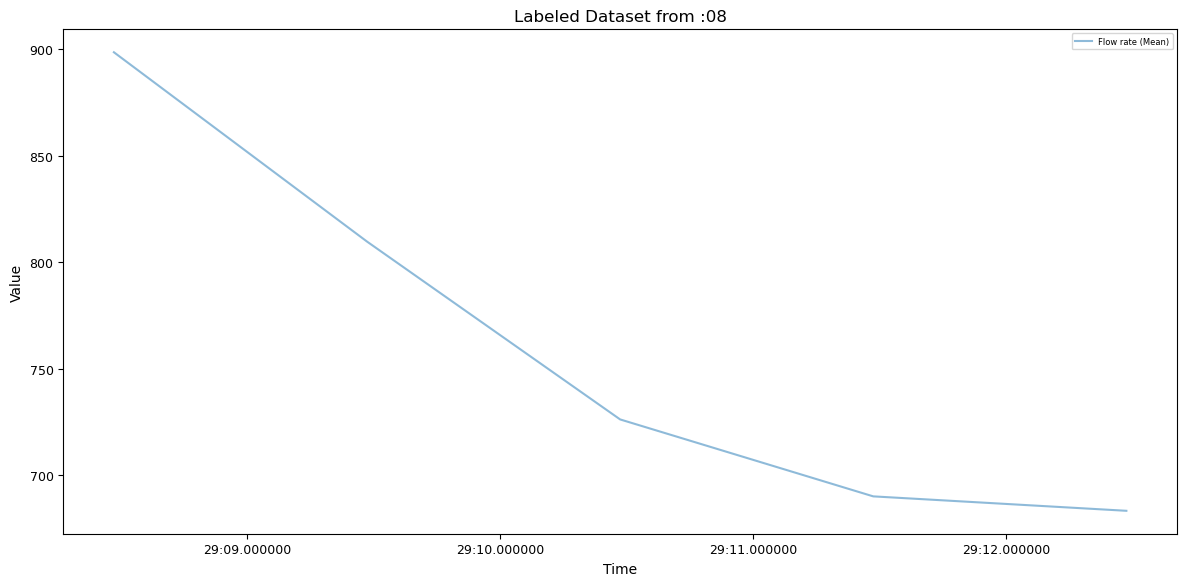

In [151]:
dv.visualize_plug_event(dataset24.loc["1900-01-01 16:29:07":"1900-01-01 16:29:12"], plug_column="Plug", name="Labeled Dataset from :07")
dv.visualize_plug_event(dataset24.loc["1900-01-01 16:29:08":"1900-01-01 16:29:12"], plug_column="Plug", name="Labeled Dataset from :08")

In [152]:
dataset24.loc["1900-01-01 16:29:05":"1900-01-01 16:29:12"]

,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean),Plug
Time,,,,,,,,,
1900-01-01 16:29:05.474,0.042339,-1.150853,25.896397,-1.309328,0.212283,0.282112,0.338847,904.857164,0
1900-01-01 16:29:06.474,0.026063,-1.133265,25.886945,-1.267854,0.212373,0.282826,0.338737,903.942491,0
1900-01-01 16:29:07.474,0.050871,-1.129327,25.893115,-1.259979,0.212415,0.283771,0.338654,901.160754,0
1900-01-01 16:29:08.474,0.048246,-1.140615,25.888783,-1.300535,0.217045,0.294666,0.339481,898.435595,0
1900-01-01 16:29:09.474,0.038402,-1.132478,25.899547,-1.288591,0.230119,0.298661,0.340188,809.636895,0
1900-01-01 16:29:10.474,0.034201,-1.141665,25.888258,-1.287804,0.240656,0.299701,0.341383,726.213077,0
1900-01-01 16:29:11.474,0.031182,-1.128934,25.890095,-1.398972,0.247860,0.299176,0.341144,690.125934,0
1900-01-01 16:29:12.474,0.032757,-1.133528,25.892721,-1.357759,0.251834,0.297921,0.341778,683.360184,0


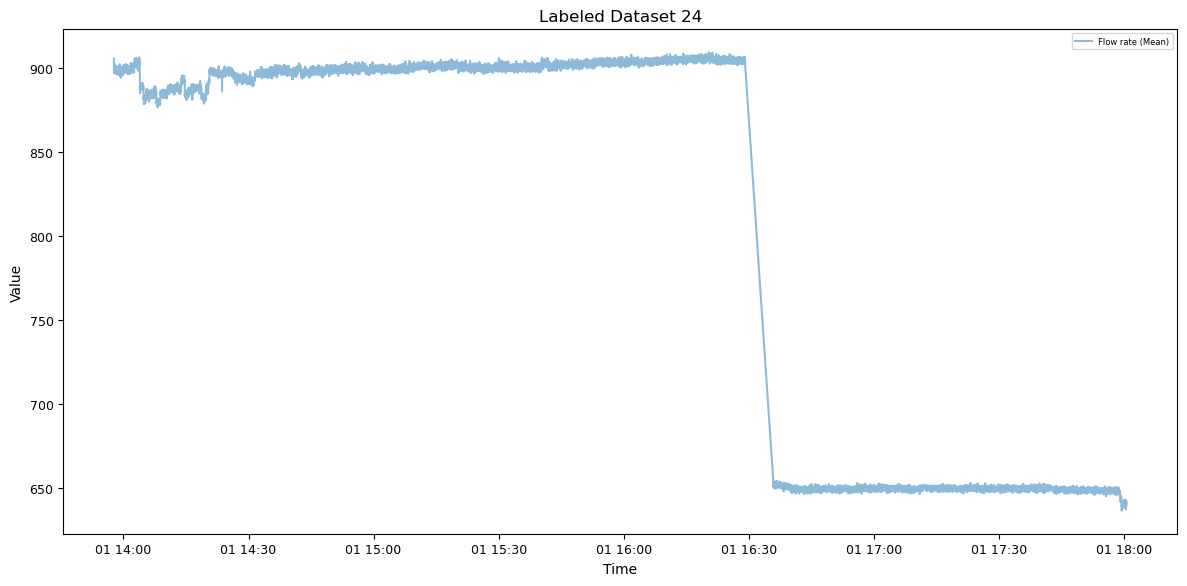

In [153]:
# Remove plummet section
plummet_start = pd.to_datetime("1900-01-01 16:29:08.474")
plummet_point = pd.to_datetime("1900-01-01 16:35:50.474")

dataset24 = dataset24[
    ~((dataset24.index >= plummet_start) & (dataset24.index <= plummet_point))
]

dv.visualize_plug_event(dataset24, plug_column="Plug", name="Labeled Dataset 24")

# Dataset 25

14:25:56  –– 14:53:52 blockage of the orifice

In [154]:
show_info(dataset25)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 8
Duplicate index timestamps: 8
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 14:00:53.654,22.477543,-6.878659,22.462023,-7.154766,0.181374,0.578041,0.730648,0.830388
1900-01-01 14:00:54.654,22.474655,-6.882334,22.461498,-7.148466,0.181689,0.579947,0.733055,1.212288
1900-01-01 14:00:55.654,22.470455,-6.879447,22.462942,-7.146104,0.181563,0.580330,0.733652,1.169855
1900-01-01 14:00:56.654,22.465861,-6.869603,22.461892,-7.120248,0.182015,0.583397,0.737676,1.349017
1900-01-01 14:00:57.654,22.480693,-6.853721,22.464649,-7.108435,0.182241,0.583701,0.737492,1.051984


In [155]:
set_plug_at_time(dataset25, '14:25:56', '14:53:52')

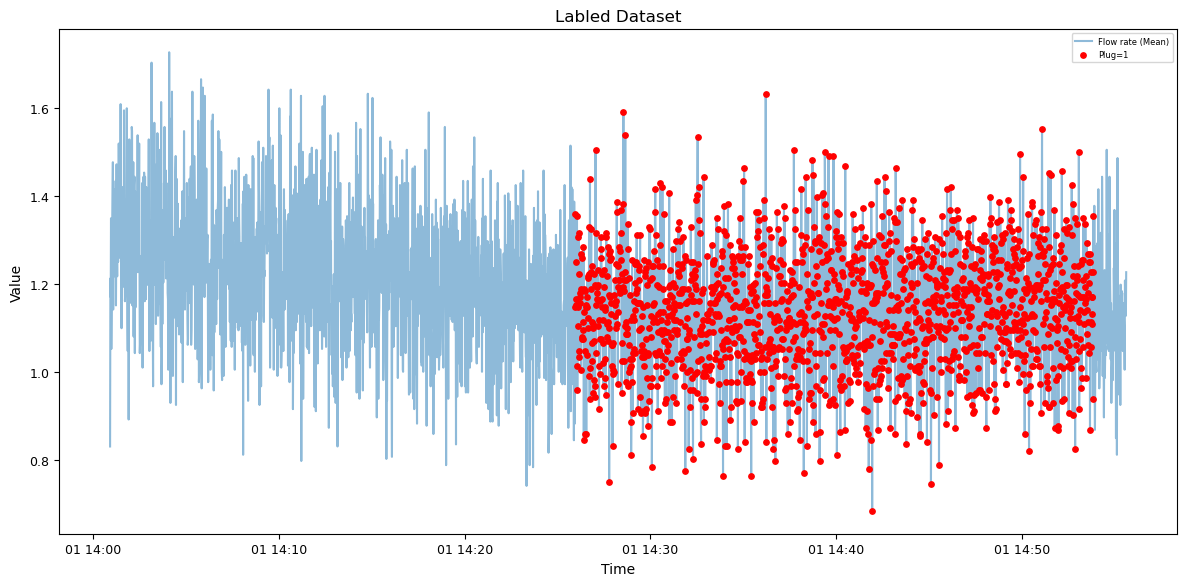

In [156]:
dv.visualize_plug_event(dataset25, plug_column="Plug", name="Labled Dataset")

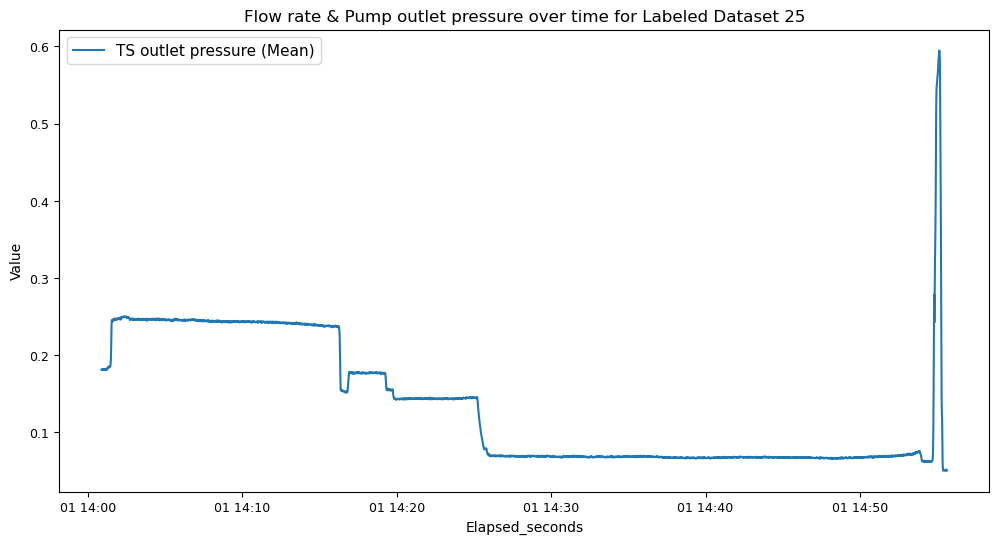

In [157]:
dv.visualize_key_column(dataset25, key="TS outlet pressure (Mean)", name="Labeled Dataset 25")

# Preprocessing all the datasets
This section preprocesses all the dataset to be structured as described in the thesis. 
The steps include:
- null values check
- time values check
- remove non-pressure features
- add logID 
- check data distribution

The datasets are then ready for use, and saved as new csv files.

In [158]:
data_list = [dataset1, dataset2, dataset3, dataset4, dataset5, dataset6, dataset7, dataset8, dataset9, dataset10, dataset11, dataset12, dataset13, dataset14, dataset15, dataset16, dataset17, dataset18, dataset19, dataset20, dataset21, dataset22, dataset23, dataset24, dataset25]

In [159]:
# print nan values info
if all(df.isna().sum().sum() == 0 for df in data_list):
    print("No NaN values found in any dataset. ✅")
else:
    print("NaN values found in some datasets. ❌")
    print("Number of NaN values in each column:")
    for i, df in enumerate(data_list, start=1):
        print(f"\nDataset {i} NaN values:")
        print(df.isna().sum())

No NaN values found in any dataset. ✅


In [160]:
bad_datasets = [
    (i, df) for i, df in enumerate(data_list)
    if df.index.isna().any()
]
print(f"Datasets with NaT in index: {len(bad_datasets)}")
for i, df in bad_datasets:
    print(f"Dataset {i} has {df.index.isna().sum()} NaT values in index. Length of dataset: {len(df)}")

Datasets with NaT in index: 0


### Remove non-pressure related features
Removing the non-pressure related features from the datasets as described in the thesis. 

In [161]:
# Remove non-pressure features from each dataset
for i in range(1, len(data_list)):
    print("📌 Before removal", data_list[i].columns.tolist())
    data_list[i] = keep_relevant_columns(data_list[i], dataset_name=f"data{i+1}")

# Reassign back to original names, dataset 18 and dataset 22 missing
(dataset1, dataset2, dataset3, dataset4, dataset5,
 dataset6, dataset7, dataset8, dataset9, dataset10,
 dataset11, dataset12, dataset13, dataset14, dataset15, 
 dataset16, dataset17, dataset18, dataset19, dataset20,
 dataset21, dataset22, dataset23, dataset24, dataset25) = data_list

📌 Before removal ['Flow rate (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Temperature TS outlet (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Plug']
⚠️  data2: dropping non-pressure columns: ['Flow rate (Mean)', 'Temperature TS outlet (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)']
📌 Before removal ['TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)', 'Plug']
⚠️  data3: dropping non-pressure columns: ['Flow rate

In [162]:
# Check how dataframe looks after keeping only relevant columns
dataset1.head(10)

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Plug
Time,,,,,,,,,
1900-01-01 09:13:23.564,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479,0
1900-01-01 09:13:23.614,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727,0
1900-01-01 09:13:23.664,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105,0
1900-01-01 09:13:23.714,2005.764905,0.662791,1.010171,1.127850,-6.255584,-6.370422,-6.324766,25.584228,0
1900-01-01 09:13:23.764,2005.576313,0.663421,1.014057,1.130607,-6.247708,-6.375672,-6.322141,25.589479,0
1900-01-01 09:13:23.814,2006.236386,0.664471,1.014687,1.132077,-6.313339,-6.415047,-6.382518,25.536970,0
1900-01-01 09:13:23.864,2005.199128,0.662266,1.012797,1.131342,-6.231957,-6.354672,-6.324766,25.573727,0
1900-01-01 09:13:23.914,2008.028013,0.673187,1.018782,1.129872,-6.245083,-6.331047,-6.301140,25.557974,0
1900-01-01 09:13:23.964,2006.896459,0.650820,1.001981,1.126748,-6.184703,-6.320547,-6.288015,25.557974,0


### Add logId feature
Adding a logId feature to be able to track which run the data belongs to.

In [163]:
# Add LogId column to each dataset to specify which log the data comes from
for i, data in enumerate(data_list):
   dataset_number = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25][i]
   data_list[i] = add_logId_column(data, dataset_number)

# Reassign back to original names
(dataset1, dataset2, dataset3, dataset4, dataset5,
 dataset6, dataset7, dataset8, dataset9, dataset10,
 dataset11, dataset12, dataset13, dataset14, dataset15,
 dataset16, dataset17, dataset18, dataset19, dataset20,
 dataset21, dataset22, dataset23, dataset24, dataset25) = data_list

In [164]:
print([df['LogId'].unique() for df in data_list]) # should show unique log ids for each dataset, from 1 to 25

[array([1]), array([2]), array([3]), array([4]), array([5]), array([6]), array([7]), array([8]), array([9]), array([10]), array([11]), array([12]), array([13]), array([14]), array([15]), array([16]), array([17]), array([18]), array([19]), array([20]), array([21]), array([22]), array([23]), array([24]), array([25])]


### Dataset distribution
Check how many datasets have plug events and how many don't

In [167]:
# print out all datasets that have plug columns
print("Datasets with 'Plug' column:")
for i, df in enumerate(data_list, start=1):
    if 'Plug' in df.columns:
        print(f"Dataset {i} has 'Plug' column with unique values: {df['Plug'].unique()}")
    else:
        print(f"Dataset {i} does NOT have 'Plug' column.")

Datasets with 'Plug' column:
Dataset 1 has 'Plug' column with unique values: [0 1]
Dataset 2 has 'Plug' column with unique values: [0]
Dataset 3 has 'Plug' column with unique values: [0]
Dataset 4 has 'Plug' column with unique values: [0]
Dataset 5 has 'Plug' column with unique values: [0 1]
Dataset 6 has 'Plug' column with unique values: [0]
Dataset 7 has 'Plug' column with unique values: [0]
Dataset 8 has 'Plug' column with unique values: [0 1]
Dataset 9 has 'Plug' column with unique values: [0 1]
Dataset 10 has 'Plug' column with unique values: [0 1]
Dataset 11 has 'Plug' column with unique values: [0 1]
Dataset 12 has 'Plug' column with unique values: [0 1]
Dataset 13 has 'Plug' column with unique values: [0 1]
Dataset 14 has 'Plug' column with unique values: [0]
Dataset 15 has 'Plug' column with unique values: [0 1]
Dataset 16 has 'Plug' column with unique values: [0 1]
Dataset 17 has 'Plug' column with unique values: [0]
Dataset 18 has 'Plug' column with unique values: [0]
Datase

In [168]:
no_plug_datasets = [df for df in data_list if df['Plug'].sum() == 0]
plug_datasets = [df for df in data_list if df['Plug'].sum() > 0]
print(f"Number of datasets with no plug: {len(no_plug_datasets)}")
print(f"Number of datasets with plug: {len(plug_datasets)}")
print(f"LogIds of datasets with no plug: {[int(df['LogId'].unique()[0]) for df in no_plug_datasets]}")
print(f"LogIds of datasets with plug: {[int(df['LogId'].unique()[0]) for df in plug_datasets]}")

Number of datasets with no plug: 9
Number of datasets with plug: 16
LogIds of datasets with no plug: [2, 3, 4, 6, 7, 14, 17, 18, 24]
LogIds of datasets with plug: [1, 5, 8, 9, 10, 11, 12, 13, 15, 16, 19, 20, 21, 22, 23, 25]


# Save visualization for all plots
Save a figure with subplots of visualizations for all the labled plots to see how the labels look

In [169]:
# Define subset of datasets to visualize using pressure feature, since flowrate is noisy
pressure_ids = [4, 8, 9, 10, 11, 12, 15, 16, 20, 21, 23, 25]

print("📊 Visualizing labeled data...")

# Determine subplot grid size
n_plots = len(data_list)
ncols = 5
nrows = math.ceil(n_plots / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows))
axes = axes.flatten()

# Visualize each dataset in a subplot
for i, df in enumerate(data_list, start=1):
    key = "TS outlet pressure (Mean)" if i in pressure_ids else df.columns[0]  # Use first column if TS outlet pressure is not available

    dv.visualize_plug_event(
        df,
        plug_column="Plug",
        key=key,
        name=f"Dataset {i}",
        ax=axes[i-1]
    )

# Turn off unused subplots
for j in range(len(data_list), len(axes)):
    axes[j].axis("off")

plt.suptitle("Labeled Datasets")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save
plt.savefig("../plots/labeled.png", dpi=300)
plt.close()

📊 Visualizing labeled data...


# Save data to new csv files
Save data to new csv files with the lables to be used later in model traning. 

In [170]:
for i in range(1, 26):
    dataset = globals()[f"dataset{i}"]
    save_labeled_data(dataset, f"data{i}")

Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data1.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data2.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data3.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data4.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data5.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data6.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data7.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data8.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data9.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data10.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data11.csv
Labeled data saved 